In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from scipy.stats import norm
from scipy.stats import pearsonr, kendalltau
from scipy.stats import spearmanr, kruskal, friedmanchisquare
from scipy.stats import percentileofscore
from scipy.stats import shapiro
from scipy.stats import bartlett, mannwhitneyu, wilcoxon
from scipy.io import loadmat
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm
!pip install pingouin
import pingouin as pg
!pip install scikit-posthocs
import scikit_posthocs as sp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 10.0 MB/s eta 0:00:00


In [3]:
avatars = ['Ada','Garry','Cooper','Pia']
animations = ['AU01','AU02','AU04','AU06','AU07','AU10','AU12','AU14','AU15',
    'AU17','AU23','browsAll','browsAU10','browsAU12','browsAU14','browsAU15','browsAU17','browsAU23']
AU_only_anim = animations[0:11]
print(AU_only_anim)

['AU01', 'AU02', 'AU04', 'AU06', 'AU07', 'AU10', 'AU12', 'AU14', 'AU15', 'AU17', 'AU23']


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
cd /content/gdrive/MyDrive/**JLU-PhD/Dynamic Faces/3DMMs, FAU Detection/Manuscript/Analyses/UE5_Python/


/content/gdrive/MyDrive/**JLU-PhD/Dynamic Faces/3DMMs, FAU Detection/Manuscript/Analyses/UE5_Python


# Actual Values and Model Predictions

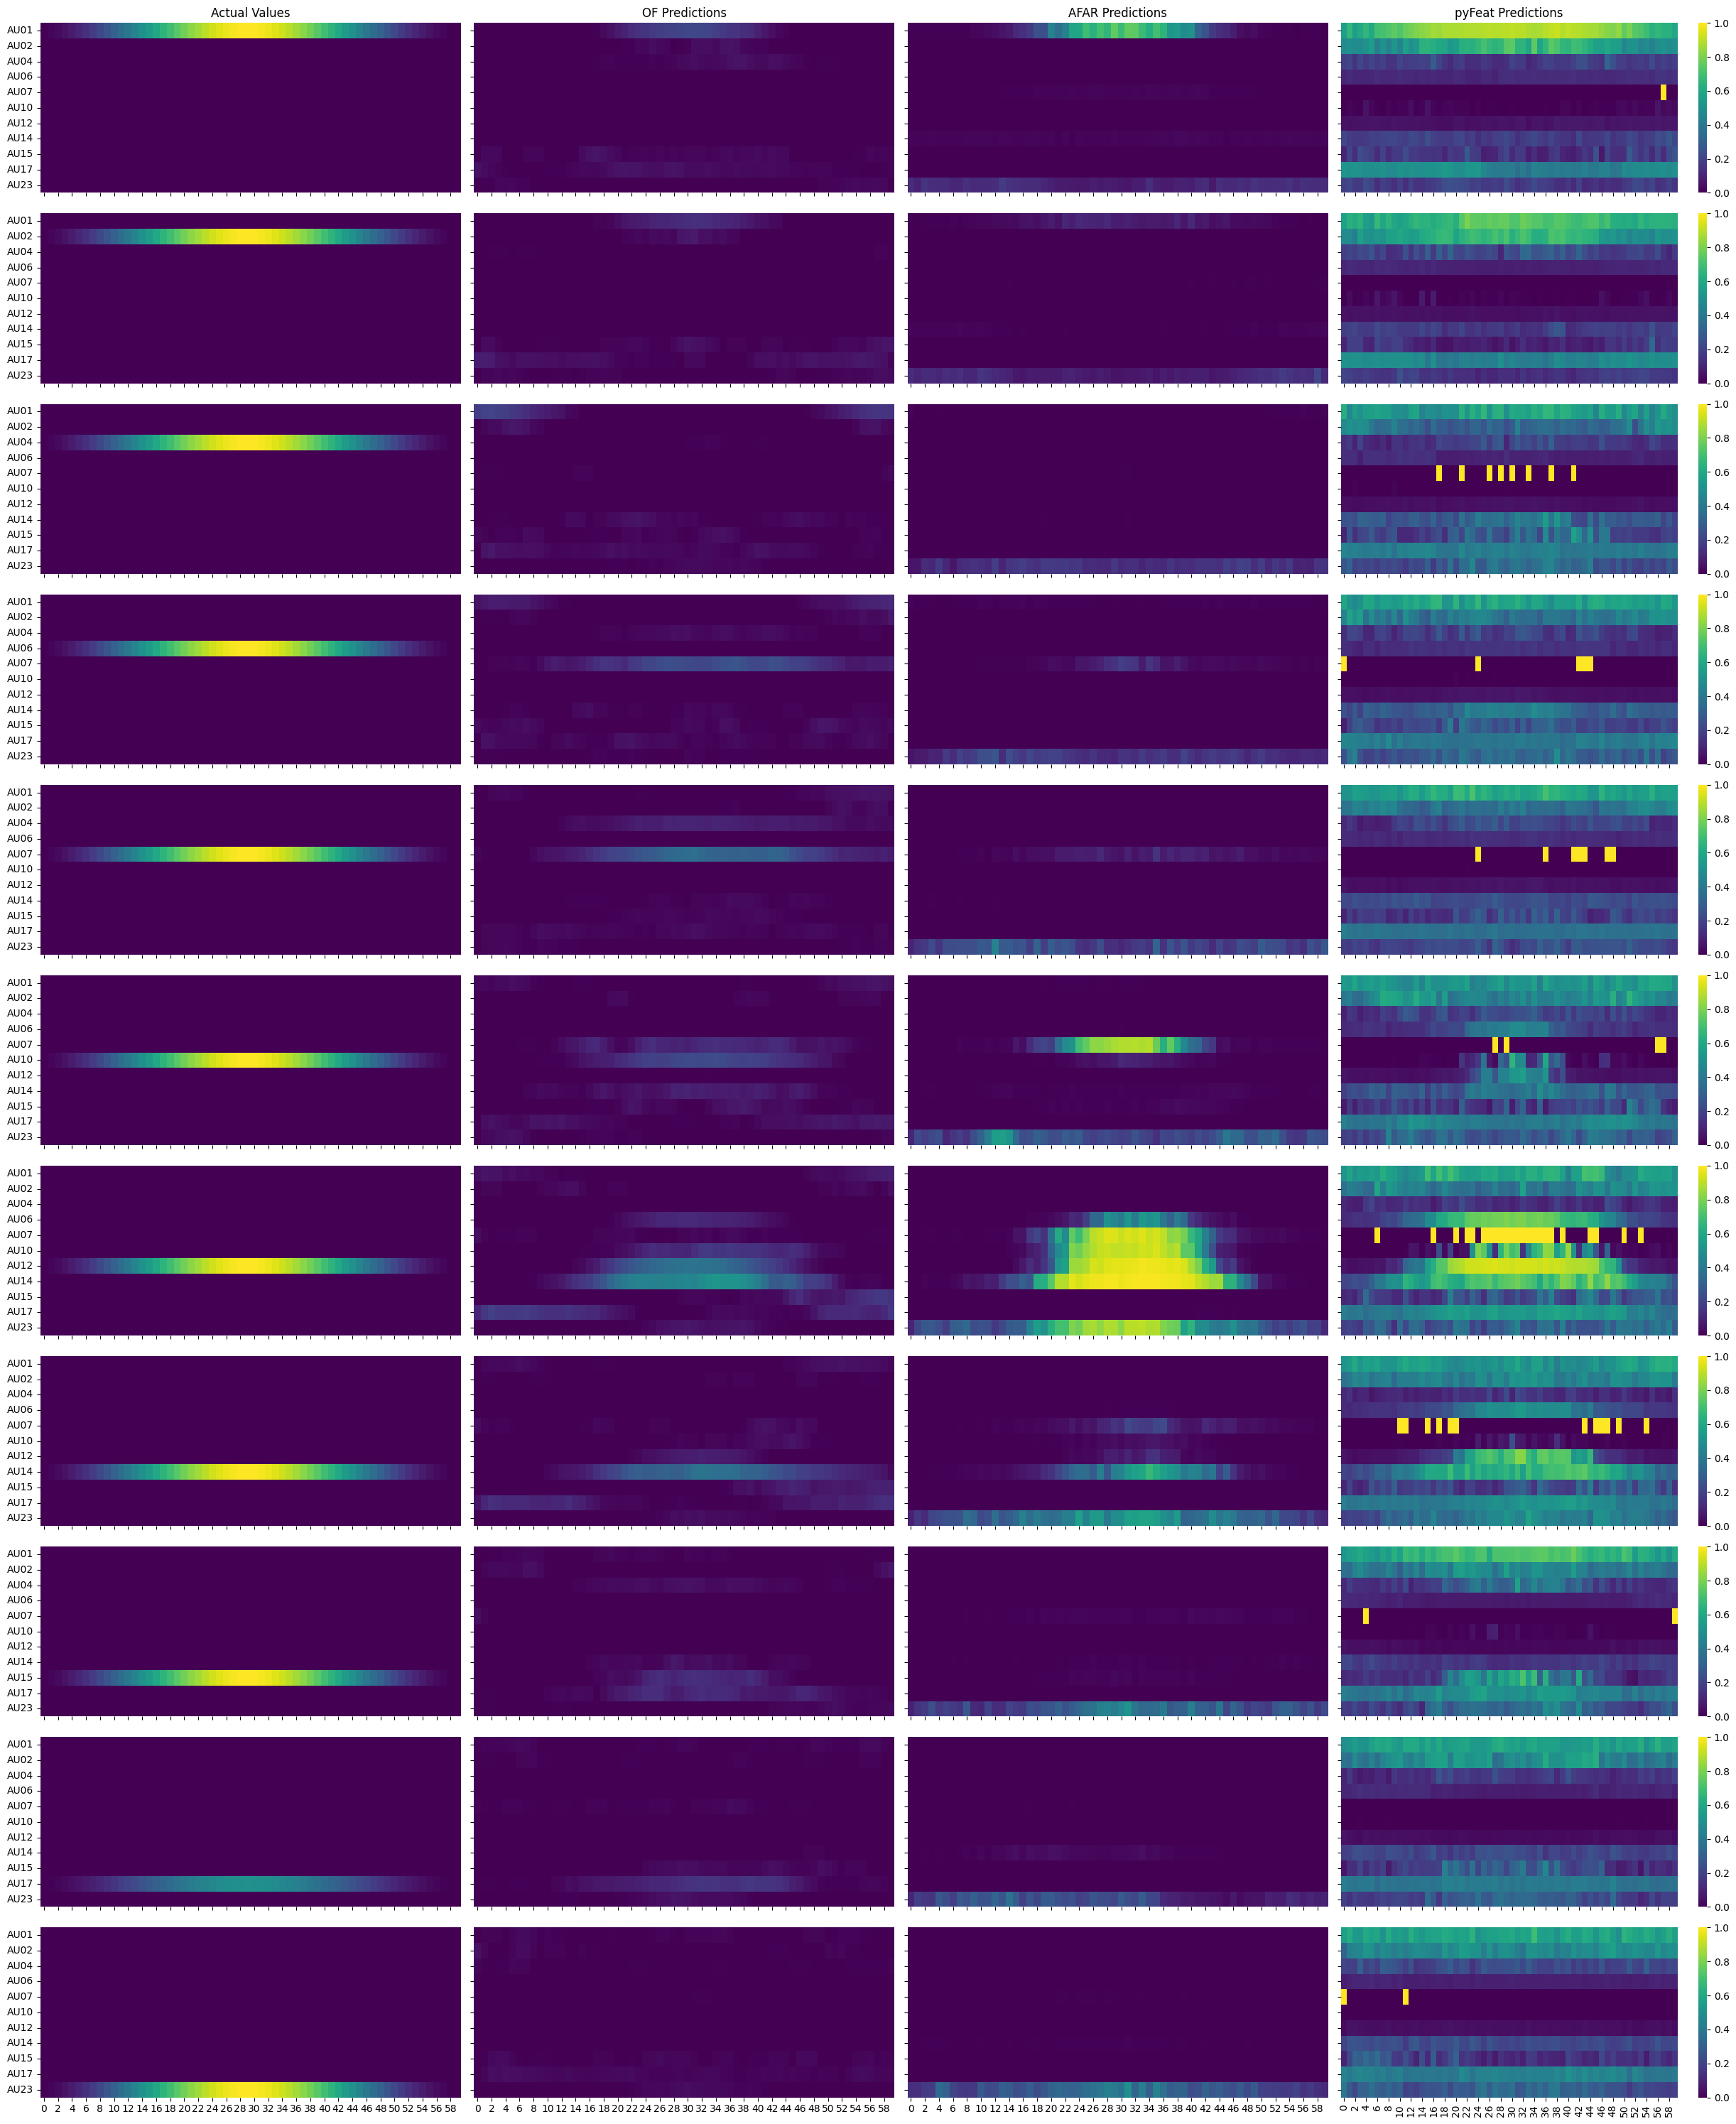

In [6]:
fig, axs = plt.subplots(len(AU_only_anim), 4, sharex=True, sharey=True, figsize=(25,30))

for anim in AU_only_anim:
  row = AU_only_anim.index(anim)
  actual_mat = loadmat(f"Ada_actualValues_anim_{anim}.mat")
  actual_data = actual_mat['actual_mat']

  AFAR_pred_mat = loadmat(f"Ada_AFARpred_anim_{anim}.mat")
  AFAR_pred = AFAR_pred_mat['AFAR_pred']

  OF_pred_mat = loadmat(f"Ada_OFpred_anim_{anim}.mat")
  OF_pred = OF_pred_mat['normed_OF_pred']

  pyFEAT_pred_mat = loadmat(f"Ada_PYFEATpred_anim_{anim}.mat")
  pyFEAT_pred = pyFEAT_pred_mat['PYFEAT_pred']

  # Plot the first heatmap using Seaborn
  sns.heatmap(actual_data.T, cmap='viridis', annot=False, cbar=False, vmin=0, vmax=1, ax=axs[row, 0])
  axs[0, 0].set_title('Actual Values')
  axs[row, 0].set_yticks(np.arange(len(AU_only_anim))+0.5, labels=AU_only_anim)
  plt.setp(axs[row, 0].get_yticklabels(), rotation=0, ha="right",
         rotation_mode="anchor")

  # Plot the second heatmap using Seaborn
  sns.heatmap(OF_pred.T, cmap='viridis', annot=False, cbar=False, vmin=0, vmax=1, ax=axs[row, 1])
  axs[0, 1].set_title('OF Predictions')
  axs[row, 1].set_yticks(np.arange(len(AU_only_anim))+0.5, labels=AU_only_anim)
  plt.setp(axs[row, 1].get_yticklabels(), rotation=0, ha="right",
         rotation_mode="anchor")

  # Plot the third heatmap using Seaborn
  sns.heatmap(AFAR_pred.T, cmap='viridis', annot=False, cbar=False, vmin=0, vmax=1, ax=axs[row, 2])
  axs[0, 2].set_title('AFAR Predictions')
  axs[row, 2].set_yticks(np.arange(len(AU_only_anim))+0.5, labels=AU_only_anim)
  plt.setp(axs[row, 2].get_yticklabels(), rotation=0, ha="right",
         rotation_mode="anchor")

  # Plot the fourth heatmap using Seaborn
  sns.heatmap(pyFEAT_pred.T, cmap='viridis', annot=False, cbar=True, vmin=0, vmax=1, ax=axs[row, 3])
  axs[0, 3].set_title('pyFeat Predictions')
  axs[row, 3].set_yticks(np.arange(len(AU_only_anim))+0.5, labels=AU_only_anim)
  plt.setp(axs[row, 3].get_yticklabels(), rotation=0, ha="right",
         rotation_mode="anchor")

  # Adjust layout for better spacing
  plt.tight_layout()

  # Show the plot
plt.show()

# Plot histogram of model prediction values to decide on a threshold for the classification metrics

(60, 792)
[0.0, 0.01428]
[1.3957426e-09, 0.019996118]
[0.0, 0.02]


Text(0.098, 1413.0, '5th Percentile: 0.088')

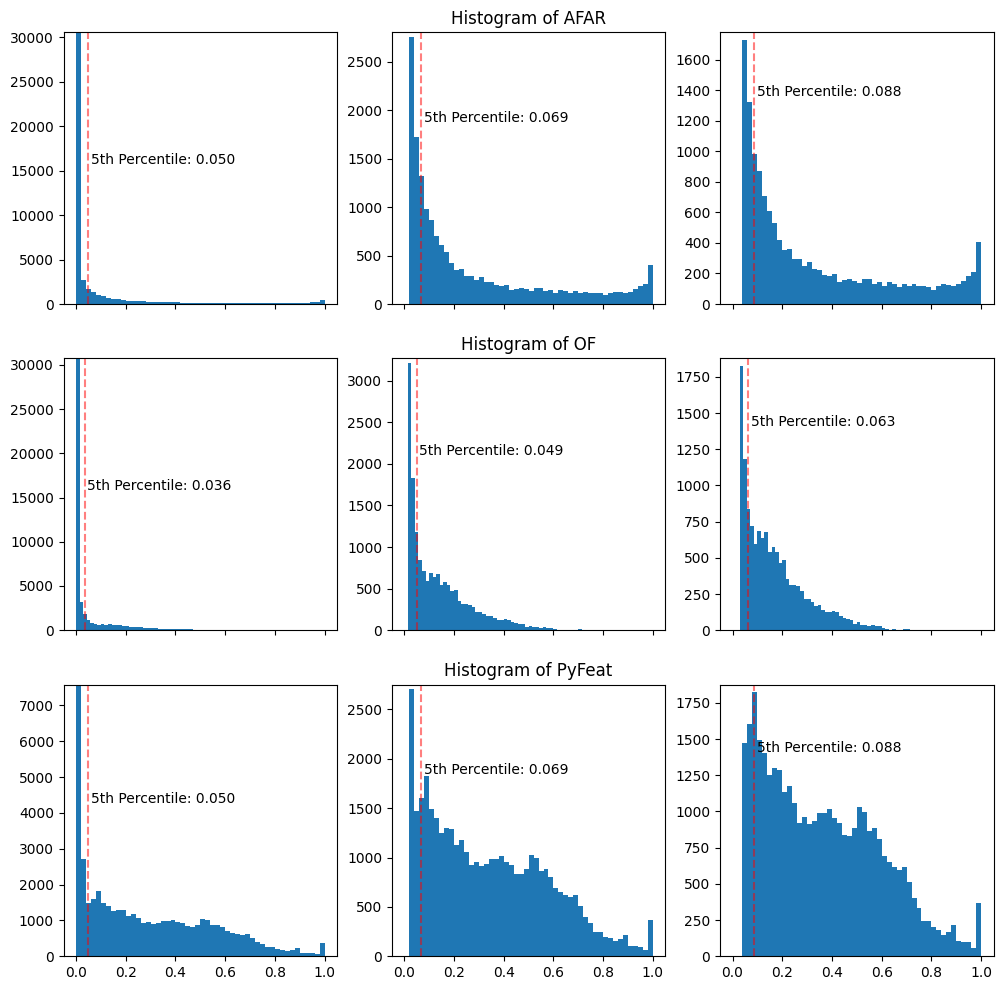

In [ ]:
# Create a histogram of AFARpred across all avatars and animations in order to set a threshold for the classification metrics
fig, axs = plt.subplots(3, 3, sharex=True, sharey=False, figsize=(12,12))

AFAR_pred_all=[]
OF_pred_all=[]
pyFEAT_pred_all=[]
for MH in avatars:
  for anim in animations:
      AFAR_pred_mat = loadmat(f"{MH}_AFARpred_anim_{anim}.mat")
      AFAR_pred = AFAR_pred_mat['AFAR_pred']
      AFAR_pred_all.append(AFAR_pred)  #72 x 60 x 11
      OF_pred_mat = loadmat(f"{MH}_OFpred_anim_{anim}.mat")
      OF_pred = OF_pred_mat['normed_OF_pred']
      OF_pred_all.append(OF_pred) # 72 x 60
      pyFEAT_pred_mat = loadmat(f"{MH}_PYFEATpred_anim_{anim}.mat")
      pyFEAT_pred = pyFEAT_pred_mat['PYFEAT_pred']
      pyFEAT_pred_all.append(pyFEAT_pred) #72 x 60 x 11

AFAR_all = np.hstack(AFAR_pred_all)
OF_all = np.hstack(OF_pred_all)
pyFEAT_all = np.hstack(pyFEAT_pred_all)
print(AFAR_all.shape)
hist_AFAR, bins_AFAR = np.histogram(AFAR_all.flatten(), bins=50)
hist_OF, bins_OF = np.histogram(OF_all.flatten(), bins=50)
hıst_pyFEAT, bins_pyFEAT = np.histogram(pyFEAT_all.flatten(), bins=50)

#print(hist_AFAR)
#print(bins_AFAR)
#plt.hist(AFAR_all.flatten(), bins=50)
print([bins_OF[0], bins_OF[1]])
print([bins_AFAR[0], bins_AFAR[1]])
print([bins_pyFEAT[0], bins_pyFEAT[1]])

axs[0,0].stairs(hist_AFAR, bins_AFAR,fill=True)
axs[0,0].set_ylim(0, max(hist_AFAR)+50)
axs[0,0].axvline(np.percentile(bins_AFAR,5), linestyle="dashed", color='red', alpha=0.5)
axs[0,0].annotate(f'5th Percentile: {np.percentile(bins_AFAR,5):.3f}',
                xy=(np.percentile(bins_AFAR,5) + 0.01, max(hist_AFAR) / 2),
                xytext=(np.percentile(bins_AFAR,5) + 0.01, max(hist_AFAR) / 2 + 500))

axs[0,1].stairs(hist_AFAR[1::], bins_AFAR[1::],fill=True)
axs[0,1].set_ylim(0, max(hist_AFAR[1::])+50)
axs[0,1].axvline(np.percentile(bins_AFAR[1::],5), linestyle="dashed", color='red', alpha=0.5)
axs[0,1].annotate(f'5th Percentile: {np.percentile(bins_AFAR[1::],5):.3f}',
                xy=(np.percentile(bins_AFAR[1::],5) + 0.01, max(hist_AFAR[1::]) / 2),
                xytext=(np.percentile(bins_AFAR[1::],5) + 0.01, max(hist_AFAR[1::]) / 2 + 500))
axs[0,1].set_title('Histogram of AFAR')


axs[0,2].stairs(hist_AFAR[2::], bins_AFAR[2::],fill=True)
axs[0,2].set_ylim(0, max(hist_AFAR[2::])+50)
axs[0,2].axvline(np.percentile(bins_AFAR[2::],5), linestyle="dashed", color='red', alpha=0.5)
axs[0,2].annotate(f'5th Percentile: {np.percentile(bins_AFAR[2::],5):.3f}',
                xy=(np.percentile(bins_AFAR[2::],5) + 0.01, max(hist_AFAR[2::]) / 2),
                xytext=(np.percentile(bins_AFAR[2::],5) + 0.01, max(hist_AFAR[2::]) / 2 + 500))

axs[1,0].stairs(hist_OF, bins_OF,fill=True)
axs[1,0].set_ylim(0, max(hist_OF)+50)
axs[1,0].axvline(np.percentile(bins_OF,5), linestyle="dashed", color='red', alpha=0.5)
axs[1,0].annotate(f'5th Percentile: {np.percentile(bins_OF,5):.3f}',
                xy=(np.percentile(bins_OF,5) + 0.01, max(hist_OF) / 2),
                xytext=(np.percentile(bins_OF,5) + 0.01, max(hist_OF) / 2 + 500))

axs[1,1].stairs(hist_OF[1::], bins_OF[1::],fill=True)
axs[1,1].set_ylim(0, max(hist_OF[1::])+50)
axs[1,1].axvline(np.percentile(bins_OF[1::],5), linestyle="dashed", color='red', alpha=0.5)
axs[1,1].annotate(f'5th Percentile: {np.percentile(bins_OF[1::],5):.3f}',
                xy=(np.percentile(bins_OF[1::],5) + 0.01, max(hist_OF[1::]) / 2),
                xytext=(np.percentile(bins_OF[1::],5) + 0.01, max(hist_OF[1::]) / 2 + 500))
axs[1,1].set_title('Histogram of OF')

axs[1,2].stairs(hist_OF[2::], bins_OF[2::],fill=True)
axs[1,2].set_ylim(0, max(hist_OF[2::])+50)
axs[1,2].axvline(np.percentile(bins_OF[2::],5), linestyle="dashed", color='red', alpha=0.5)
axs[1,2].annotate(f'5th Percentile: {np.percentile(bins_OF[2::],5):.3f}',
                xy=(np.percentile(bins_OF[2::],5) + 0.01, max(hist_OF[2::]) / 2),
                xytext=(np.percentile(bins_OF[2::],5) + 0.01, max(hist_OF[2::]) / 2 + 500))

axs[2,0].stairs(hıst_pyFEAT, bins_pyFEAT,fill=True)
axs[2,0].set_ylim(0, max(hıst_pyFEAT)+50)
axs[2,0].axvline(np.percentile(bins_pyFEAT,5), linestyle="dashed", color='red', alpha=0.5)
axs[2,0].annotate(f'5th Percentile: {np.percentile(bins_pyFEAT,5):.3f}',
                xy=(np.percentile(bins_pyFEAT,5) + 0.01, max(hıst_pyFEAT) / 2),
                xytext=(np.percentile(bins_pyFEAT,5) + 0.01, max(hıst_pyFEAT) / 2 + 500))

axs[2,1].stairs(hıst_pyFEAT[1::], bins_pyFEAT[1::],fill=True)
axs[2,1].set_ylim(0, max(hıst_pyFEAT[1::])+50)
axs[2,1].axvline(np.percentile(bins_pyFEAT[1::],5), linestyle="dashed", color='red', alpha=0.5)
axs[2,1].annotate(f'5th Percentile: {np.percentile(bins_pyFEAT[1::],5):.3f}',
                xy=(np.percentile(bins_pyFEAT[1::],5) + 0.01, max(hıst_pyFEAT[1::]) / 2),
                xytext=(np.percentile(bins_pyFEAT[1::],5) + 0.01, max(hıst_pyFEAT[1::]) / 2 + 500))
axs[2,1].set_title('Histogram of PyFeat')

axs[2,2].stairs(hıst_pyFEAT[2::], bins_pyFEAT[2::],fill=True)
axs[2,2].set_ylim(0, max(hıst_pyFEAT[2::])+50)
axs[2,2].axvline(np.percentile(bins_pyFEAT[2::],5), linestyle="dashed", color='red', alpha=0.5)
axs[2,2].annotate(f'5th Percentile: {np.percentile(bins_pyFEAT[2::],5):.3f}',
                xy=(np.percentile(bins_pyFEAT[2::],5) + 0.01, max(hıst_pyFEAT[2::]) / 2),
                xytext=(np.percentile(bins_pyFEAT[2::],5) + 0.01, max(hıst_pyFEAT[2::]) / 2 + 500))


# Calculate Classification Metrics and Create a DataFrame

['Ada_AU01']
['Ada_AU02']
F1: Cannot be divided by zero
F1: Cannot be divided by zero
['Ada_AU04']
F1: Cannot be divided by zero
F1: Cannot be divided by zero
['Ada_AU06']
F1: Cannot be divided by zero
F1: Cannot be divided by zero
['Ada_AU07']
['Ada_AU10']
['Ada_AU12']
['Ada_AU14']
['Ada_AU15']
F1: Cannot be divided by zero
['Ada_AU17']
F1: Cannot be divided by zero
['Ada_AU23']
PREC: Cannot be divided by zero
F1: SEN or PREC is None
['Ada_browsAll']
['Ada_browsAU10']
['Ada_browsAU12']
['Ada_browsAU14']
['Ada_browsAU15']
['Ada_browsAU17']
['Ada_browsAU23']
['Garry_AU01']
F1: Cannot be divided by zero
['Garry_AU02']
['Garry_AU04']
['Garry_AU06']
F1: Cannot be divided by zero
F1: Cannot be divided by zero
['Garry_AU07']
F1: Cannot be divided by zero
['Garry_AU10']
F1: Cannot be divided by zero
['Garry_AU12']
['Garry_AU14']
['Garry_AU15']
F1: Cannot be divided by zero
['Garry_AU17']
F1: Cannot be divided by zero
F1: Cannot be divided by zero
['Garry_AU23']
F1: Cannot be divided by zero
[

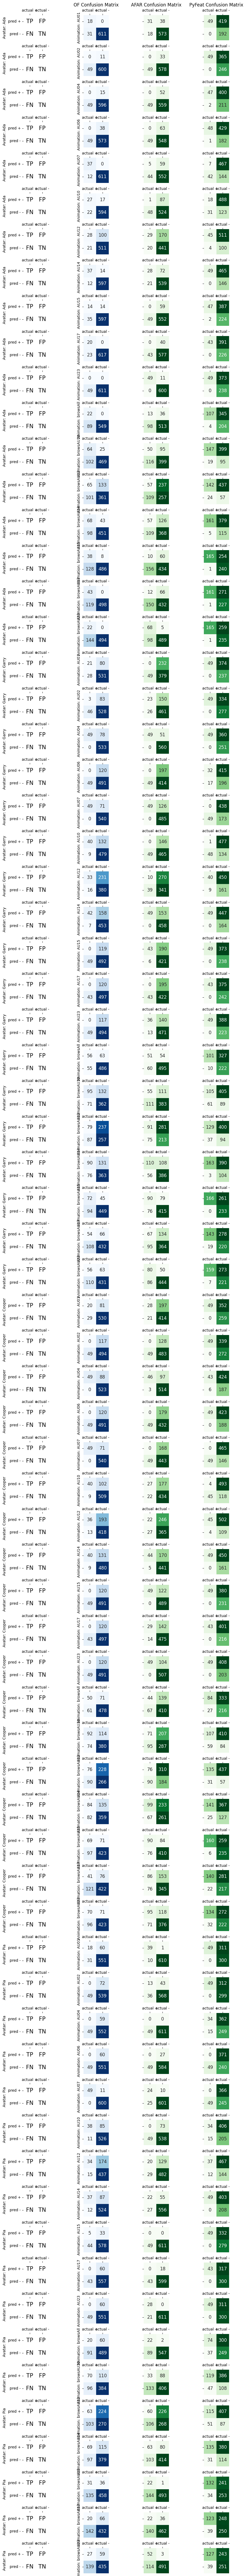

In [ ]:
def sensitivity(TP,FN):  # True Positive Rate
  if (len(TP)+len(FN)) == 0:
    print("SEN: Cannot be divided by zero")
    SEN = None
  else:
    SEN = len(TP) / (len(TP)+len(FN))
  return SEN

def FPR(FP,TN):
  if (len(FP)+len(TN)) == 0:
    print("FPR: Cannot be divided by zero")
    FPR = None
  else:
    FPR = len(FP) / (len(FP)+len(TN))
  return FPR

def specificity(TN,FP):
  if (len(TN)+len(FP)) == 0:
    print("SPEC: Cannot be divided by zero")
    SPEC = None
  else:
    SPEC = len(TN) / (len(TN)+len(FP))
  return SPEC

def prec(TP,FP):
  if (len(TP)+len(FP)) == 0:
    print("PREC: Cannot be divided by zero")
    PREC = None
  else:
    PREC = len(TP) / (len(TP)+len(FP))
  return PREC

def F1_score(SEN,PREC):
  if not isinstance(PREC, (int,float)) and isinstance(SEN, (int,float)):
    print("F1: SEN or PREC is None")
    F1 = 0
  else:
    if (SEN+PREC) == 0:
      print("F1: Cannot be divided by zero")
      F1 = 0
    else:
      F1 = 2*((SEN*PREC)/(SEN+PREC))
  return F1


list_keys_2D = [['TP', 'FP'],['FN', 'TN']]
thresholds = [0.06, 0.1]
threshold= thresholds[1]
plot_row=-1
classification_metrics_all_OF = {}
classification_metrics_all_AFAR = {}
classification_metrics_all_pyFEAT = {}

#for threshold in thresholds[1]:
fig, axs = plt.subplots(len(animations)*len(avatars), 4, sharex=True, sharey=True, figsize=(10,96))

for avatar in avatars:
  for anim in animations:
    all_var_dict = {
        'avatar': avatar,
        'animation': anim
        }

    classification_metrics_all_OF.update(all_var_dict)
    classification_metrics_all_AFAR.update(all_var_dict)
    classification_metrics_all_pyFEAT.update(all_var_dict)

    print([avatar + '_' + anim])
    plot_row = plot_row+1

    anim_ind = animations.index(anim)

    actual_mat = loadmat(f"{avatar}_actualValues_anim_{anim}.mat")
    actual_data = actual_mat['actual_mat']

    AFAR_pred_mat = loadmat(f"{avatar}_AFARpred_anim_{anim}.mat")
    AFAR_pred = AFAR_pred_mat['AFAR_pred']

    OF_pred_mat = loadmat(f"{avatar}_OFpred_anim_{anim}.mat")
    OF_pred = OF_pred_mat['normed_OF_pred']

    pyFEAT_pred_mat = loadmat(f"{avatar}_PYFEATpred_anim_{anim}.mat")
    pyFEAT_pred = pyFEAT_pred_mat['PYFEAT_pred']

    #calculate pred labels
    y_true = np.where(actual_data > threshold, 1, 0)
    y_class_AFAR = np.where(AFAR_pred > threshold, 1, 0)
    y_class_OF = np.where(OF_pred > threshold, 1, 0)
    y_class_pyFEAT = np.where(pyFEAT_pred > threshold, 1, 0)

    '''first figure'''
    df = pd.DataFrame([[0,0], [0,0]],
                    columns=['actual +', 'actual -'], index=['pred +', 'pred -'])
    sns.heatmap(df, annot=False, cmap='Greys', fmt='d', cbar=False, square=True, ax=axs[plot_row, 0])

    for i in range(len(df.index)):
      for j in range(len(df.columns)):
          value = list_keys_2D[i][j]
          axs[plot_row, 0].text(j+0.5, i+0.5, value, ha='center', va='center', fontsize=15)
    axs[plot_row, 0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[plot_row,0].set_ylabel(f'Avatar: {avatar}')
    ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
    OF_TP = []; AFAR_TP = []; pyFEAT_TP = []; false_detections_OF = [];
    OF_TN = []; AFAR_TN = []; pyFEAT_TN = []; false_detections_AFAR = [];
    OF_FP = []; AFAR_FP = []; pyFEAT_FP = []; false_detections_pyFEAT = [];
    OF_FN = []; AFAR_FN = []; pyFEAT_FN = [];

    ''' OF '''

    for fr in range(actual_data.shape[0]):
      for col in range(actual_data.shape[1]):
        prediction = OF_pred[fr,col]
        actual = actual_data[fr,col]
        if actual > threshold and  prediction > threshold:
            OF_TP.append(prediction)
        elif actual > threshold and prediction <= threshold:
            OF_FN.append(1)
        elif actual <= threshold and prediction > threshold:
            OF_FP.append(prediction)
            false_AU = animations[col]
            false_detections_OF.append(false_AU)
        elif actual <= threshold and prediction <= threshold:
            OF_TN.append(1)

    confusion_metrics_percentages_OF ={
          "TP_perc": round(len(OF_TP)/len(actual_data.flatten())*100),
          "FP_perc": round(len(OF_FP)/len(actual_data.flatten())*100),
          "TN_perc": round(len(OF_TN)/len(actual_data.flatten())*100),
          "FN_perc": round(len(OF_FN)/len(actual_data.flatten())*100)
      }

    confusion_metrics_OF ={
          "TP": len(OF_TP),
          "FP": len(OF_FP),
          "TN": len(OF_TN),
          "FN": len(OF_FN),
          "false_detections": false_detections_OF
      }

    classification_metrics_all_OF.update(confusion_metrics_OF)
    classification_metrics_all_OF.update(confusion_metrics_percentages_OF)

    df = pd.DataFrame([[confusion_metrics_OF['TP'], confusion_metrics_OF['FP']], [confusion_metrics_OF['FN'], confusion_metrics_OF['TN']]],
                    columns=['actual +', 'actual -'], index=['pred +', 'pred -'])

    sns.heatmap(df, annot=True, annot_kws={'size': 12}, cmap='Blues', fmt='d', cbar=False, square=True, ax=axs[plot_row, 1])
    axs[plot_row, 1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[0, 1].set_title('OF Confusion Matrix')
    axs[plot_row,1].set_ylabel(f'Animation: {anim}')

    confusion_values_OF ={
          "TP": OF_TP,
          "FP": OF_FP,
          "TN": OF_TN,
          "FN": OF_FN
      }

    df = pd.DataFrame.from_dict(confusion_values_OF, orient='index')
    df = df.T
    #df.to_csv(f'{avatar}_{anim}_OF_confusion_values_threshold_{threshold}.csv')

    SEN_OF = sensitivity(OF_TP, OF_FN)
    FPR_OF = FPR(OF_FP, OF_TN)
    SPEC_OF = specificity(OF_TN, OF_FP)
    PREC_OF = prec(OF_TP, OF_FP)
    F1_OF = F1_score(SEN_OF, PREC_OF)

    confusion_scores_OF={
        "TPR": SEN_OF,
        "FPR": FPR_OF,
        "F1_score": F1_OF
    }

    classification_metrics_all_OF.update(confusion_scores_OF)

    df = pd.DataFrame.from_dict(confusion_scores_OF, orient='index')
    df = df.T
    # Save DataFrame to CSV file
    #df.to_csv(f'{avatar}_{anim}_OF_confusion_scores_threshold_{threshold}.csv')

    #calculate AUC and plot ROC
    fpr, tpr, _ = roc_curve(y_true.flatten(), OF_pred.flatten())
    roc_auc = auc(fpr, tpr)
    AUC_dict={
        'AUC': roc_auc
    }
    classification_metrics_all_OF.update(AUC_dict)
    df_OF = pd.DataFrame.from_dict(classification_metrics_all_OF, orient='index')
    df_OF = df_OF.T
    #print(df_OF)
    df_OF.to_csv(f'{avatar}_{anim}_OF_classification_metrics_all_threshold_{threshold}.csv')

    ''' AFAR '''
    for fr in range(actual_data.shape[0]):
      for col in range(actual_data.shape[1]):
        prediction = AFAR_pred[fr,col]
        actual = actual_data[fr,col]
        if actual > threshold and  prediction > threshold:
            AFAR_TP.append(prediction)
        elif actual > threshold and prediction <= threshold:
            AFAR_FN.append(1)
        elif actual <= threshold and prediction > threshold:
            AFAR_FP.append(prediction)
            false_AU = animations[col]
            false_detections_AFAR.append(false_AU)
        elif actual <= threshold and prediction <= threshold:
            AFAR_TN.append(1)

    confusion_metrics_percentages_AFAR ={
          "TP_perc": round(len(AFAR_TP)/len(actual_data.flatten())*100),
          "FP_perc": round(len(AFAR_FP)/len(actual_data.flatten())*100),
          "TN_perc": round(len(AFAR_TN)/len(actual_data.flatten())*100),
          "FN_perc": round(len(AFAR_FN)/len(actual_data.flatten())*100)
      }

    confusion_metrics_AFAR = {
          "TP": len(AFAR_TP),
          "FP": len(AFAR_FP),
          "TN": len(AFAR_TN),
          "FN": len(AFAR_FN),
          "false_detections": false_detections_AFAR
    }

    classification_metrics_all_AFAR.update(confusion_metrics_AFAR)
    classification_metrics_all_AFAR.update(confusion_metrics_percentages_AFAR)

    df = pd.DataFrame([[confusion_metrics_AFAR['TP'],
                        confusion_metrics_AFAR['FP']],
                        [confusion_metrics_AFAR['FN'],
                          confusion_metrics_AFAR['TN']]],
                    columns=['actual +', 'actual -'], index=['pred +', 'pred -'])

    sns.heatmap(df, annot=True, annot_kws={'size': 12}, cmap='Greens', fmt='d', cbar=False, square=True, ax=axs[plot_row, 2])
    axs[plot_row, 2].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[0, 2].set_title('AFAR Confusion Matrix')

    confusion_values_AFAR ={
          "TP": AFAR_TP,
          "FP": AFAR_FP,
          "TN": AFAR_TN,
          "FN": AFAR_FN
      }

    df = pd.DataFrame.from_dict(confusion_values_AFAR, orient='index')
    df = df.T
    #df.to_csv(f'{avatar}_{anim}_AFAR_confusion_values_threshold_{threshold}.csv')

    SEN_AFAR = sensitivity(AFAR_TP, AFAR_FN)
    FPR_AFAR = FPR(AFAR_FP, AFAR_TN)
    SPEC_AFAR = specificity(AFAR_TN, AFAR_FP)
    PREC_AFAR = prec(AFAR_TP, AFAR_FP)
    F1_AFAR = F1_score(SEN_AFAR, PREC_AFAR)
    dprime_AFAR = dprime(SEN_AFAR, FPR_AFAR)

    confusion_scores_AFAR={
        "TPR": SEN_AFAR,
        "FPR": FPR_AFAR,
        "F1_score": F1_AFAR
    }

    classification_metrics_all_AFAR.update(confusion_scores_AFAR)

    df = pd.DataFrame.from_dict(confusion_scores_AFAR, orient='index')
    df = df.T
    #df.to_csv(f'{avatar}_{anim}_AFAR_confusion_scores_threshold_{threshold}.csv')

    #calculate AUC and plot ROC
    fpr, tpr, _ = roc_curve(y_true.flatten(), AFAR_pred.flatten())
    roc_auc = auc(fpr, tpr)
    AUC_dict={
        'AUC': roc_auc
    }
    classification_metrics_all_AFAR.update(AUC_dict)

    df_AFAR = pd.DataFrame.from_dict(classification_metrics_all_AFAR, orient='index')
    df_AFAR = df_AFAR.T
    #print(df_AFAR)
    df_AFAR.to_csv(f'{avatar}_{anim}_AFAR_classification_metrics_all_threshold_{threshold}.csv')

    ''' pyFEAT '''

    for fr in range(actual_data.shape[0]):
      for col in range(actual_data.shape[1]):
        prediction = pyFEAT_pred[fr,col]
        actual = actual_data[fr,col]
        if actual > threshold and  prediction > threshold:
            pyFEAT_TP.append(prediction)
        elif actual > threshold and prediction <= threshold:
            pyFEAT_FN.append(1)
        elif actual <= threshold and prediction > threshold:
            pyFEAT_FP.append(prediction)
            false_AU = animations[col]
            false_detections_pyFEAT.append(false_AU)
        elif actual <= threshold and prediction <= threshold:
            pyFEAT_TN.append(1)

    confusion_metrics_percentages_pyFEAT ={
          "TP_perc": round(len(pyFEAT_TP)/len(actual_data.flatten())*100),
          "FP_perc": round(len(pyFEAT_FP)/len(actual_data.flatten())*100),
          "TN_perc": round(len(pyFEAT_TN)/len(actual_data.flatten())*100),
          "FN_perc": round(len(pyFEAT_FN)/len(actual_data.flatten())*100)
      }

    confusion_metrics_pyFEAT = {
          "TP": len(pyFEAT_TP),
          "FP": len(pyFEAT_FP),
          "TN": len(pyFEAT_TN),
          "FN": len(pyFEAT_FN),
          "false_detections": false_detections_pyFEAT
    }

    classification_metrics_all_pyFEAT.update(confusion_metrics_pyFEAT)
    classification_metrics_all_pyFEAT.update(confusion_metrics_percentages_pyFEAT)

    df = pd.DataFrame([[confusion_metrics_pyFEAT['TP'],
                        confusion_metrics_pyFEAT['FP']],
                        [confusion_metrics_pyFEAT['FN'],
                          confusion_metrics_pyFEAT['TN']]],
                    columns=['actual +', 'actual -'], index=['pred +', 'pred -'])

    sns.heatmap(df, annot=True, annot_kws={'size': 12}, cmap='Greens', fmt='d', cbar=False, square=True, ax=axs[plot_row, 3])
    axs[plot_row, 3].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[0, 3].set_title('PyFeat Confusion Matrix')

    confusion_values_pyFEAT ={
          "TP": pyFEAT_TP,
          "FP": pyFEAT_FP,
          "TN": pyFEAT_TN,
          "FN": pyFEAT_FN
      }

    df = pd.DataFrame.from_dict(confusion_values_pyFEAT, orient='index')
    df = df.T
    #df.to_csv(f'{avatar}_{anim}_pyFEAT_confusion_values_threshold_{threshold}.csv')

    SEN_pyFEAT = sensitivity(pyFEAT_TP, pyFEAT_FN)
    FPR_pyFEAT = FPR(pyFEAT_FP, pyFEAT_TN)
    F1_pyFEAT = F1_score(SEN_pyFEAT, PREC_pyFEAT)

    confusion_scores_pyFEAT={
        "TPR": SEN_pyFEAT,
        "FPR": FPR_pyFEAT,
        "F1 score": F1_pyFEAT
    }

    classification_metrics_all_pyFEAT.update(confusion_scores_pyFEAT)

    df = pd.DataFrame.from_dict(confusion_scores_pyFEAT, orient='index')
    df = df.T
    #df.to_csv(f'{avatar}_{anim}_pyFEAT_confusion_scores_threshold_{threshold}.csv')

    #calculate AUC and plot ROC
    fpr, tpr, _ = roc_curve(y_true.flatten(), pyFEAT_pred.flatten())
    roc_auc = auc(fpr, tpr)
    AUC_dict={
        'AUC': roc_auc
    }
    classification_metrics_all_pyFEAT.update(AUC_dict)

    df_pyFEAT = pd.DataFrame.from_dict(classification_metrics_all_pyFEAT, orient='index')
    df_pyFEAT = df_pyFEAT.T
    df_pyFEAT.to_csv(f'{avatar}_{anim}_pyFEAT_classification_metrics_all_threshold_{threshold}.csv')


plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.1; df_AFAR_list=[]; df_OF_list=[]; df_pyFEAT_list=[];
for avatar in avatars:
  for anim in animations:
    print([avatar + '_' + anim])
    df_AFAR =  pd.read_csv(f'{avatar}_{anim}_AFAR_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
    df_AFAR_list.append(df_AFAR)
    df_OF =  pd.read_csv(f'{avatar}_{anim}_OF_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
    df_OF_list.append(df_OF)
    df_pyFEAT =  pd.read_csv(f'{avatar}_{anim}_pyFEAT_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
    df_pyFEAT_list.append(df_pyFEAT)

df_AFAR_all=pd.concat(df_AFAR_list, ignore_index=True)
df_AFAR_all.to_csv(f'AFAR_classification_metrics_all_threshold_{threshold}.csv')

df_OF_all=pd.concat(df_OF_list, ignore_index=True)
df_OF_all.to_csv(f'OF_classification_metrics_all_threshold_{threshold}.csv')

df_pyFEAT_all=pd.concat(df_pyFEAT_list, ignore_index=True)
df_pyFEAT_all.to_csv(f'pyFEAT_classification_metrics_all_threshold_{threshold}.csv')

# Check confused AUs per animation

In [ ]:
from collections import Counter
import ast

def get_variable_name(variable, globals_dict):
    # Match the object to its name in the global namespace
    for name, value in globals_dict.items():
        if value is variable:
            return name
    return None

threshold = 0.1
df_OF_all = pd.read_csv(f'OF_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_OF_all['false_detections'] = df_OF_all['false_detections'].apply(ast.literal_eval)
df_OF_all.to_csv(f'OF_classification_metrics_all_threshold_{threshold}.csv')
df_OF_all.head()
df_AFAR_all = pd.read_csv(f'AFAR_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_AFAR_all['false_detections'] = df_AFAR_all['false_detections'].apply(ast.literal_eval)
df_AFAR_all.to_csv(f'AFAR_classification_metrics_all_threshold_{threshold}.csv')
#df_AFAR_all.head()
df_pyFEAT_all = pd.read_csv(f'pyFEAT_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_pyFEAT_all['false_detections'] = df_pyFEAT_all['false_detections'].apply(ast.literal_eval)
df_pyFEAT_all.to_csv(f'pyFEAT_classification_metrics_all_threshold_{threshold}.csv')
#df_pyFEAT_all.head()

my_dict = {}; df_list = [];
model_df = [df_OF_all, df_AFAR_all]
for model in model_df:
  for i in range(len(model['false_detections'])):
    #print(i)
    counts = Counter((model['false_detections'][i]))
    #print(my_set)
    unique_values = list(counts.keys())
    counts_list = list(counts.values())
    #print(my_list)
    my_dict = {'avatar': model['avatar'][i],
        'animation': model['animation'][i],
        'TP': model['TP'][i],
        'FP': model['FP'][i],
        'TN': model['TN'][i],
        'FN': model['FN'][i],
        'TPR': model['TPR'][i],
        'FPR': model['FPR'][i],
        'false_detections_unique': unique_values,
        'false_detections_unique_count': counts_list,
        'model_name': get_variable_name(model, globals())
        }
    my_dict.update(my_dict)
    df = pd.DataFrame.from_dict(my_dict, orient='index')
    df = df.T
    df_list.append(df)

    df_all = pd.concat(df_list, ignore_index=True)
df_all.head()
df_all.to_csv(f'false_detections_threshold_{threshold}.csv')



In [ ]:
threshold = 0.1
df_false_detections = pd.read_csv(f'false_detections_threshold_{threshold}.csv', delimiter=',', index_col=0)

In [ ]:
df_false_detections.head()

,avatar,animation,TP,FP,TN,FN,TPR,FPR,false_detections_unique,false_detections_unique_count,model_name
0,Ada,AU01,18,0,611,31,0.367347,0.000000,[],[],df_OF_all
1,Ada,AU02,0,11,600,49,0.000000,0.018003,['AU01'],[11],df_OF_all
2,Ada,AU04,0,15,596,49,0.000000,0.024550,['AU01'],[15],df_OF_all
3,Ada,AU06,0,38,573,49,0.000000,0.062193,"['AU07', 'AU01']","[36, 2]",df_OF_all
4,Ada,AU07,37,0,611,12,0.755102,0.000000,[],[],df_OF_all


# Load Classification Metrics' DataFrame by Model

In [ ]:
threshold = 0.1
df_OF_all = pd.read_csv(f'OF_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_OF_all.head()
df_AFAR_all = pd.read_csv(f'AFAR_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_AFAR_all.head()
df_pyFEAT_all = pd.read_csv(f'pyFEAT_classification_metrics_all_threshold_{threshold}.csv', delimiter=',', index_col=0)
df_pyFEAT_all.head()

,avatar,animation,TP,FP,TN,FN,false_detections,TP_perc,FP_perc,TN_perc,FN_perc,TPR,FPR,specificity,prec,F1_score,d Prime,AUC
0,Ada,AU01,49,419,192,0,"['AU01', 'AU02', 'AU04', 'AU06', 'AU14', 'AU15...",7,63,29,0,1.000000,0.685761,0.314239,0.104701,0.189555,inf,0.996326
1,Ada,AU02,49,365,246,0,"['AU01', 'AU02', 'AU04', 'AU06', 'AU14', 'AU17...",7,55,37,0,1.000000,0.597381,0.402619,0.118357,0.211663,inf,0.926484
2,Ada,AU04,47,400,211,2,"['AU01', 'AU02', 'AU04', 'AU06', 'AU14', 'AU17...",7,61,32,0,0.959184,0.654664,0.345336,0.105145,0.189516,1.343346,0.429373
3,Ada,AU06,48,429,182,1,"['AU01', 'AU02', 'AU04', 'AU06', 'AU07', 'AU14...",7,65,28,0,0.979592,0.702128,0.297872,0.100629,0.182510,1.514861,0.334296
4,Ada,AU07,7,467,144,42,"['AU01', 'AU02', 'AU04', 'AU06', 'AU14', 'AU17...",1,71,22,6,0.142857,0.764321,0.235679,0.014768,0.026769,-1.787841,0.150573


In [ ]:
df_comb = pd.concat([df_OF_all, df_AFAR_all], ignore_index=True)
df_comb['model'] = np.repeat(['OF', 'AFAR'], 72)

In [ ]:
df_three = pd.concat([df_OF_all, df_AFAR_all, df_pyFEAT_all], ignore_index=True)
df_three['model'] = np.repeat(['OF', 'AFAR', 'pyFeat'], 72)

## Check normality assumption for significance tests

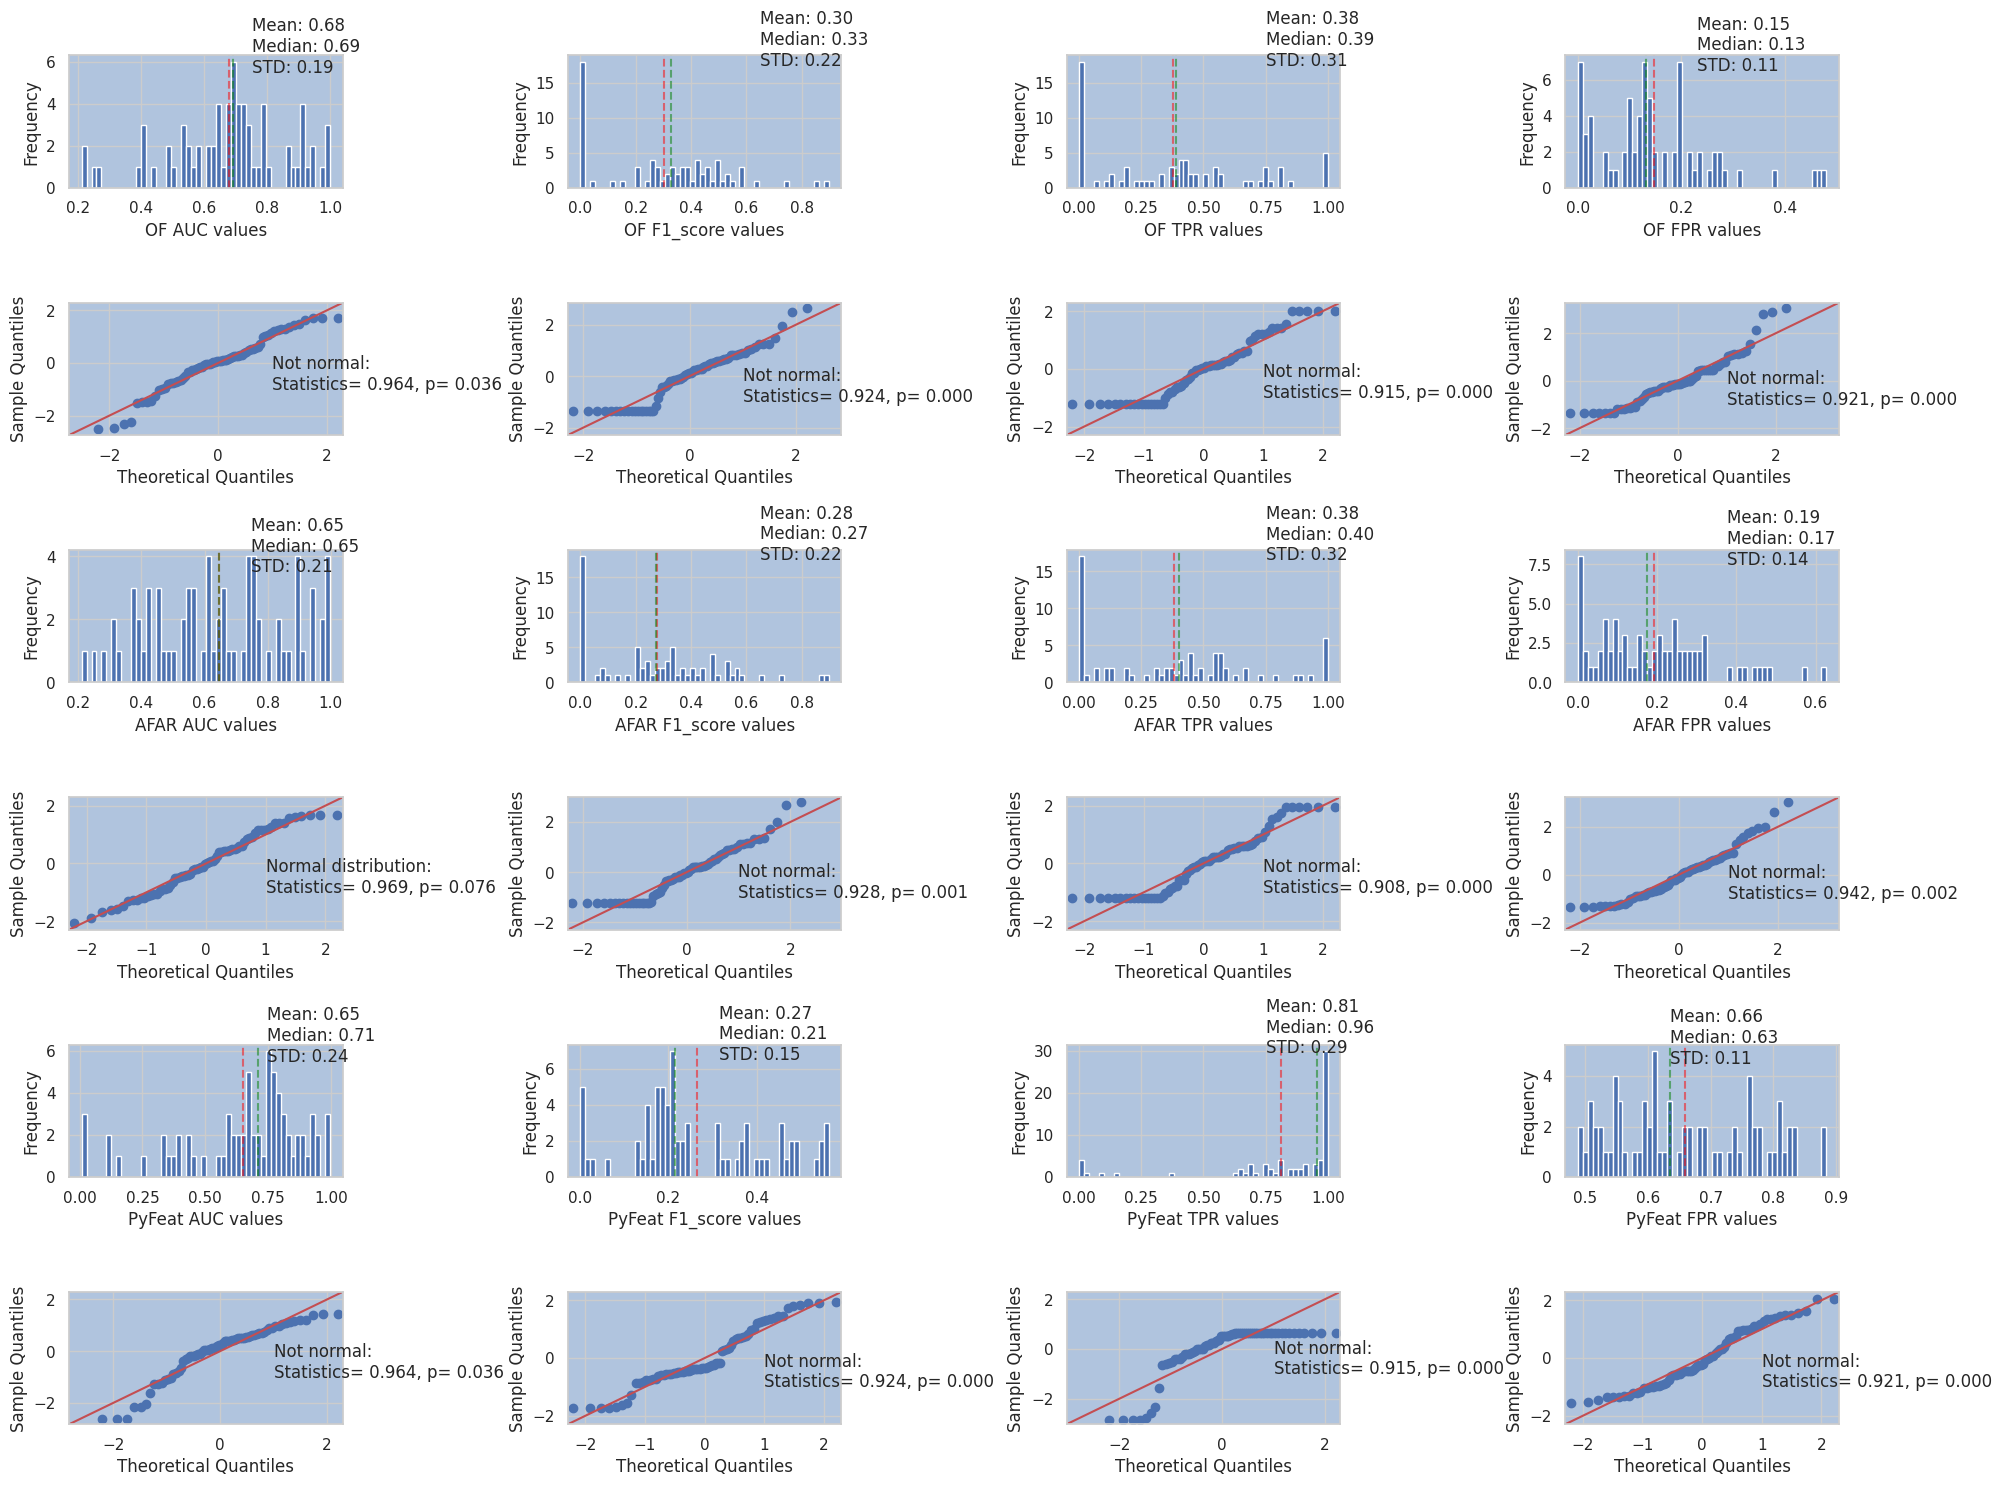

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(6, len(DVs), sharex=False, sharey=False, figsize=(20, 15))

for DV in range(len(DVs)):
  OF_arr = df_OF_all[DVs[DV]].to_numpy()
  hist_OF, bins_OF = np.histogram(OF_arr, bins=50)
  axs[0,DV].hist(OF_arr, bins=50)
  axs[0,DV].set_xlabel(f"OF {DVs[DV]} values")
  axs[0,DV].set_ylabel('Frequency')
  axs[0,DV].axvline(np.mean(OF_arr), linestyle="dashed", color='red', alpha=0.5)
  axs[0,DV].axvline(np.median(OF_arr), linestyle="dashed", color='green', alpha=0.5)
  axs[0,DV].annotate(f'Mean: {np.mean(OF_arr):.2f}\nMedian: {np.median(OF_arr):.2f}\nSTD: {np.std(OF_arr):.2f}',
                xy=(max(bins_OF) - 0.25, max(hist_OF) - 0.5),
                xytext=(max(bins_OF) - 0.25, max(hist_OF) - 0.5))
  # Standardize the data
  std_arr = []
  for i in range(len(OF_arr)):
      std_arr.append((OF_arr[i]-np.mean(OF_arr))/np.std(OF_arr))

  sm.qqplot(np.array(std_arr), line ='45', ax=axs[1,DV])
  stat, p = shapiro(OF_arr)
  alpha = 0.05
  if p > alpha:
    axs[1,DV].annotate(f'Normal distribution:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))
  else:
    axs[1,DV].annotate(f'Not normal:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))


  AFAR_arr = df_AFAR_all[DVs[DV]].to_numpy()
  hist_AFAR, bins_AFAR = np.histogram(AFAR_arr, bins=50)
  axs[2,DV].hist(AFAR_arr, bins=50)
  axs[2,DV].set_xlabel(f"AFAR {DVs[DV]} values")
  axs[2,DV].set_ylabel('Frequency')
  axs[2,DV].axvline(np.mean(AFAR_arr), linestyle="dashed", color='red', alpha=0.5)
  axs[2,DV].axvline(np.median(AFAR_arr), linestyle="dashed", color='green', alpha=0.5)
  axs[2,DV].annotate(f'Mean: {np.mean(AFAR_arr):.2f}\nMedian: {np.median(AFAR_arr):.2f}\nSTD: {np.std(AFAR_arr):.2f}',
                xy=(max(bins_AFAR) - 0.25, max(hist_AFAR) - 0.5),
                xytext=(max(bins_AFAR) - 0.25, max(hist_AFAR) - 0.5))
  # Standardize the data
  std_arr = []
  for i in range(len(AFAR_arr)):
      std_arr.append((AFAR_arr[i]-np.mean(AFAR_arr))/np.std(AFAR_arr))

  sm.qqplot(np.array(std_arr), line ='45', ax = axs[3,DV])
  stat, p = shapiro(AFAR_arr)
  alpha = 0.05
  if p > alpha:
    axs[3,DV].annotate(f'Normal distribution:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))
  else:
    axs[3,DV].annotate(f'Not normal:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))

  pyFEAT_arr = df_pyFEAT_all[DVs[DV]].to_numpy()
  hist_pyFEAT, bins_pyFEAT = np.histogram(pyFEAT_arr, bins=50)
  axs[4,DV].hist(pyFEAT_arr, bins=50)
  axs[4,DV].set_xlabel(f"PyFeat {DVs[DV]} values")
  axs[4,DV].set_ylabel('Frequency')
  axs[4,DV].axvline(np.mean(pyFEAT_arr), linestyle="dashed", color='red', alpha=0.5)
  axs[4,DV].axvline(np.median(pyFEAT_arr), linestyle="dashed", color='green', alpha=0.5)
  axs[4,DV].annotate(f'Mean: {np.mean(pyFEAT_arr):.2f}\nMedian: {np.median(pyFEAT_arr):.2f}\nSTD: {np.std(pyFEAT_arr):.2f}',
                xy=(max(bins_pyFEAT) - 0.25, max(hist_pyFEAT) - 0.5),
                xytext=(max(bins_pyFEAT) - 0.25, max(hist_pyFEAT) - 0.5))
  # Standardize the data
  std_arr = []
  for i in range(len(pyFEAT_arr)):
      std_arr.append((pyFEAT_arr[i]-np.mean(pyFEAT_arr))/np.std(pyFEAT_arr))

  sm.qqplot(np.array(std_arr), line ='45', ax=axs[5,DV])
  stat, p = shapiro(OF_arr)
  alpha = 0.05
  if p > alpha:
    axs[5,DV].annotate(f'Normal distribution:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))
  else:
    axs[5,DV].annotate(f'Not normal:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))

plt.tight_layout()
plt.show()

## Check the covariance of DV

In [ ]:
# CHECK FURTHER ANOVA ASSUMPTIONS OTHER THAN NORMALITY FOR AUC:
pg.homoscedasticity([df_OF_all['AUC'].to_numpy(),
                     df_AFAR_all['AUC'].to_numpy(),
                     df_pyFEAT_all['AUC'].to_numpy()])  # there should be equal variance

,W,pval,equal_var
levene,1.987077,0.139629,True


# Descriptives and Model Comparison across Classification Metrics

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
df_comb[DVs].describe().applymap('{:,.2f}'.format)

<ipython-input-7-fed41dc48695>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].describe().applymap('{:,.2f}'.format)


,AUC,F1_score,TPR,FPR
count,144.00,144.00,144.00,144.00
mean,0.66,0.29,0.38,0.17
std,0.20,0.22,0.32,0.13
min,0.21,0.00,0.00,0.00
25%,0.54,0.04,0.05,0.08
50%,0.68,0.31,0.39,0.14
75%,0.79,0.44,0.57,0.24
max,1.00,0.90,1.00,0.63


In [ ]:
# independent t-test to compare AUC scores
chance_level = 0.50
pg.ttest(df_comb['AUC'].values, chance_level)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,9.763347,143,two-sided,1.436414e-17,"[0.63, 0.7]",0.813612,3.822e+14,1.0


In [ ]:
# independent t-test to compare AUC scores
chance_level = 0.50
pg.ttest(df_comb[df_comb['model'] == 'OF']['AUC'].values, chance_level)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,8.144104,71,two-sided,9.037722e-12,"[0.64, 0.72]",0.959792,9.81e+08,1.0


In [ ]:
# independent t-test to compare AUC scores
chance_level = 0.50
pg.ttest(df_comb[df_comb['model'] == 'AFAR']['AUC'].values, chance_level)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.839056,71,two-sided,1.449339e-07,"[0.6, 0.7]",0.688139,9.361e+04,0.999927


In [ ]:
DVs=['avatar','animation','AUC','F1_score', 'model']
df_comb[DVs].groupby('model').describe().applymap('{:,.2f}'.format)

AUC                                           F1_score              \
       count  mean   std   min   25%   50%   75%   max    count  mean   std   
model                                                                         
AFAR   72.00  0.65  0.21  0.21  0.46  0.65  0.81  1.00    72.00  0.28  0.22   
OF     72.00  0.68  0.19  0.21  0.57  0.69  0.78  1.00    72.00  0.30  0.23   

                                     
        min   25%   50%   75%   max  
model                                
AFAR   0.00  0.05  0.27  0.43  0.90  
OF     0.00  0.03  0.33  0.45  0.90

In [ ]:
DVs=['avatar','animation','TPR','FPR', 'model']
df_comb[DVs].groupby('model').describe().applymap('{:,.2f}'.format)
#df_comb.columns

<ipython-input-52-2bcb8eab2f45>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].groupby('model').describe().applymap('{:,.2f}'.format)


TPR                                              FPR              \
       count  mean   std   min   25%   50%   75%   max  count  mean   std   
model                                                                       
AFAR   72.00  0.38  0.32  0.00  0.05  0.40  0.57  1.00  72.00  0.19  0.15   
OF     72.00  0.38  0.31  0.00  0.05  0.39  0.56  1.00  72.00  0.15  0.11   

                                     
        min   25%   50%   75%   max  
model                                
AFAR   0.00  0.08  0.17  0.28  0.63  
OF     0.00  0.08  0.13  0.20  0.48

In [ ]:
# independent t-test to compare AUC scores
pg.ttest(df_comb[df_comb['model'] == 'OF']['AUC'].values, df_comb[df_comb['model'] == 'AFAR']['AUC'].values)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.99327,142,two-sided,0.322268,"[-0.03, 0.1]",0.165545,0.281,0.166784


In [ ]:
DVs=["F1_score", 'TPR', 'FPR']
# Perform Mann-Whitney U test for each avatar
for DV in DVs:
    # Split data by avatar and model
    scores_OF = df_comb[df_comb['model'] == 'OF'][DV].values
    scores_AFAR = df_comb[df_comb['model'] == 'AFAR'][DV].values

    # Perform Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(scores_OF, scores_AFAR)

    # Print results
    print(f"Mann-Whitney U test for {DV}:")
    print("Statistic:", u_statistic)
    print("p-value:", round(p_value,3))

Mann-Whitney U test for F1_score:
Statistic: 2803.0
p-value: 0.397
Mann-Whitney U test for TPR:
Statistic: 2544.5
p-value: 0.85
Mann-Whitney U test for FPR:
Statistic: 2138.0
p-value: 0.07


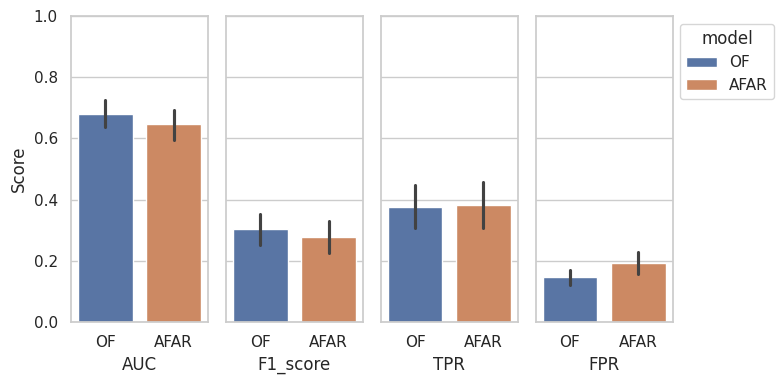

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
#sns.set_style(rc = {'axes.facecolor': 'white'})
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

fig, axs = plt.subplots(1, len(DVs), sharex=False, sharey=True, figsize=(8, 4))
for DV in range(len(DVs)):
  if DV == len(DVs)-1:
    ax = sns.barplot(df_comb, x="model", y=DVs[DV], hue="model", ax=axs[DV], legend=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
  else:
    ax = sns.barplot(df_comb, x="model", y=DVs[DV], hue="model", ax=axs[DV], legend=None)
  axs[DV].set_ylim(0, 1)
  axs[DV].set_xlabel(f'{DVs[DV]}')
  axs[DV].set_ylabel(f'Score')
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

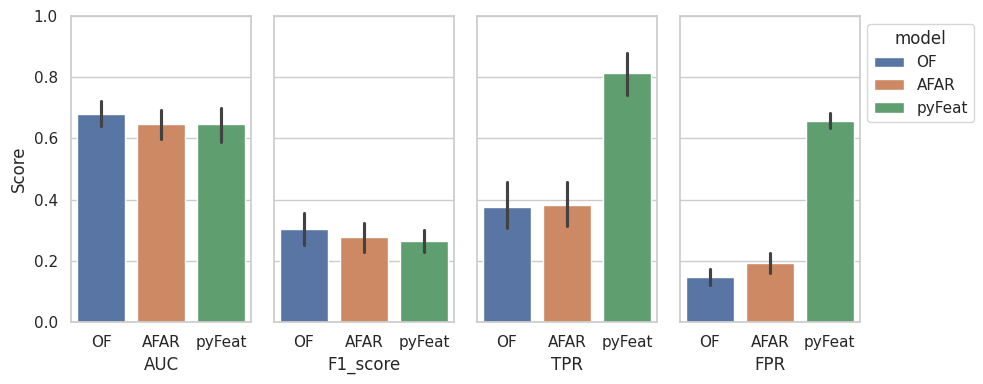

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
#sns.set_style(rc = {'axes.facecolor': 'white'})
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

fig, axs = plt.subplots(1, len(DVs), sharex=False, sharey=True, figsize=(10, 4))
for DV in range(len(DVs)):
  if DV == len(DVs)-1:
    ax = sns.barplot(df_three, x="model", y=DVs[DV], hue="model", ax=axs[DV], legend=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
  else:
    ax = sns.barplot(df_three, x="model", y=DVs[DV], hue="model", ax=axs[DV], legend=None)
  axs[DV].set_ylim(0, 1)
  axs[DV].set_xlabel(f'{DVs[DV]}')
  axs[DV].set_ylabel(f'Score')
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

# Within Model Comparison across avatars and animations

### Overall results

In [ ]:
# ANOVA wn "subjects"
aov = pg.rm_anova(dv='AUC', within='avatar',
                  subject='model', data=df_comb, detailed=True, effsize="np2")

aov.round(3)

,Source,SS,DF,MS,F,p-unc,np2,eps
0,avatar,0.001,3,0.0,1.017,0.495,0.504,0.333
1,Error,0.001,3,0.0,NaN,NaN,NaN,NaN


In [ ]:
DVs=["F1_score", 'TPR', 'FPR']
for DV in DVs:
  f_model = friedmanchisquare(*[group[DV].values for name, group in df_comb.groupby('avatar')])
  print(f"Friedman's test for {DV} results:")
  print("Statistic:", round(f_model.statistic,3))
  print("p-value:", round(f_model.pvalue,3))

Friedman's test for F1_score results:
Statistic: 4.466
p-value: 0.215
Friedman's test for TPR results:
Statistic: 32.891
p-value: 0.0
Friedman's test for FPR results:
Statistic: 82.525
p-value: 0.0


In [ ]:
DVs=['avatar','animation','AUC','F1_score', 'model']
df_comb[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-8-46a0fd21641b>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score              \
        count  mean   std   min   25%   50%   75%   max    count  mean   std   
avatar                                                                         
Ada     36.00  0.66  0.20  0.25  0.53  0.67  0.79  1.00    36.00  0.30  0.26   
Cooper  36.00  0.67  0.21  0.21  0.56  0.69  0.79  1.00    36.00  0.30  0.19   
Garry   36.00  0.68  0.20  0.22  0.54  0.71  0.79  1.00    36.00  0.30  0.21   
Pia     36.00  0.65  0.20  0.26  0.53  0.64  0.78  1.00    36.00  0.26  0.24   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.00  0.01  0.32  0.49  0.90  
Cooper  0.00  0.19  0.32  0.45  0.58  
Garry   0.00  0.06  0.34  0.48  0.66  
Pia     0.00  0.00  0.24  0.40  0.90

In [ ]:
DVs=['avatar','animation','TPR','FPR', 'model']
df_comb[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)
#df_comb.columns

<ipython-input-10-59cea8449f49>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


TPR                                              FPR              \
        count  mean   std   min   25%   50%   75%   max  count  mean   std   
avatar                                                                       
Ada     36.00  0.29  0.27  0.00  0.02  0.28  0.42  1.00  36.00  0.09  0.10   
Cooper  36.00  0.48  0.33  0.00  0.36  0.48  0.69  1.00  36.00  0.25  0.11   
Garry   36.00  0.47  0.34  0.00  0.17  0.47  0.69  1.00  36.00  0.23  0.11   
Pia     36.00  0.29  0.27  0.00  0.00  0.20  0.42  1.00  36.00  0.11  0.11   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.00  0.02  0.06  0.12  0.48  
Cooper  0.12  0.17  0.21  0.29  0.63  
Garry   0.08  0.13  0.22  0.27  0.57  
Pia     0.00  0.03  0.10  0.14  0.46

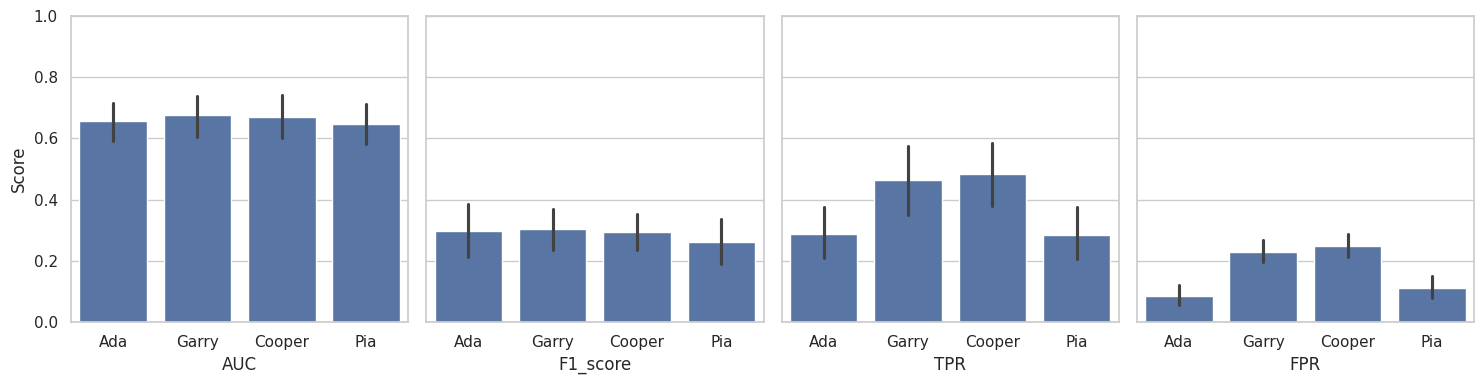

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
#sns.set_style(rc = {'axes.facecolor': 'white'})
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

fig, axs = plt.subplots(1, len(DVs), sharex=False, sharey=True, figsize=(15, 4))
for DV in range(len(DVs)):
  ax = sns.barplot(df_comb, x="avatar", y=DVs[DV], ax=axs[DV])
  axs[DV].set_ylim(0, 1)
  axs[DV].set_xlabel(f'{DVs[DV]}')
  axs[DV].set_ylabel(f'Score')
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

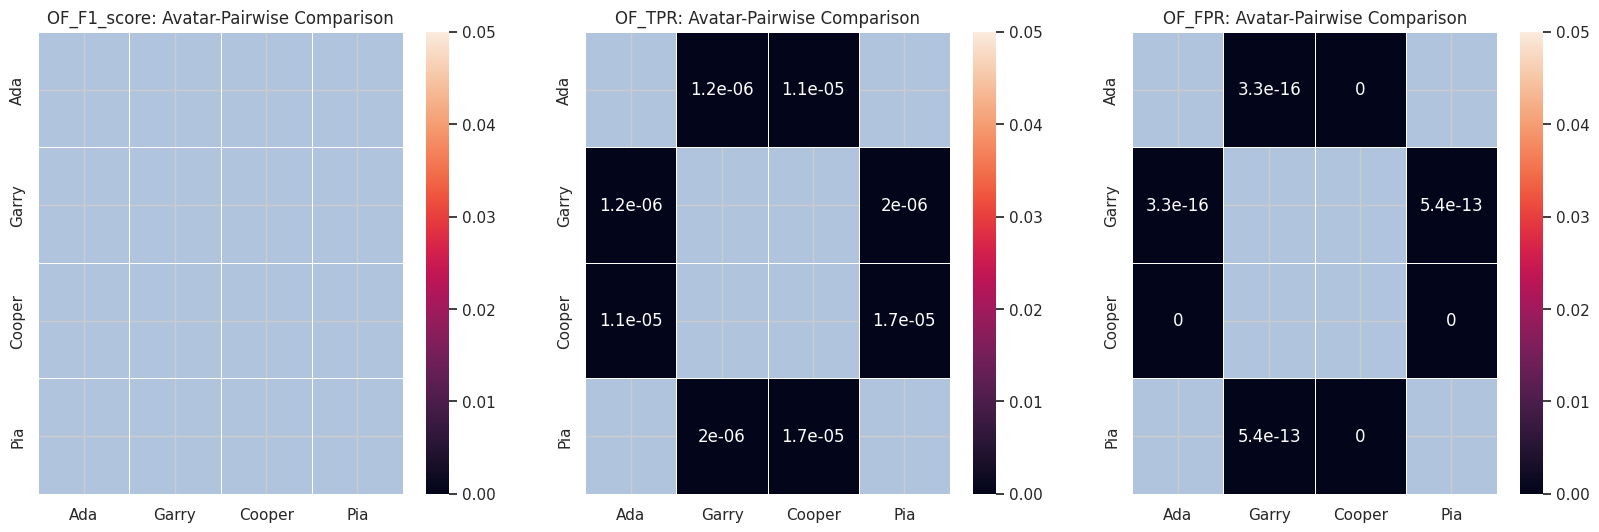

In [ ]:
# Running posthoc analysis for the significant results: Perform Nemenyi post-hoc test
DVs=["F1_score", 'TPR', 'FPR']
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})

fig, axs = plt.subplots(1, len(DVs), figsize=(20, 6))
for DV in range(len(DVs)):
  results_df = sp.posthoc_nemenyi_friedman(df_comb, y_col=DVs[DV], block_col='animation', group_col='avatar', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[DV])
  axs[DV].set_title(f'OF_{DVs[DV]}: Avatar-Pairwise Comparison')

In [ ]:
# ANOVA wn "subjects"
aov = pg.rm_anova(dv='AUC', within='animation',
                  subject='model', data=df_comb, detailed=True, effsize="np2")

aov.round(3)

,Source,SS,DF,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,animation,0.696,17,0.041,2.199,0.057,0.378,0.687,0.059,False,8.084607e+28,0.0
1,Error,0.317,17,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
DVs=["F1_score", 'TPR', 'FPR']
for DV in DVs:
  f_model = friedmanchisquare(*[group[DV].values for name, group in df_comb.groupby('animation')])
  print(f"Friedman's test for {DV} results:")
  print("Statistic:", round(f_model.statistic,3))
  print("p-value:", round(f_model.pvalue,3))

Friedman's test for F1_score results:
Statistic: 55.115
p-value: 0.0
Friedman's test for TPR results:
Statistic: 53.028
p-value: 0.0
Friedman's test for FPR results:
Statistic: 90.889
p-value: 0.0


In [ ]:
DVs=['avatar','animation','AUC','F1_score', 'model']
df_comb[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)

<ipython-input-35-8040461159af>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score        \
          count  mean   std   min   25%   50%   75%   max    count  mean   
animation                                                                  
AU01       8.00  0.72  0.18  0.45  0.64  0.68  0.79  1.00     8.00  0.37   
AU02       8.00  0.53  0.16  0.38  0.41  0.50  0.58  0.83     8.00  0.06   
AU04       8.00  0.70  0.29  0.32  0.42  0.77  0.95  0.99     8.00  0.28   
AU06       8.00  0.26  0.07  0.21  0.22  0.25  0.27  0.41     8.00  0.00   
AU07       8.00  0.90  0.15  0.54  0.90  0.95  1.00  1.00     8.00  0.50   
AU10       8.00  0.69  0.26  0.29  0.55  0.80  0.88  0.92     8.00  0.25   
AU12       8.00  0.64  0.16  0.38  0.53  0.72  0.74  0.79     8.00  0.21   
AU14       8.00  0.90  0.03  0.84  0.88  0.90  0.91  0.93     8.00  0.41   
AU15       8.00  0.71  0.15  0.53  0.62  0.68  0.78  0.98     8.00  0.15   
AU17       8.00  0.72  0.11  0.61  0.65  0.69  0.77  0.95     8.00  0.11   
AU23       8.00  0.72  0.26  0.40  0.49  0.70  0.99  1.00     8.00  0.30   
browsAU10  8.00  0.60  0.10  0.46  0.54  0.60  0.68  0.73     8.00  0.39   
browsAU12  8.00  0.47  0.08  0.37  0.39  0.48  0.54  0.56     8.00  0.30   
browsAU14  8.00  0.63  0.09  0.49  0.58  0.64  0.70  0.74     8.00  0.44   
browsAU15  8.00  0.71  0.07  0.57  0.70  0.73  0.75  0.81     8.00  0.37   
browsAU17  8.00  0.67  0.11  0.46  0.62  0.69  0.75  0.78     8.00  0.29   
browsAU23  8.00  0.70  0.07  0.58  0.66  0.68  0.76  0.78     8.00  0.42   
browsAll   8.00  0.66  0.11  0.43  0.62  0.67  0.74  0.78     8.00  0.34   

                                               
            std   min   25%   50%   75%   max  
animation                                      
AU01       0.27  0.00  0.25  0.28  0.53  0.88  
AU02       0.10  0.00  0.00  0.00  0.09  0.25  
AU04       0.30  0.00  0.00  0.24  0.53  0.66  
AU06       0.00  0.00  0.00  0.00  0.00  0.00  
AU07       0.32  0.00  0.35  0.58  0.65  0.90  
AU10       0.23  0.00  0.01  0.29  0.42  0.58  
AU12       0.08  0.06  0.19  0.22  0.26  0.32  
AU14       0.13  0.33  0.35  0.37  0.40  0.74  
AU15       0.19  0.00  0.00  0.06  0.32  0.45  
AU17       0.23  0.00  0.00  0.00  0.07  0.63  
AU23       0.37  0.00  0.00  0.16  0.55  0.90  
browsAU10  0.10  0.23  0.32  0.37  0.49  0.50  
browsAU12  0.04  0.25  0.27  0.30  0.33  0.36  
browsAU14  0.07  0.33  0.40  0.42  0.47  0.57  
browsAU15  0.16  0.08  0.26  0.40  0.51  0.54  
browsAU17  0.13  0.10  0.19  0.33  0.39  0.43  
browsAU23  0.13  0.21  0.35  0.46  0.51  0.57  
browsAll   0.12  0.16  0.28  0.33  0.44  0.49

In [ ]:
DVs=['avatar','animation','TPR','FPR', 'model']
df_comb[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)
#df_comb.columns

<ipython-input-36-81e521edcf92>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_comb[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


TPR                                             FPR              \
          count  mean   std   min   25%   50%   75%   max count  mean   std   
animation                                                                     
AU01       8.00  0.45  0.23  0.00  0.37  0.42  0.59  0.80  8.00  0.14  0.14   
AU02       8.00  0.10  0.18  0.00  0.00  0.00  0.11  0.47  8.00  0.13  0.08   
AU04       8.00  0.49  0.53  0.00  0.00  0.47  1.00  1.00  8.00  0.09  0.06   
AU06       8.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  8.00  0.16  0.10   
AU07       8.00  0.67  0.42  0.00  0.39  0.88  1.00  1.00  8.00  0.11  0.10   
AU10       8.00  0.44  0.37  0.00  0.02  0.55  0.79  0.82  8.00  0.17  0.08   
AU12       8.00  0.54  0.18  0.20  0.44  0.58  0.68  0.73  8.00  0.31  0.10   
AU14       8.00  0.76  0.18  0.45  0.71  0.79  0.87  1.00  8.00  0.17  0.09   
AU15       8.00  0.28  0.42  0.00  0.00  0.05  0.43  1.00  8.00  0.13  0.11   
AU17       8.00  0.14  0.27  0.00  0.00  0.00  0.12  0.67  8.00  0.14  0.11   
AU23       8.00  0.41  0.46  0.00  0.00  0.29  0.80  1.00  8.00  0.11  0.10   
browsAU10  8.00  0.40  0.13  0.20  0.32  0.40  0.46  0.57  8.00  0.22  0.10   
browsAU12  8.00  0.43  0.07  0.34  0.38  0.42  0.46  0.55  8.00  0.47  0.10   
browsAU14  8.00  0.48  0.11  0.34  0.40  0.46  0.56  0.66  8.00  0.25  0.11   
browsAU15  8.00  0.32  0.19  0.06  0.17  0.32  0.46  0.54  8.00  0.10  0.06   
browsAU17  8.00  0.27  0.16  0.07  0.13  0.26  0.35  0.53  8.00  0.15  0.10   
browsAU23  8.00  0.35  0.15  0.13  0.28  0.37  0.44  0.57  8.00  0.09  0.08   
browsAll   8.00  0.31  0.15  0.12  0.19  0.30  0.45  0.50  8.00  0.10  0.08   

                                         
            min   25%   50%   75%   max  
animation                                
AU01       0.00  0.05  0.11  0.18  0.38  
AU02       0.02  0.07  0.13  0.20  0.25  
AU04       0.00  0.07  0.09  0.13  0.16  
AU06       0.04  0.09  0.15  0.22  0.32  
AU07       0.00  0.02  0.11  0.14  0.27  
AU10       0.03  0.13  0.15  0.22  0.29  
AU12       0.16  0.26  0.30  0.38  0.44  
AU14       0.02  0.11  0.18  0.25  0.28  
AU15       0.00  0.05  0.15  0.20  0.31  
AU17       0.00  0.06  0.15  0.20  0.32  
AU23       0.00  0.01  0.13  0.19  0.23  
browsAU10  0.05  0.19  0.22  0.24  0.42  
browsAU12  0.27  0.46  0.47  0.50  0.63  
browsAU14  0.09  0.20  0.24  0.27  0.47  
browsAU15  0.00  0.06  0.11  0.15  0.17  
browsAU17  0.00  0.12  0.13  0.18  0.31  
browsAU23  0.00  0.01  0.11  0.13  0.24  
browsAll   0.00  0.05  0.10  0.12  0.25

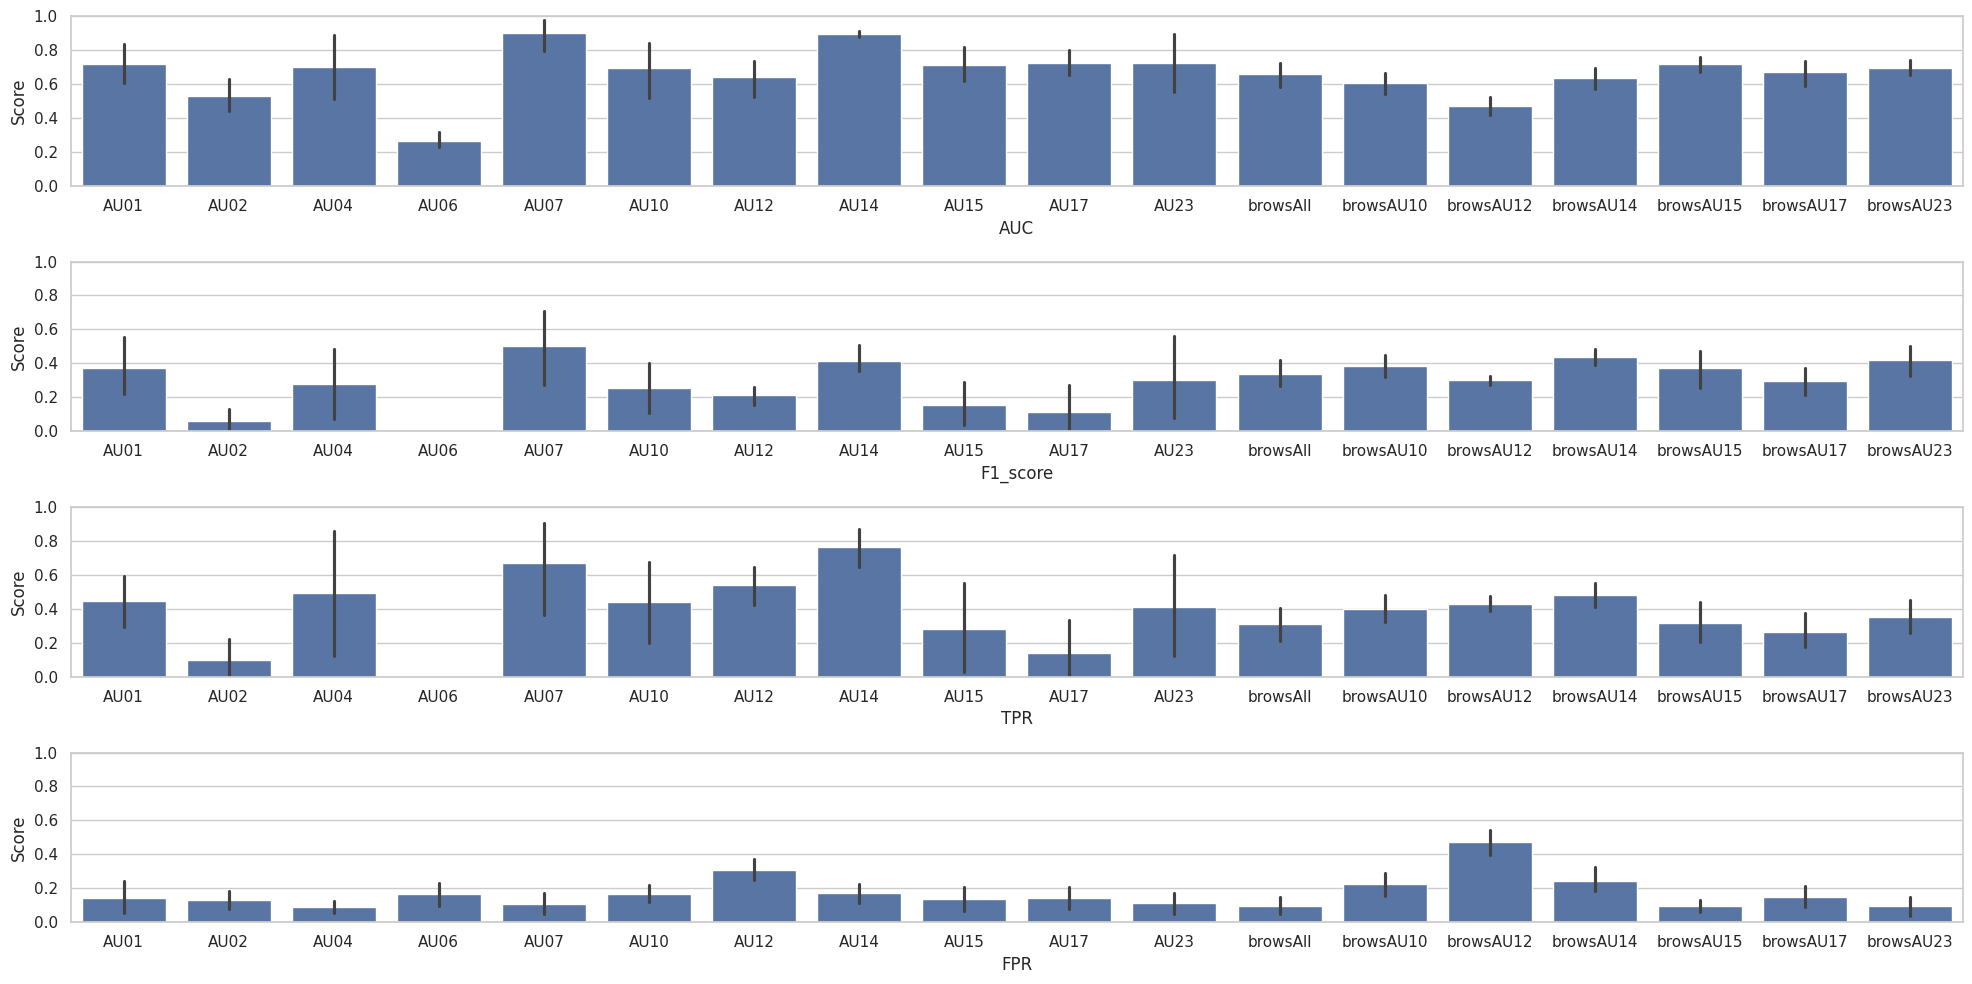

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
#sns.set_style(rc = {'axes.facecolor': 'white'})
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=True, figsize=(20, 10))
for DV in range(len(DVs)):
  ax = sns.barplot(df_comb, x="animation", y=DVs[DV], ax=axs[DV])
  axs[DV].set_ylim(0, 1)
  axs[DV].set_xlabel(f'{DVs[DV]}')
  axs[DV].set_ylabel(f'Score')
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

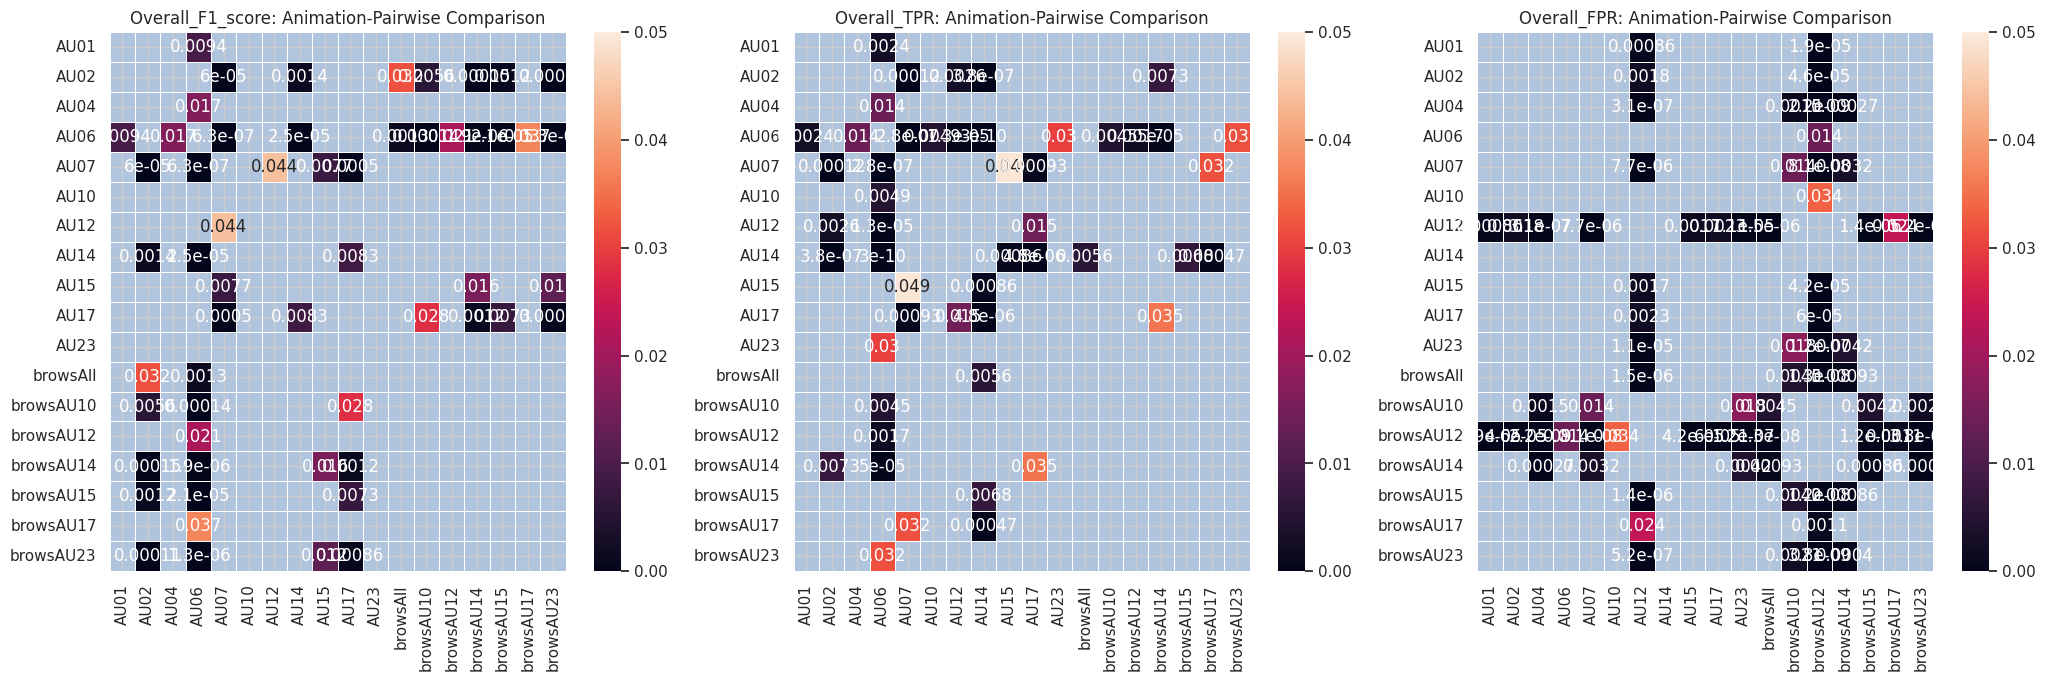

In [ ]:
# Running posthoc analysis for the significant results: Perform Nemenyi post-hoc test
DVs=["F1_score", 'TPR', 'FPR']
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})

fig, axs = plt.subplots(1, len(DVs), figsize=(25, 7))
for DV in range(len(DVs)):
  results_df = sp.posthoc_nemenyi_friedman(df_comb, y_col=DVs[DV], block_col='avatar', group_col='animation', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[DV])
  axs[DV].set_title(f'Overall_{DVs[DV]}: Animation-Pairwise Comparison')

### Separate Models: Avatar

In [ ]:
DVs=['avatar','animation', 'AUC', 'F1_score']
df_OF_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-50-61450e2930d1>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_OF_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score              \
        count  mean   std   min   25%   50%   75%   max    count  mean   std   
avatar                                                                         
Ada     18.00  0.69  0.19  0.25  0.60  0.69  0.80  0.95    18.00  0.37  0.26   
Cooper  18.00  0.68  0.19  0.21  0.57  0.69  0.78  1.00    18.00  0.29  0.21   
Garry   18.00  0.69  0.20  0.22  0.57  0.71  0.78  1.00    18.00  0.30  0.21   
Pia     18.00  0.66  0.18  0.26  0.59  0.64  0.75  1.00    18.00  0.24  0.23   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.00  0.25  0.36  0.53  0.86  
Cooper  0.00  0.06  0.34  0.45  0.58  
Garry   0.00  0.09  0.35  0.48  0.58  
Pia     0.00  0.03  0.24  0.37  0.90

In [ ]:
DVs=['avatar','animation', 'TPR', 'FPR']
df_OF_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-33-de3f6955672c>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_OF_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


TPR                                              FPR              \
        count  mean   std   min   25%   50%   75%   max  count  mean   std   
avatar                                                                       
Ada     18.00  0.32  0.24  0.00  0.15  0.33  0.45  0.76  18.00  0.04  0.07   
Cooper  18.00  0.44  0.34  0.00  0.06  0.44  0.69  1.00  18.00  0.20  0.08   
Garry   18.00  0.45  0.34  0.00  0.13  0.45  0.65  1.00  18.00  0.20  0.10   
Pia     18.00  0.31  0.31  0.00  0.03  0.18  0.42  1.00  18.00  0.14  0.10   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.00  0.00  0.02  0.04  0.27  
Cooper  0.12  0.14  0.19  0.21  0.46  
Garry   0.09  0.13  0.19  0.25  0.48  
Pia     0.02  0.10  0.11  0.14  0.45

In [ ]:
DVs=['avatar','animation', 'AUC', 'F1_score']
df_AFAR_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-51-52a98be6bdee>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_AFAR_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score              \
        count  mean   std   min   25%   50%   75%   max    count  mean   std   
avatar                                                                         
Ada     18.00  0.62  0.21  0.25  0.46  0.59  0.75  1.00    18.00  0.22  0.25   
Cooper  18.00  0.66  0.22  0.21  0.54  0.69  0.79  1.00    18.00  0.30  0.18   
Garry   18.00  0.67  0.20  0.33  0.49  0.72  0.81  0.99    18.00  0.31  0.22   
Pia     18.00  0.63  0.23  0.29  0.52  0.61  0.82  1.00    18.00  0.28  0.26   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.00  0.00  0.13  0.33  0.90  
Cooper  0.00  0.21  0.31  0.44  0.53  
Garry   0.00  0.10  0.33  0.46  0.66  
Pia     0.00  0.05  0.24  0.39  0.88

In [ ]:
DVs=['avatar','animation', 'TPR', 'FPR']
df_AFAR_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-52-bcfb3a04ab4a>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_AFAR_all[DVs].groupby('avatar').describe().applymap('{:,.2f}'.format)


TPR                                              FPR              \
        count  mean   std   min   25%   50%   75%   max  count  mean   std   
avatar                                                                       
Ada     18.00  0.25  0.29  0.00  0.01  0.11  0.39  1.00  18.00  0.13  0.11   
Cooper  18.00  0.53  0.31  0.00  0.43  0.55  0.65  1.00  18.00  0.30  0.12   
Garry   18.00  0.48  0.35  0.00  0.24  0.48  0.72  1.00  18.00  0.26  0.12   
Pia     18.00  0.26  0.23  0.00  0.03  0.23  0.40  0.80  18.00  0.08  0.12   

                                      
         min   25%   50%   75%   max  
avatar                                
Ada     0.01  0.07  0.10  0.14  0.48  
Cooper  0.16  0.21  0.28  0.32  0.63  
Garry   0.08  0.21  0.24  0.31  0.57  
Pia     0.00  0.00  0.04  0.11  0.46

In [ ]:
# Difference wn models: Friedman's Test; DVs at focus: 'F1 score', 'TPR', 'FPR'
DVs=["F1_score", 'TPR', 'FPR']
for DV in DVs:
  f_model_OF = friedmanchisquare(*[group[DV].values for name, group in df_comb[df_comb['model'] == df_comb['model'].unique()[0]].groupby('avatar')])
  print(f"Friedman's test for OF {DV} results:")
  print("Statistic:", round(f_model_OF.statistic,3))
  print("p-value:", round(f_model_OF.pvalue,3))

  f_model_AFAR = friedmanchisquare(*[group[DV].values for name, group in df_comb[df_comb['model'] == df_comb['model'].unique()[1]].groupby('avatar')])
  print(f"Friedman's test for AFAR {DV} results:")
  print("Statistic:", round(f_model_AFAR.statistic,3))
  print("p-value:", round(f_model_AFAR.pvalue,3))


Friedman's test for OF F1_score results:
Statistic: 9.846
p-value: 0.02
Friedman's test for AFAR F1_score results:
Statistic: 2.889
p-value: 0.409
Friedman's test for OF TPR results:
Statistic: 19.986
p-value: 0.0
Friedman's test for AFAR TPR results:
Statistic: 14.381
p-value: 0.002
Friedman's test for OF FPR results:
Statistic: 49.312
p-value: 0.0
Friedman's test for AFAR FPR results:
Statistic: 44.533
p-value: 0.0


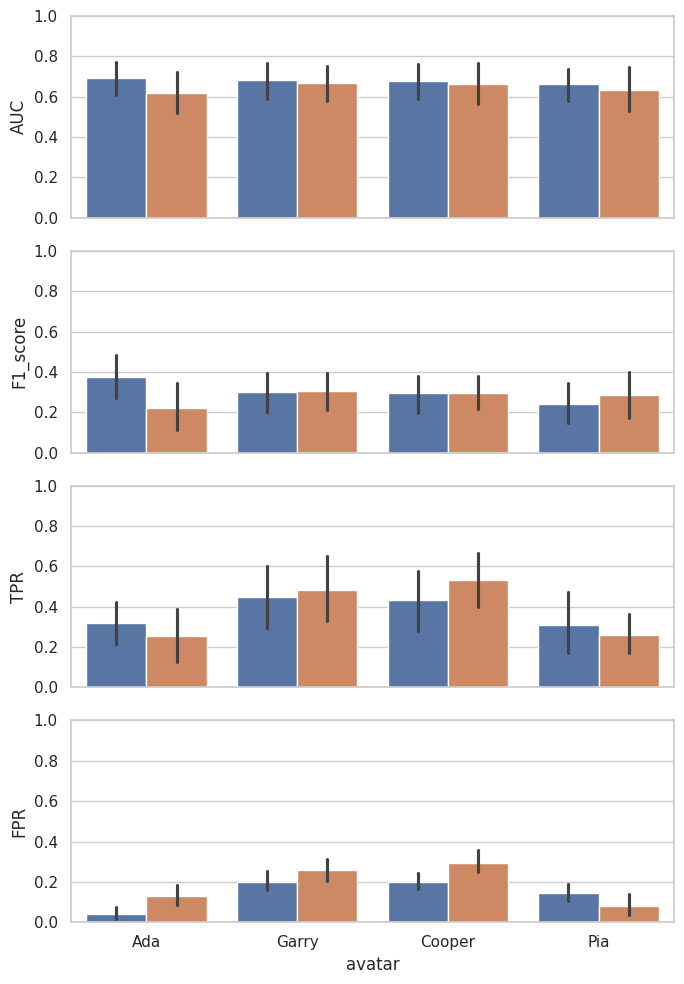

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=True, sharey=True, figsize=(7, 10))
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

for DV in range(len(DVs)):
  sns.barplot(df_comb, x="avatar", y=DVs[DV], hue='model', ax=axs[DV],legend=None)
  axs[DV].set_ylim(0, 1)
  #sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

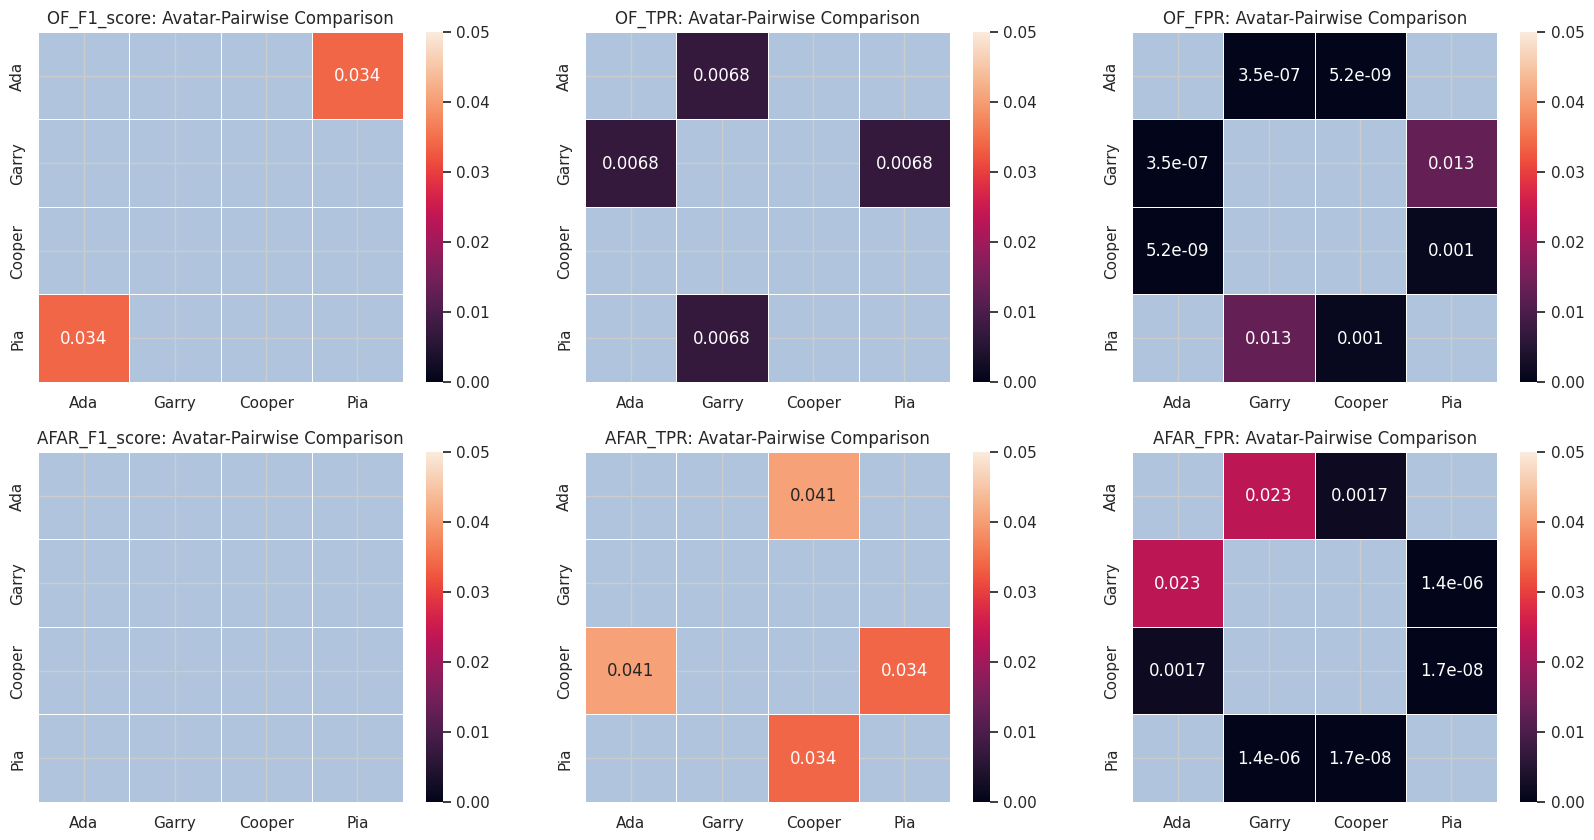

In [ ]:
# Running posthoc analysis for the significant results: Perform Nemenyi post-hoc test
DVs=["F1_score", 'TPR', 'FPR']
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})

fig, axs = plt.subplots(2, len(DVs), figsize=(20, 10))
for DV in range(len(DVs)):
  results_df = sp.posthoc_nemenyi_friedman(df[df['model'] == df['model'].unique()[0]], y_col=DVs[DV], block_col='animation', group_col='avatar', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[0,DV])
  axs[0,DV].set_title(f'OF_{DVs[DV]}: Avatar-Pairwise Comparison')
  results_df = sp.posthoc_nemenyi_friedman(df[df['model'] == df['model'].unique()[1]], y_col=DVs[DV], block_col='animation', group_col='avatar', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[1,DV])
  axs[1,DV].set_title(f'AFAR_{DVs[DV]}: Avatar-Pairwise Comparison')



### Separate Model Comparisons among Animations

In [ ]:
DVs=['avatar','animation', 'AUC', 'F1_score']
df_OF_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)

<ipython-input-54-72a7279f7fd6>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_OF_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score        \
          count  mean   std   min   25%   50%   75%   max    count  mean   
animation                                                                  
AU01       4.00  0.65  0.04  0.61  0.64  0.65  0.67  0.71     4.00  0.34   
AU02       4.00  0.45  0.07  0.40  0.41  0.43  0.47  0.55     4.00  0.01   
AU04       4.00  0.73  0.26  0.40  0.58  0.77  0.93  0.98     4.00  0.27   
AU06       4.00  0.24  0.02  0.21  0.22  0.24  0.25  0.26     4.00  0.00   
AU07       4.00  0.99  0.02  0.95  0.99  1.00  1.00  1.00     4.00  0.73   
AU10       4.00  0.89  0.02  0.87  0.87  0.88  0.90  0.92     4.00  0.45   
AU12       4.00  0.76  0.04  0.72  0.73  0.76  0.78  0.79     4.00  0.26   
AU14       4.00  0.91  0.03  0.87  0.90  0.92  0.92  0.93     4.00  0.47   
AU15       4.00  0.60  0.08  0.53  0.54  0.60  0.66  0.69     4.00  0.12   
AU17       4.00  0.77  0.12  0.68  0.70  0.73  0.81  0.95     4.00  0.16   
AU23       4.00  0.49  0.07  0.40  0.47  0.49  0.51  0.58     4.00  0.00   
browsAU10  4.00  0.68  0.04  0.63  0.66  0.69  0.71  0.73     4.00  0.47   
browsAU12  4.00  0.54  0.02  0.50  0.53  0.54  0.55  0.56     4.00  0.32   
browsAU14  4.00  0.67  0.04  0.62  0.66  0.68  0.70  0.71     4.00  0.45   
browsAU15  4.00  0.74  0.05  0.70  0.72  0.73  0.75  0.81     4.00  0.40   
browsAU17  4.00  0.75  0.04  0.68  0.72  0.76  0.78  0.78     4.00  0.31   
browsAU23  4.00  0.65  0.05  0.58  0.65  0.67  0.68  0.69     4.00  0.32   
browsAll   4.00  0.71  0.06  0.64  0.68  0.72  0.76  0.78     4.00  0.36   

                                               
            std   min   25%   50%   75%   max  
animation                                      
AU01       0.13  0.27  0.28  0.28  0.35  0.54  
AU02       0.02  0.00  0.00  0.00  0.01  0.04  
AU04       0.31  0.00  0.00  0.26  0.53  0.56  
AU06       0.00  0.00  0.00  0.00  0.00  0.00  
AU07       0.17  0.58  0.58  0.72  0.87  0.90  
AU10       0.09  0.36  0.40  0.43  0.48  0.58  
AU12       0.04  0.21  0.25  0.26  0.28  0.32  
AU14       0.19  0.34  0.36  0.40  0.51  0.74  
AU15       0.17  0.00  0.00  0.06  0.18  0.36  
AU17       0.32  0.00  0.00  0.00  0.16  0.63  
AU23       0.00  0.00  0.00  0.00  0.00  0.00  
browsAU10  0.05  0.40  0.46  0.49  0.50  0.50  
browsAU12  0.03  0.28  0.31  0.33  0.34  0.36  
browsAU14  0.04  0.39  0.43  0.45  0.47  0.49  
browsAU15  0.11  0.27  0.34  0.40  0.47  0.51  
browsAU17  0.11  0.16  0.26  0.34  0.39  0.42  
browsAU23  0.12  0.21  0.23  0.31  0.41  0.46  
browsAll   0.12  0.21  0.30  0.38  0.45  0.49

In [ ]:
DVs=['avatar','animation', 'TPR', 'FPR']
df_OF_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)

<ipython-input-55-e0bfcd462b86>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_OF_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


TPR                                             FPR              \
          count  mean   std   min   25%   50%   75%   max count  mean   std   
animation                                                                     
AU01       4.00  0.39  0.03  0.37  0.37  0.39  0.41  0.43  4.00  0.09  0.06   
AU02       4.00  0.02  0.03  0.00  0.00  0.00  0.02  0.06  4.00  0.12  0.07   
AU04       4.00  0.50  0.58  0.00  0.00  0.50  1.00  1.00  4.00  0.10  0.05   
AU06       4.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  4.00  0.14  0.07   
AU07       4.00  0.94  0.12  0.76  0.94  1.00  1.00  1.00  4.00  0.06  0.06   
AU10       4.00  0.74  0.13  0.55  0.72  0.80  0.82  0.82  4.00  0.14  0.08   
AU12       4.00  0.67  0.07  0.57  0.65  0.68  0.70  0.73  4.00  0.29  0.09   
AU14       4.00  0.80  0.05  0.76  0.76  0.79  0.83  0.86  4.00  0.16  0.10   
AU15       4.00  0.10  0.13  0.00  0.00  0.05  0.15  0.29  4.00  0.12  0.09   
AU17       4.00  0.12  0.23  0.00  0.00  0.00  0.12  0.47  4.00  0.12  0.09   
AU23       4.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  4.00  0.12  0.09   
browsAU10  4.00  0.48  0.09  0.39  0.41  0.49  0.56  0.57  4.00  0.19  0.10   
browsAU12  4.00  0.43  0.05  0.38  0.39  0.42  0.46  0.48  4.00  0.42  0.10   
browsAU14  4.00  0.47  0.07  0.41  0.41  0.46  0.52  0.54  4.00  0.21  0.09   
browsAU15  4.00  0.32  0.13  0.19  0.22  0.32  0.42  0.43  4.00  0.08  0.05   
browsAU17  4.00  0.24  0.09  0.12  0.22  0.26  0.28  0.33  4.00  0.10  0.07   
browsAU23  4.00  0.26  0.14  0.13  0.16  0.25  0.36  0.42  4.00  0.10  0.07   
browsAll   4.00  0.33  0.17  0.18  0.19  0.32  0.46  0.50  4.00  0.09  0.06   

                                         
            min   25%   50%   75%   max  
animation                                
AU01       0.00  0.07  0.11  0.13  0.13  
AU02       0.02  0.09  0.13  0.15  0.19  
AU04       0.02  0.08  0.11  0.13  0.14  
AU06       0.06  0.09  0.15  0.20  0.20  
AU07       0.00  0.01  0.07  0.12  0.12  
AU10       0.03  0.11  0.15  0.18  0.22  
AU12       0.16  0.25  0.30  0.33  0.38  
AU14       0.02  0.11  0.18  0.23  0.26  
AU15       0.02  0.05  0.12  0.20  0.20  
AU17       0.00  0.07  0.15  0.19  0.19  
AU23       0.00  0.07  0.14  0.19  0.20  
browsAU10  0.05  0.18  0.23  0.24  0.27  
browsAU12  0.27  0.41  0.46  0.47  0.48  
browsAU14  0.09  0.20  0.25  0.27  0.27  
browsAU15  0.02  0.06  0.08  0.10  0.14  
browsAU17  0.00  0.10  0.13  0.14  0.15  
browsAU23  0.00  0.09  0.12  0.13  0.14  
browsAll   0.00  0.08  0.11  0.12  0.13

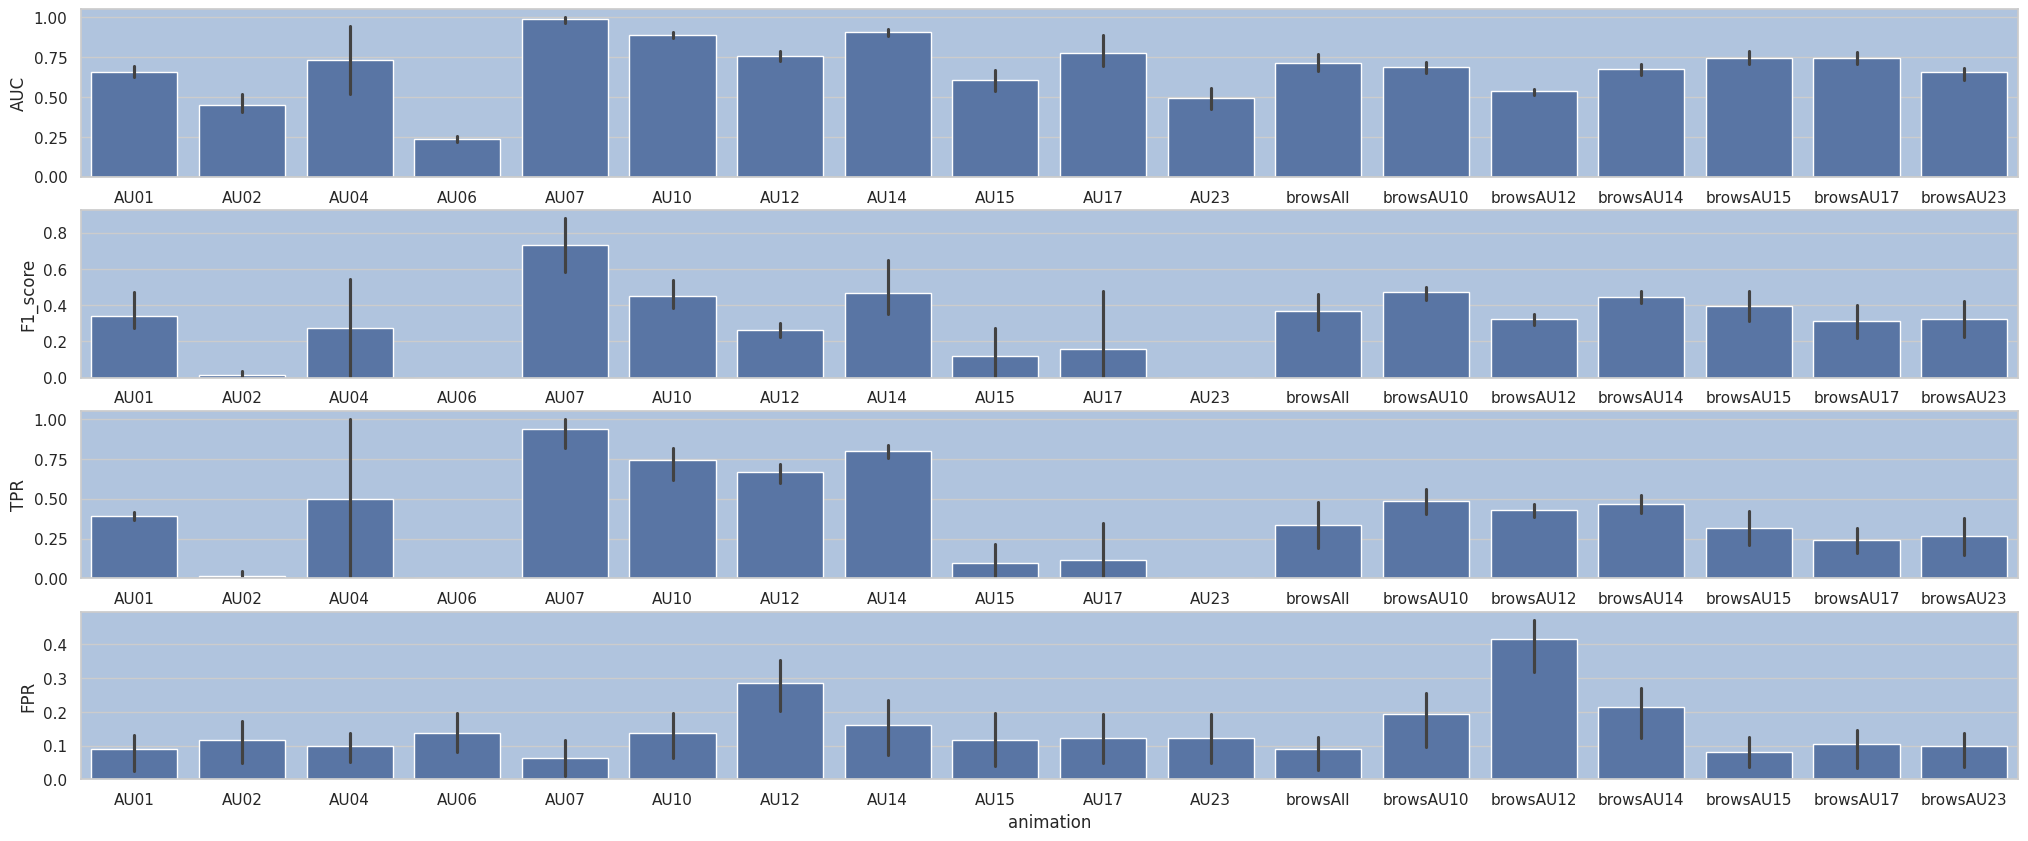

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(25, 10))
for DV in range(len(DVs)):
  ax= sns.barplot(df_OF_all, x="animation", y=DVs[DV], ax=axs[DV])

In [ ]:
DVs=['avatar','animation', 'AUC', 'F1_score']
df_AFAR_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)

<ipython-input-56-ed11d3d73322>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_AFAR_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


AUC                                           F1_score        \
          count  mean   std   min   25%   50%   75%   max    count  mean   
animation                                                                  
AU01       4.00  0.78  0.25  0.45  0.66  0.84  0.96  1.00     4.00  0.40   
AU02       4.00  0.60  0.19  0.38  0.51  0.60  0.70  0.83     4.00  0.11   
AU04       4.00  0.67  0.35  0.32  0.39  0.68  0.95  0.99     4.00  0.28   
AU06       4.00  0.29  0.09  0.21  0.24  0.28  0.33  0.41     4.00  0.00   
AU07       4.00  0.82  0.19  0.54  0.80  0.89  0.91  0.94     4.00  0.28   
AU10       4.00  0.49  0.22  0.29  0.32  0.48  0.65  0.73     4.00  0.06   
AU12       4.00  0.52  0.16  0.38  0.41  0.49  0.61  0.73     4.00  0.16   
AU14       4.00  0.88  0.03  0.84  0.88  0.89  0.90  0.91     4.00  0.36   
AU15       4.00  0.82  0.14  0.66  0.73  0.81  0.90  0.98     4.00  0.19   
AU17       4.00  0.67  0.09  0.61  0.61  0.64  0.70  0.80     4.00  0.07   
AU23       4.00  0.95  0.08  0.83  0.94  0.99  1.00  1.00     4.00  0.61   
browsAU10  4.00  0.52  0.05  0.46  0.50  0.53  0.56  0.56     4.00  0.30   
browsAU12  4.00  0.41  0.04  0.37  0.39  0.39  0.41  0.46     4.00  0.28   
browsAU14  4.00  0.59  0.11  0.49  0.53  0.57  0.63  0.74     4.00  0.43   
browsAU15  4.00  0.69  0.09  0.57  0.65  0.71  0.75  0.76     4.00  0.35   
browsAU17  4.00  0.59  0.10  0.46  0.53  0.60  0.66  0.70     4.00  0.27   
browsAU23  4.00  0.74  0.06  0.65  0.73  0.76  0.77  0.78     4.00  0.52   
browsAll   4.00  0.60  0.13  0.43  0.56  0.61  0.65  0.74     4.00  0.31   

                                               
            std   min   25%   50%   75%   max  
animation                                      
AU01       0.38  0.00  0.15  0.36  0.61  0.88  
AU02       0.13  0.00  0.00  0.10  0.22  0.25  
AU04       0.34  0.00  0.00  0.24  0.52  0.66  
AU06       0.00  0.00  0.00  0.00  0.00  0.00  
AU07       0.28  0.00  0.07  0.26  0.47  0.58  
AU10       0.10  0.00  0.00  0.01  0.06  0.21  
AU12       0.08  0.06  0.12  0.17  0.21  0.23  
AU14       0.03  0.33  0.35  0.36  0.38  0.39  
AU15       0.22  0.00  0.00  0.15  0.34  0.45  
AU17       0.14  0.00  0.00  0.00  0.07  0.27  
AU23       0.26  0.32  0.44  0.61  0.77  0.90  
browsAU10  0.05  0.23  0.30  0.32  0.32  0.33  
browsAU12  0.04  0.25  0.26  0.27  0.29  0.34  
browsAU14  0.10  0.33  0.38  0.40  0.45  0.57  
browsAU15  0.22  0.08  0.20  0.38  0.53  0.54  
browsAU17  0.15  0.10  0.18  0.28  0.38  0.43  
browsAU23  0.04  0.47  0.49  0.52  0.55  0.57  
browsAll   0.13  0.16  0.27  0.31  0.36  0.47

In [ ]:
DVs=['avatar','animation', 'TPR', 'FPR']
df_AFAR_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)

<ipython-input-57-d9d60695621d>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_AFAR_all[DVs].groupby('animation').describe().applymap('{:,.2f}'.format)


TPR                                             FPR              \
          count  mean   std   min   25%   50%   75%   max count  mean   std   
animation                                                                     
AU01       4.00  0.50  0.35  0.00  0.43  0.60  0.67  0.80  4.00  0.19  0.19   
AU02       4.00  0.18  0.23  0.00  0.00  0.13  0.32  0.47  4.00  0.14  0.10   
AU04       4.00  0.48  0.56  0.00  0.00  0.47  0.95  1.00  4.00  0.08  0.06   
AU06       4.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  4.00  0.19  0.14   
AU07       4.00  0.40  0.45  0.00  0.08  0.30  0.62  1.00  4.00  0.15  0.11   
AU10       4.00  0.14  0.27  0.00  0.00  0.01  0.15  0.55  4.00  0.20  0.08   
AU12       4.00  0.41  0.16  0.20  0.36  0.43  0.48  0.59  4.00  0.33  0.11   
AU14       4.00  0.73  0.26  0.45  0.54  0.73  0.92  1.00  4.00  0.18  0.09   
AU15       4.00  0.47  0.54  0.00  0.00  0.44  0.91  1.00  4.00  0.15  0.13   
AU17       4.00  0.17  0.34  0.00  0.00  0.00  0.17  0.67  4.00  0.16  0.14   
AU23       4.00  0.83  0.21  0.57  0.69  0.87  1.00  1.00  4.00  0.10  0.11   
browsAU10  4.00  0.31  0.09  0.20  0.28  0.32  0.36  0.43  4.00  0.25  0.11   
browsAU12  4.00  0.43  0.09  0.34  0.36  0.41  0.48  0.55  4.00  0.53  0.08   
browsAU14  4.00  0.50  0.16  0.34  0.37  0.49  0.61  0.66  4.00  0.28  0.14   
browsAU15  4.00  0.32  0.26  0.06  0.11  0.34  0.54  0.54  4.00  0.11  0.08   
browsAU17  4.00  0.29  0.22  0.07  0.12  0.27  0.44  0.53  4.00  0.20  0.11   
browsAU23  4.00  0.44  0.11  0.31  0.39  0.45  0.50  0.57  4.00  0.09  0.11   
browsAll   4.00  0.29  0.16  0.12  0.18  0.30  0.41  0.46  4.00  0.11  0.11   

                                         
            min   25%   50%   75%   max  
animation                                
AU01       0.00  0.05  0.19  0.34  0.38  
AU02       0.05  0.07  0.14  0.22  0.25  
AU04       0.00  0.06  0.08  0.10  0.16  
AU06       0.04  0.09  0.20  0.30  0.32  
AU07       0.02  0.08  0.15  0.22  0.27  
AU10       0.12  0.14  0.19  0.25  0.29  
AU12       0.21  0.26  0.34  0.41  0.44  
AU14       0.09  0.11  0.18  0.26  0.28  
AU15       0.00  0.07  0.15  0.23  0.31  
AU17       0.03  0.06  0.15  0.25  0.32  
AU23       0.00  0.01  0.09  0.18  0.23  
browsAU10  0.18  0.19  0.21  0.27  0.42  
browsAU12  0.46  0.47  0.52  0.58  0.63  
browsAU14  0.16  0.20  0.24  0.31  0.47  
browsAU15  0.00  0.09  0.14  0.16  0.17  
browsAU17  0.07  0.12  0.20  0.28  0.31  
browsAU23  0.01  0.01  0.06  0.14  0.24  
browsAll   0.00  0.05  0.08  0.14  0.25

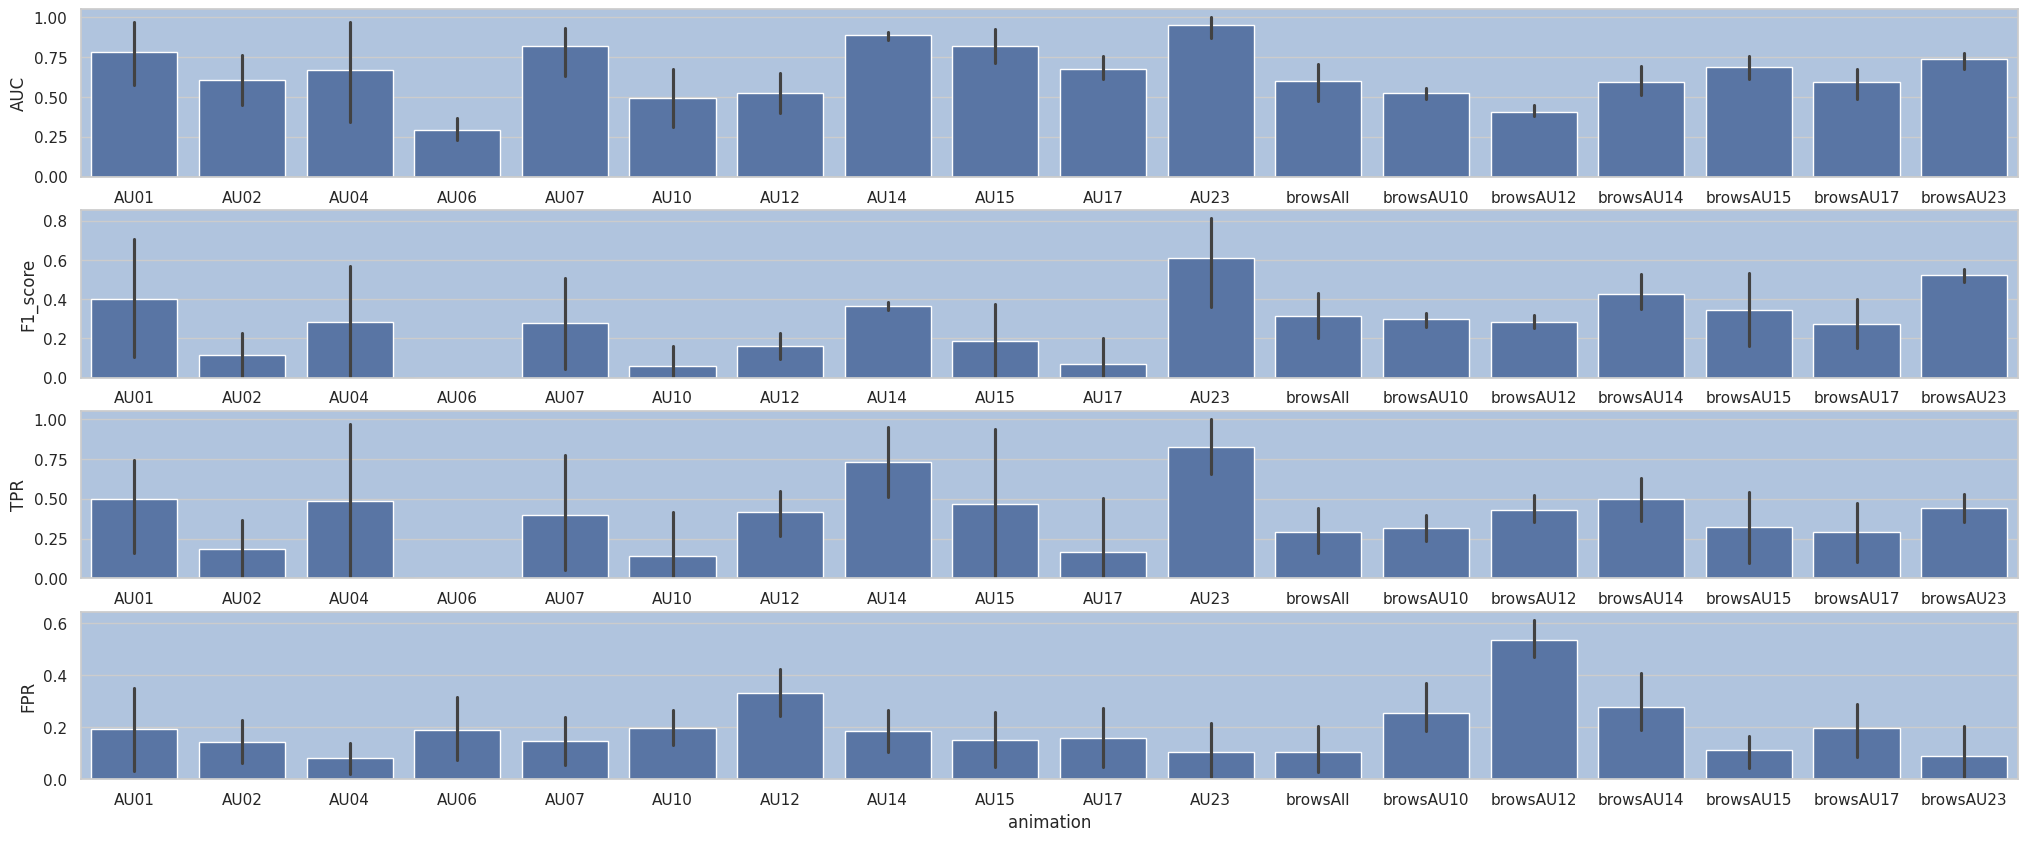

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(25, 10))
for DV in range(len(DVs)):
  ax= sns.barplot(df_AFAR_all, x="animation", y=DVs[DV], ax=axs[DV])

In [ ]:
# Difference wn models: Friedman's Test; DVs at focus: 'F1 score', 'TPR', 'FPR'
DVs=["F1_score", 'TPR', 'FPR']

for DV in DVs:
  f_model_OF = friedmanchisquare(*[group[DV].values for name, group in df_comb[df_comb['model'] == df_comb['model'].unique()[0]].groupby('animation')])
  print(f"Friedman's test for OF {DV} results:")
  print("Statistic:", round(f_model_OF.statistic,3))
  print("p-value:", round(f_model_OF.pvalue,3))

  f_model_AFAR = friedmanchisquare(*[group[DV].values for name, group in df_comb[df_comb['model'] == df_comb['model'].unique()[1]].groupby('animation')])
  print(f"Friedman's test for AFAR {DV} results:")
  print("Statistic:", round(f_model_AFAR.statistic,3))
  print("p-value:", round(f_model_AFAR.pvalue,3))


Friedman's test for OF F1_score results:
Statistic: 44.264
p-value: 0.0
Friedman's test for AFAR F1_score results:
Statistic: 36.58
p-value: 0.004
Friedman's test for OF TPR results:
Statistic: 53.743
p-value: 0.0
Friedman's test for AFAR TPR results:
Statistic: 31.229
p-value: 0.019
Friedman's test for OF FPR results:
Statistic: 54.534
p-value: 0.0
Friedman's test for AFAR FPR results:
Statistic: 45.923
p-value: 0.0


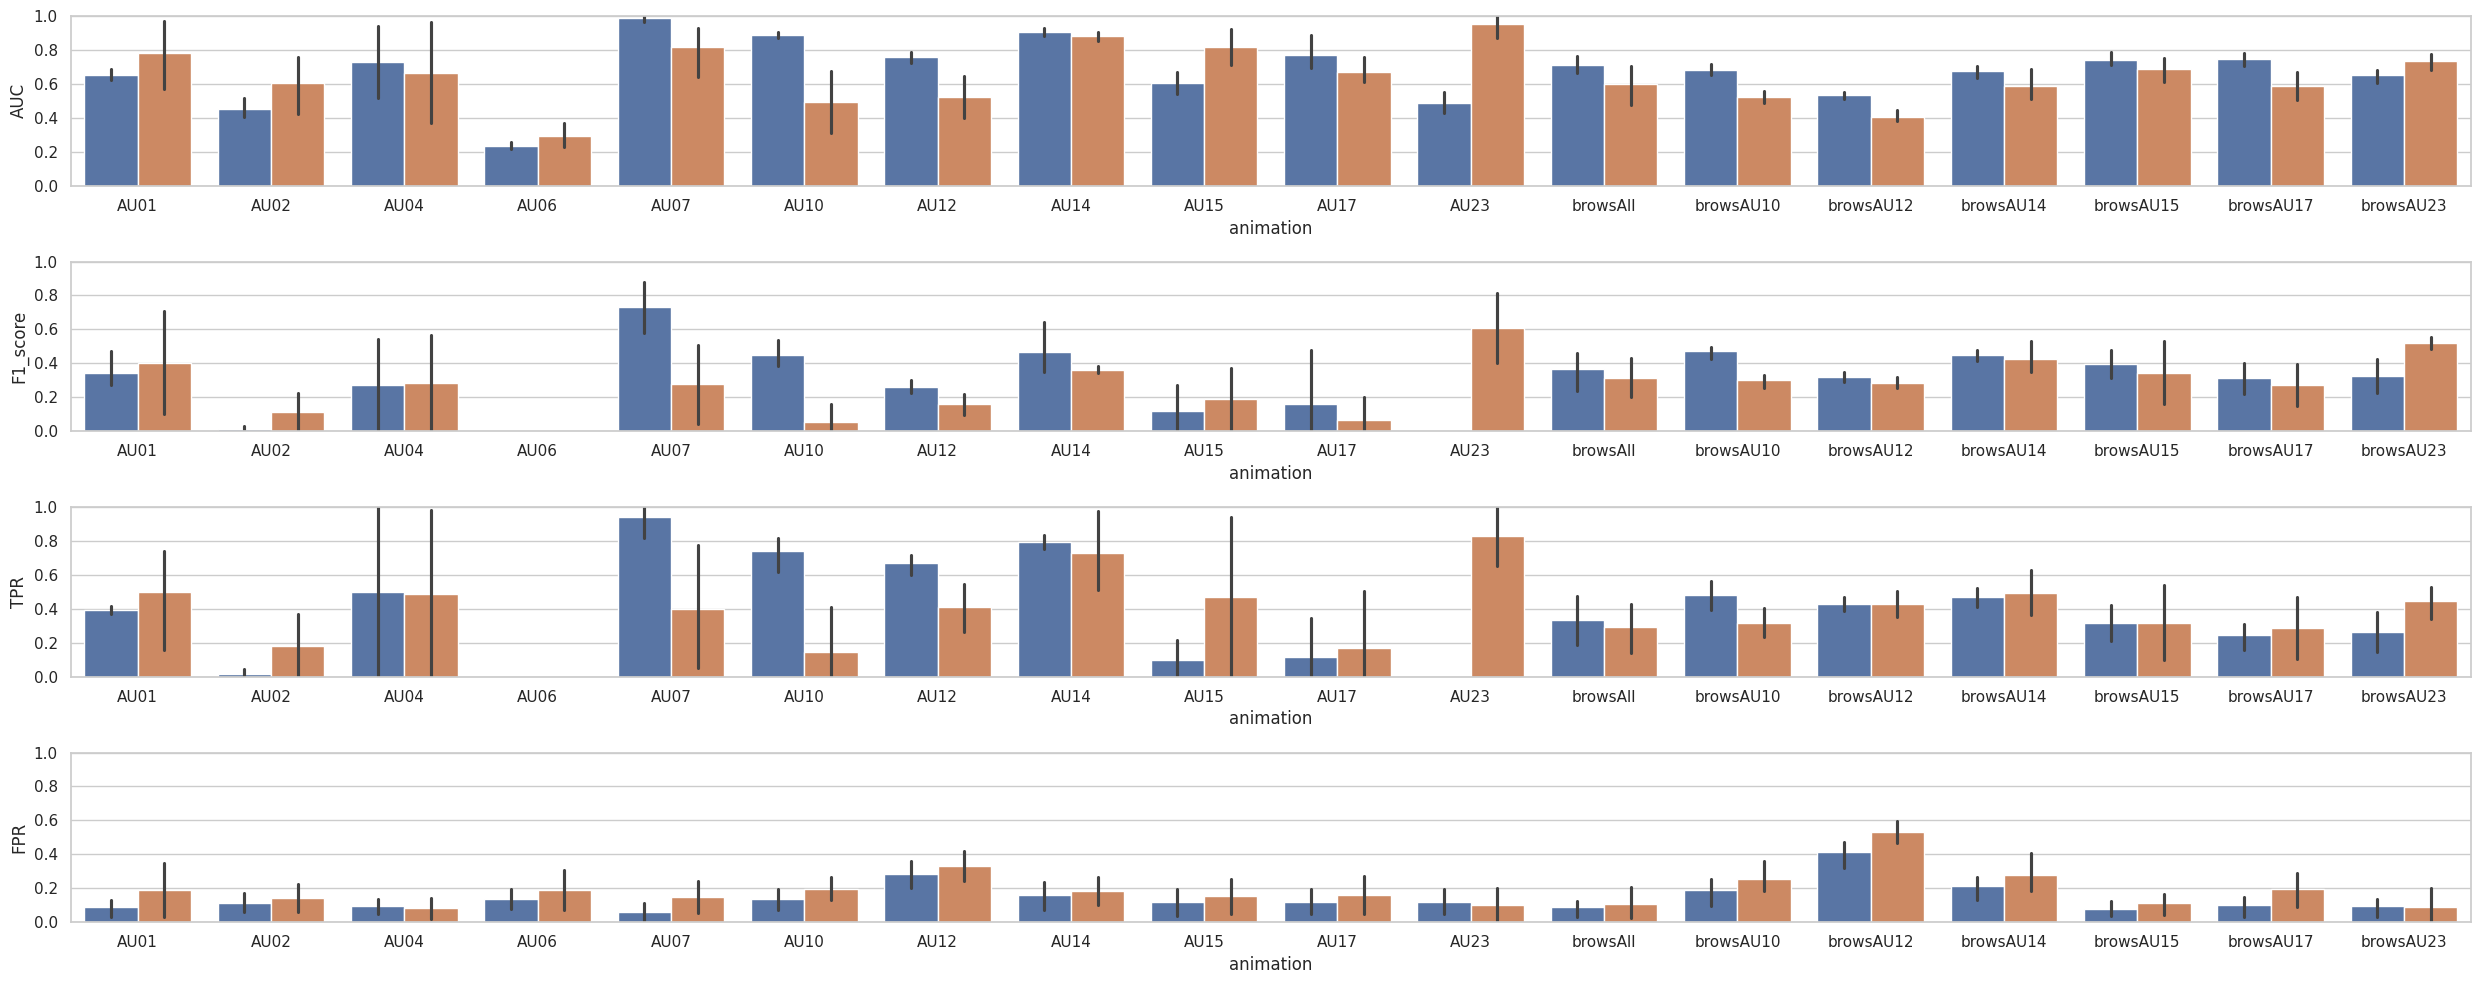

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=True, figsize=(25, 10))
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

for DV in range(len(DVs)):
  sns.barplot(df_comb, x="animation", y=DVs[DV], hue='model', ax=axs[DV],legend=None)
  axs[DV].set_ylim(0, 1)
  #sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

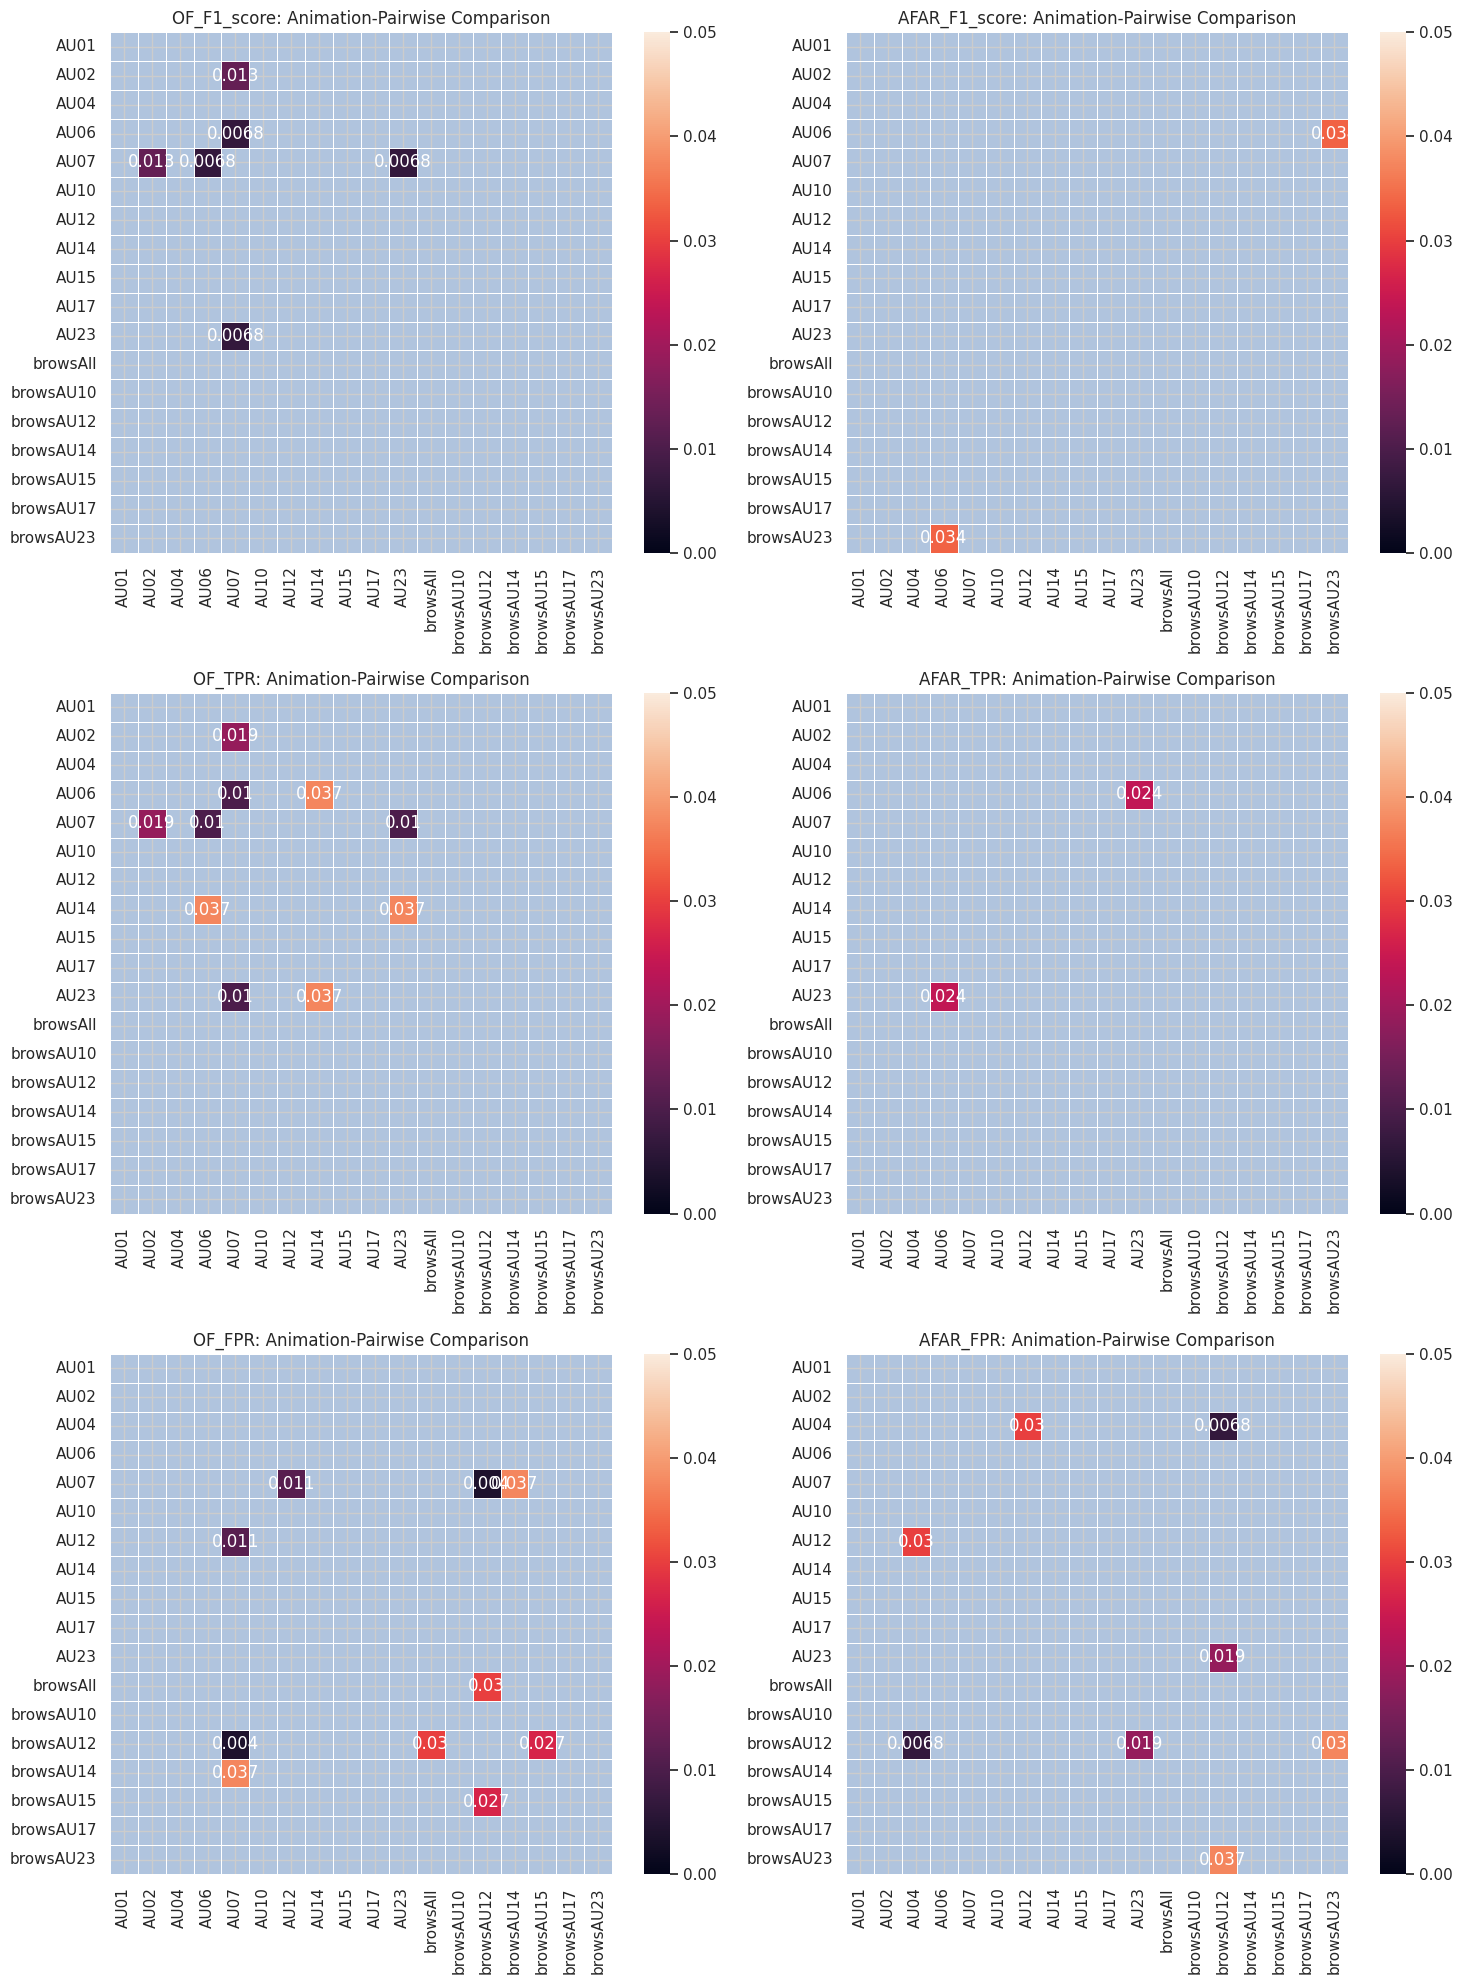

In [ ]:
# Running posthoc analysis for the significant results: Perform Nemenyi post-hoc test
DVs=["F1_score", 'TPR', 'FPR']
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
fig, axs = plt.subplots(len(DVs), 2, figsize=(15, 20))
for DV in range(len(DVs)):
  results_df = sp.posthoc_nemenyi_friedman(df[df['model'] == df['model'].unique()[0]], y_col=DVs[DV], block_col='avatar', group_col='animation', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[DV,0])
  axs[DV,0].set_title(f'OF_{DVs[DV]}: Animation-Pairwise Comparison')
  results_df = sp.posthoc_nemenyi_friedman(df[df['model'] == df['model'].unique()[1]], y_col=DVs[DV], block_col='avatar', group_col='animation', melted= True)
  sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5, ax=axs[DV,1])
  axs[DV,1].set_title(f'AFAR_{DVs[DV]}: Animation-Pairwise Comparison')

plt.tight_layout()
plt.show()

# Descriptive Interaction Plots

### OpenFace

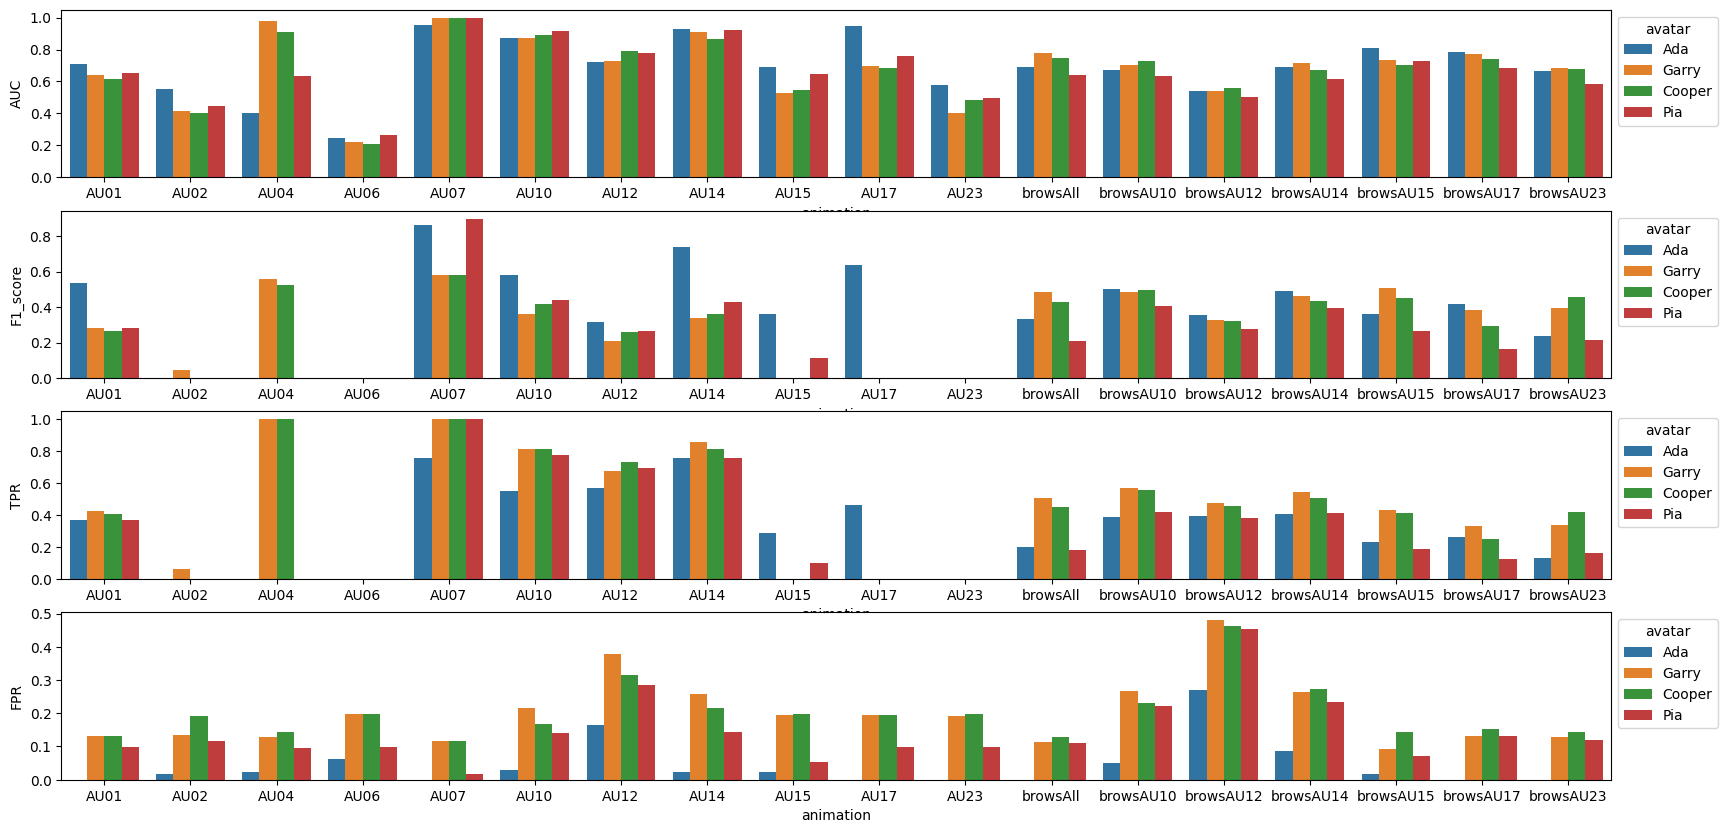

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  ax= sns.barplot(df_OF_all, x="animation", y=DVs[DV], hue="avatar", ax=axs[DV])
  sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

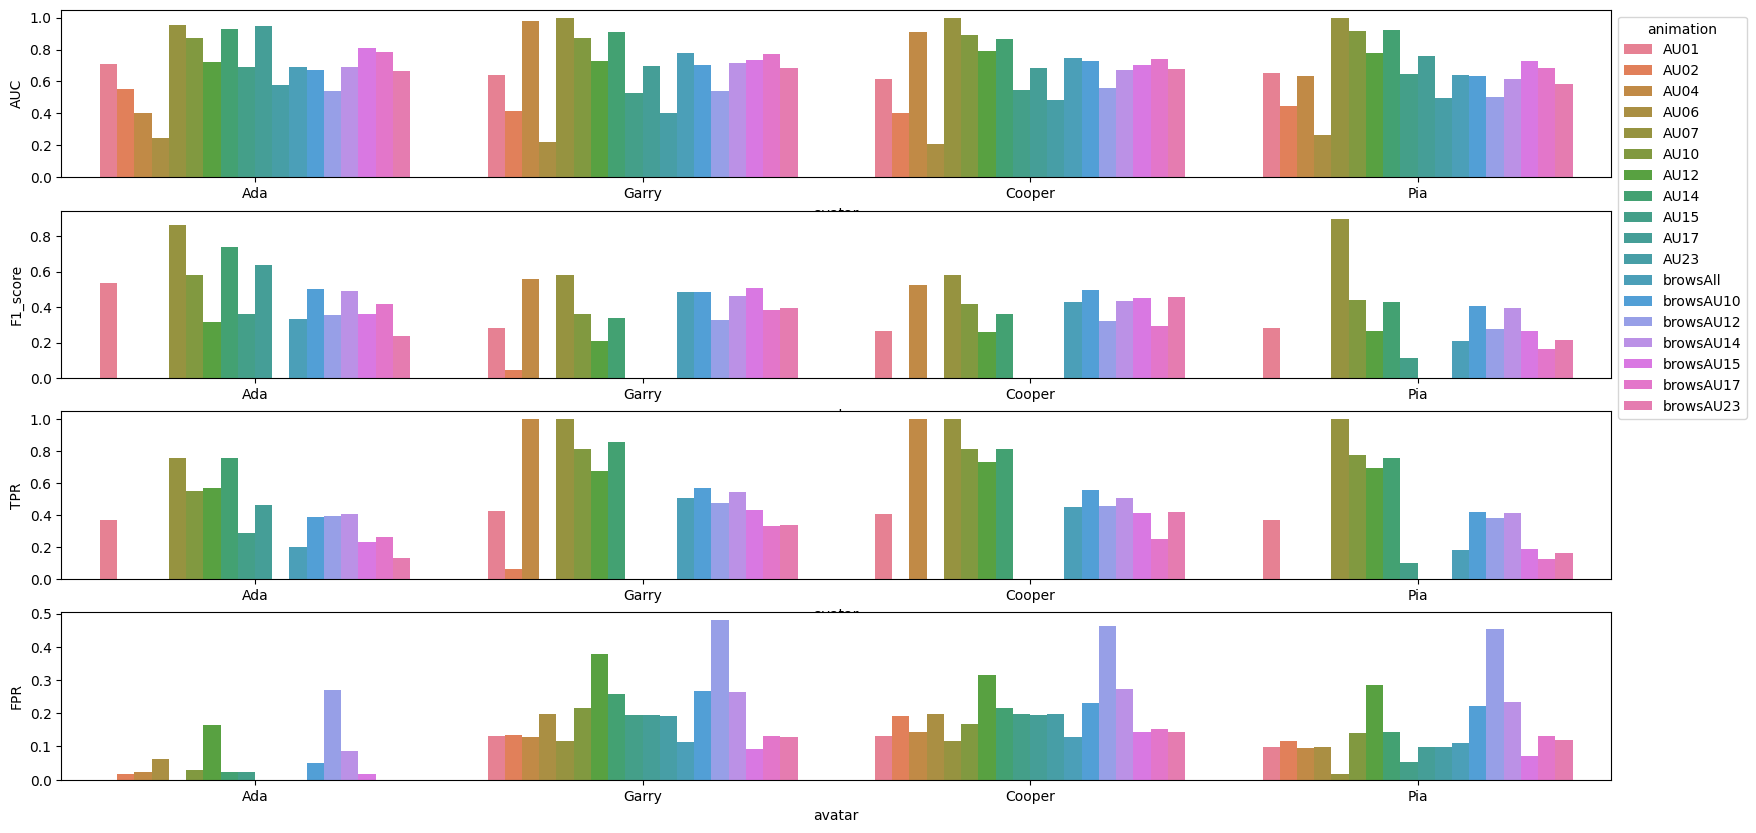

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  if DV == 0:
    ax = sns.barplot(df_OF_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
  else:
    sns.barplot(df_OF_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=None)

### AFAR

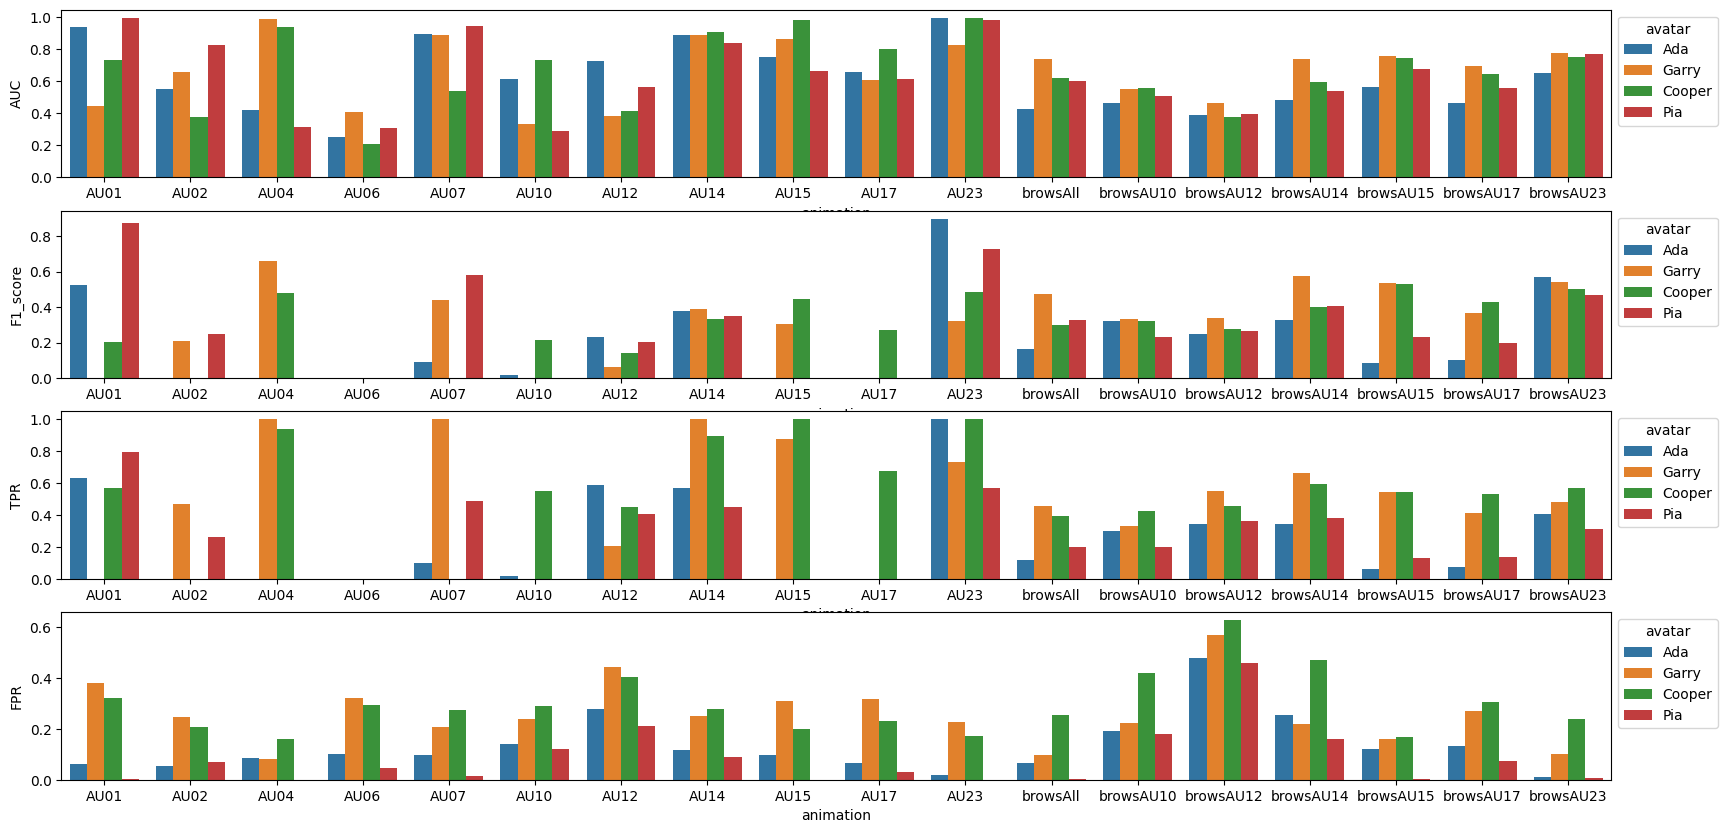

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  ax= sns.barplot(df_AFAR_all, x="animation", y=DVs[DV], hue="avatar", ax=axs[DV])
  sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

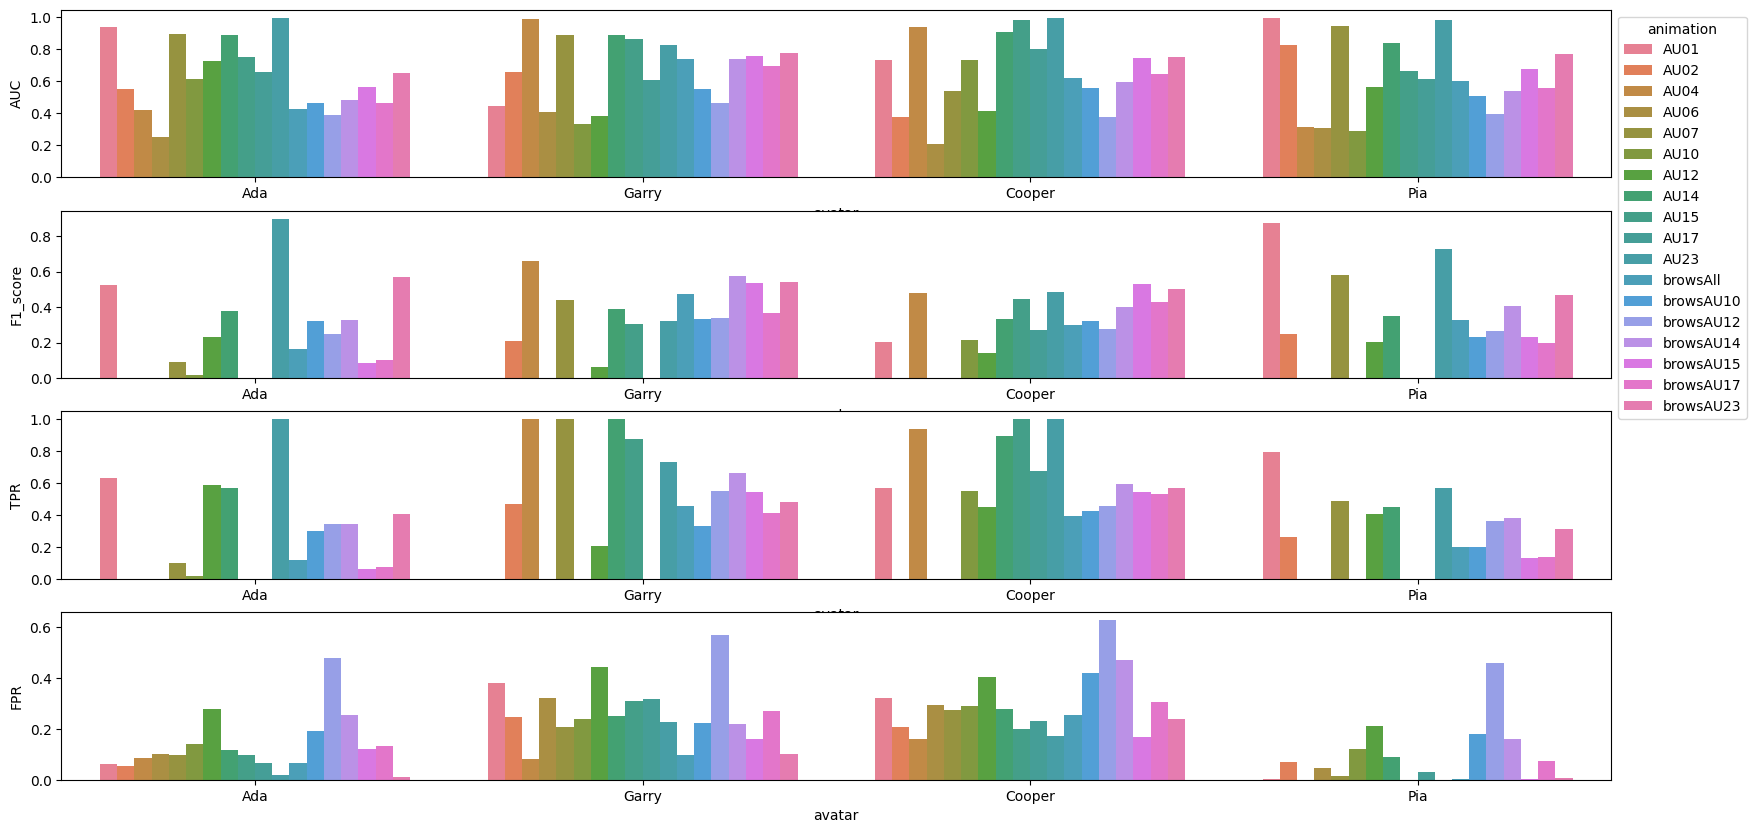

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  if DV == 0:
    ax = sns.barplot(df_AFAR_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
  else:
    sns.barplot(df_AFAR_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=None)

### PyFeat

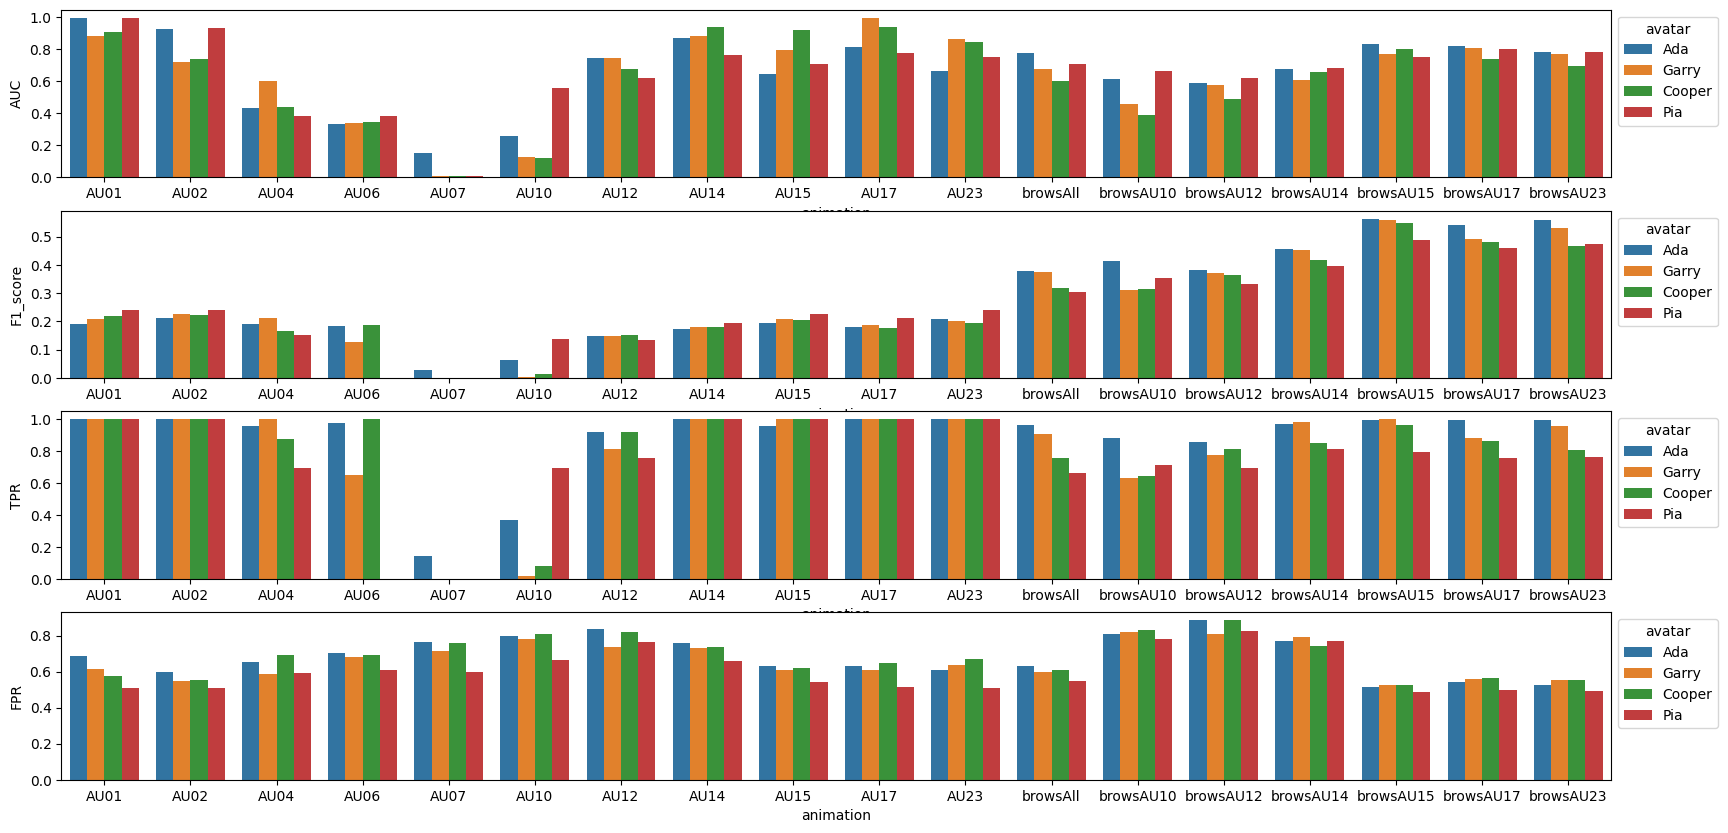

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  ax= sns.barplot(df_pyFEAT_all, x="animation", y=DVs[DV], hue="avatar", ax=axs[DV])
  sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

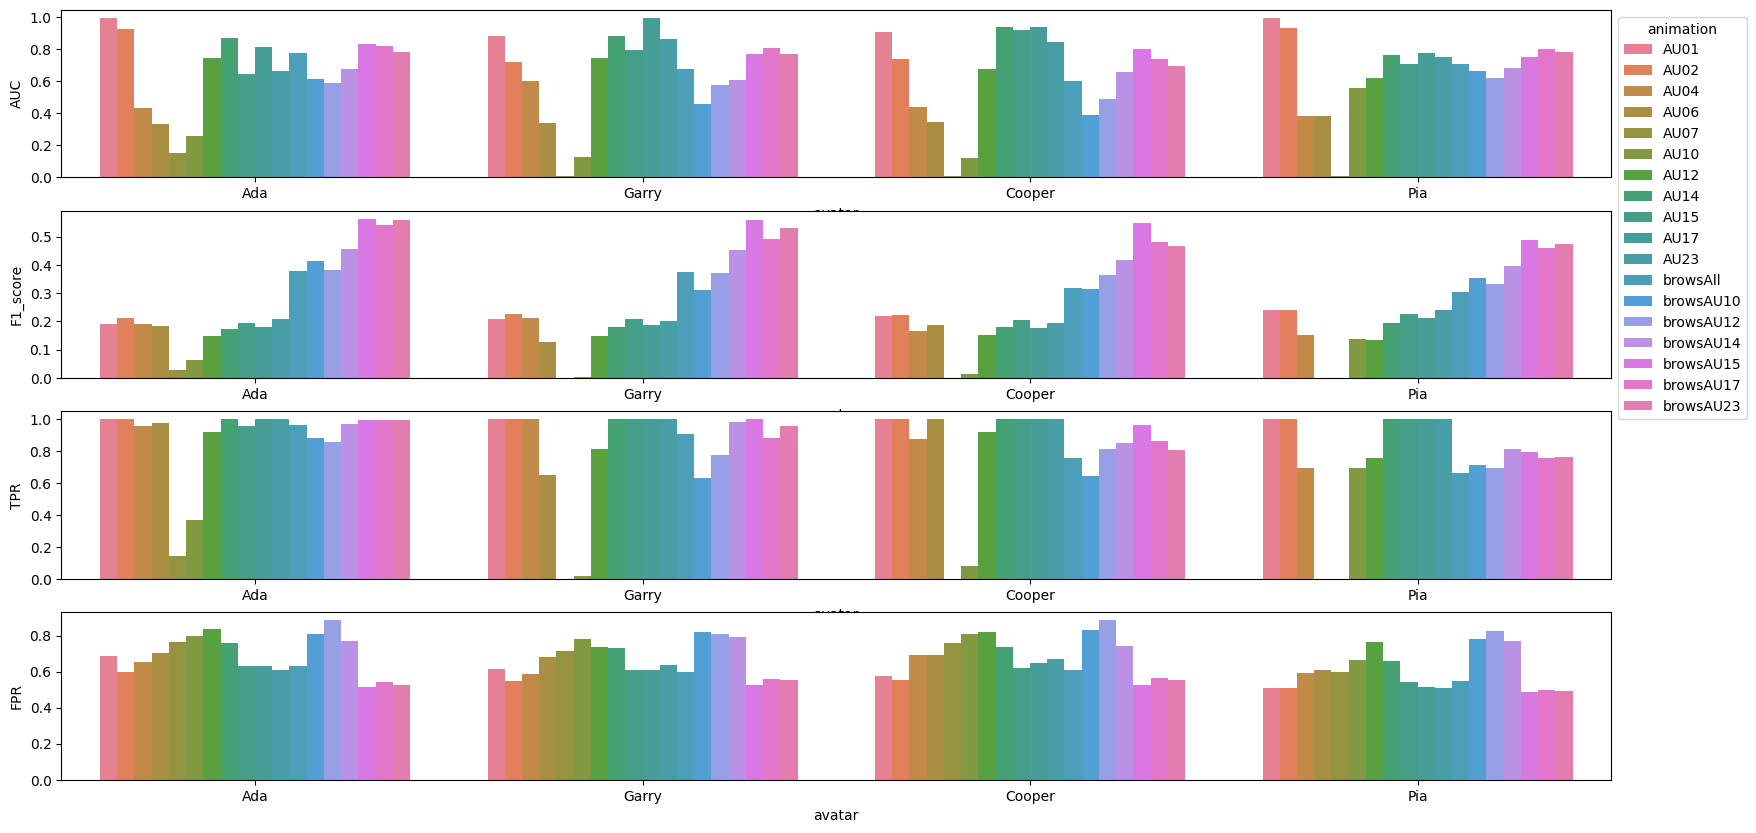

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=False, sharey=False, figsize=(20, 10))
for DV in range(len(DVs)):
  if DV == 0:
    ax = sns.barplot(df_pyFEAT_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
  else:
    sns.barplot(df_pyFEAT_all, x="avatar", y=DVs[DV], hue="animation", ax=axs[DV], legend=None)

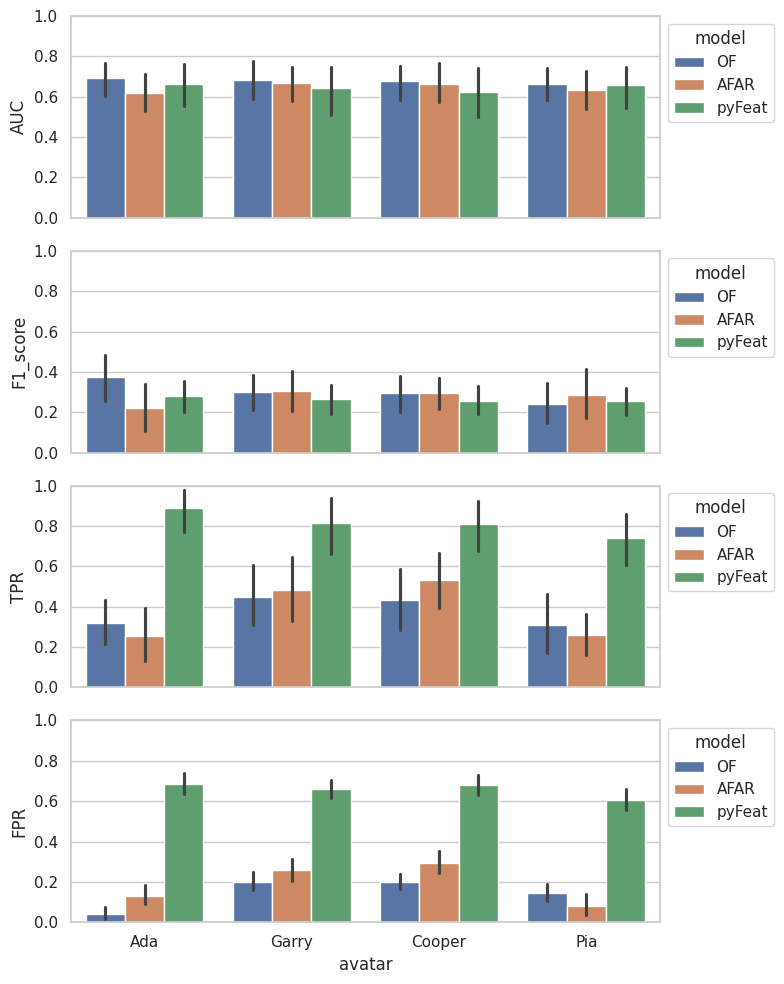

In [ ]:
DVs=['AUC','F1_score', 'TPR', 'FPR']
fig, axs = plt.subplots(len(DVs), 1, sharex=True, sharey=True, figsize=(8, 10))
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
sns.set_style("whitegrid")

for DV in range(len(DVs)):
  ax = sns.barplot(df_three, x="avatar", y=DVs[DV], hue='model', ax=axs[DV])
  axs[DV].set_ylim(0, 1)
  sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

# Cross-correlation Results

In [ ]:
crosscorr_long_df = pd.read_csv('cross_corr_bw_models_long.csv', delimiter=',', index_col=None)
crosscorr_long_df.head()

,Avatar,Animation,CrossCorr,Comparison
0,Ada,AU01,0.379,actual_OF
1,Ada,AU02,0.066,actual_OF
2,Ada,AU04,0.003,actual_OF
3,Ada,AU06,0.000,actual_OF
4,Ada,AU07,0.451,actual_OF


In [ ]:
crosscorr_long_df.groupby('Comparison').describe().applymap('{:,.2f}'.format)

<ipython-input-20-7cbbd1585b67>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df.groupby('Comparison').describe().applymap('{:,.2f}'.format)


CrossCorr                                           
                count  mean   std    min   25%   50%   75%   max
Comparison                                                      
OF_AFAR         72.00  0.23  0.19  -0.05  0.09  0.18  0.39  0.62
actual_AFAR     72.00  0.14  0.12  -0.01  0.02  0.16  0.20  0.55
actual_OF       72.00  0.24  0.16  -0.01  0.06  0.27  0.35  0.59

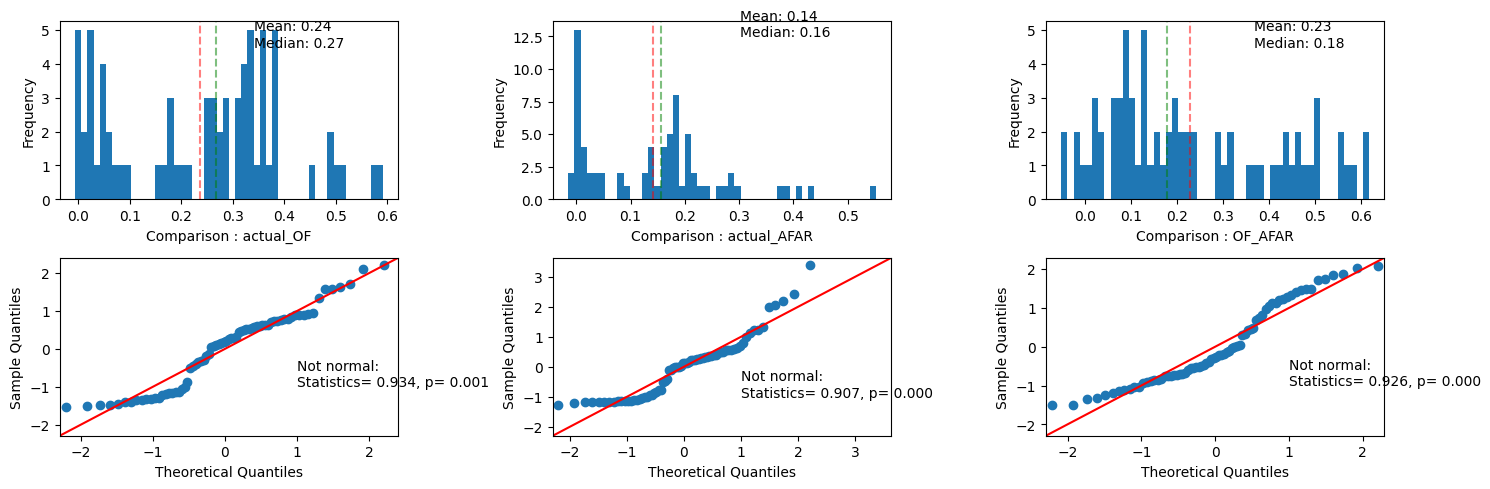

In [ ]:
comparisons = crosscorr_long_df['Comparison'].unique()
fig, axs = plt.subplots(2, len(comparisons), sharex=False, sharey=False, figsize=(15, 5))
DV='CrossCorr'
col=-1
for comp in comparisons:
  data_arr = []; hist_data = []; bins_data = [];
  data_arr = crosscorr_long_df[crosscorr_long_df['Comparison'] == comp][DV].to_numpy()
  hist_data, bins_data = np.histogram(data_arr, bins=50)
  col=col+1
  axs[0,col].hist(data_arr, bins=50)
  axs[0,col].set_xlabel(f"Comparison : {comp}")
  axs[0,col].set_ylabel('Frequency')
  axs[0,col].axvline(np.mean(data_arr), linestyle="dashed", color='red', alpha=0.5)
  axs[0,col].axvline(np.median(data_arr), linestyle="dashed", color='green', alpha=0.5)
  axs[0,col].annotate(f'Mean: {np.mean(data_arr):.2f}\nMedian: {np.median(data_arr):.2f}',
                xy=(max(bins_data) - 0.25, max(hist_data) - 0.5),
                xytext=(max(bins_data) - 0.25, max(hist_data) - 0.5))

  # Standardize the data
  std_arr = []
  for i in range(len(data_arr)):
      std_arr.append((data_arr[i]-np.mean(data_arr))/np.std(data_arr))

  sm.qqplot(np.array(std_arr), line ='45', ax=axs[1,col])
  stat, p = shapiro(data_arr)
  alpha = 0.05
  if p > alpha:
    axs[1,col].annotate(f'Normal distribution:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))
  else:
    axs[1,col].annotate(f'Not normal:\nStatistics= {stat:.3f}, p= {p:.3f}',
                xy=(1, -1),
                xytext=(1, -1))

plt.tight_layout()
plt.show()

## Significance difference bw actual vs OF and actual vs AFAR cross-correlations?

In [ ]:
comparisons = crosscorr_long_df['Comparison'].unique()
DV='CrossCorr'
col=-1
# Split data by avatar and model
scores_OF = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'actual_OF'][DV].values
scores_AFAR = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'actual_AFAR'][DV].values

# Perform Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(scores_OF, scores_AFAR)

# Print results
print(f"Mann-Whitney U test for {DV}:")
print("Statistic:", u_statistic)
print("p-value:", round(p_value,3))

Mann-Whitney U test for CrossCorr:
Statistic: 3591.5
p-value: 0.0


In [ ]:
comparisons = crosscorr_long_df['Comparison'].unique()
DV='CrossCorr'
col=-1
# Split data by avatar and model
scores_OF = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'actual_OF'][DV].values
scores_OF_AFAR = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'OF_AFAR'][DV].values

# Perform Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(scores_OF, scores_OF_AFAR)

# Print results
print(f"Mann-Whitney U test for {DV}:")
print("Statistic:", u_statistic)
print("p-value:", round(p_value,3))

Mann-Whitney U test for CrossCorr:
Statistic: 2696.0
p-value: 0.679


In [ ]:
comparisons = crosscorr_long_df['Comparison'].unique()
DV='CrossCorr'
col=-1
# Split data by avatar and model
scores_AFAR = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'actual_AFAR'][DV].values
scores_OF_AFAR = crosscorr_long_df[crosscorr_long_df['Comparison'] == 'OF_AFAR'][DV].values

# Perform Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(scores_AFAR, scores_OF_AFAR)

# Print results
print(f"Mann-Whitney U test for {DV}:")
print("Statistic:", u_statistic)
print("p-value:", round(p_value,3))

Mann-Whitney U test for CrossCorr:
Statistic: 1947.0
p-value: 0.01


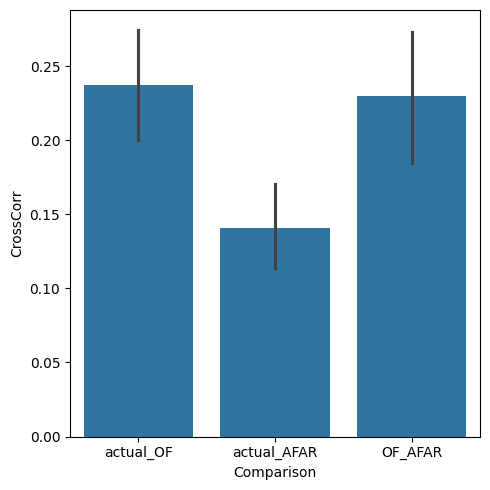

In [ ]:
plt.figure(figsize=(5,5))
gca = sns.barplot(crosscorr_long_df, x="Comparison", y='CrossCorr')
plt.tight_layout()
plt.show()


## Significant difference within cross-correlation scores?

In [ ]:
crosscorr_long_df.groupby('Avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-26-cc12ef3ad501>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df.groupby('Avatar').describe().applymap('{:,.2f}'.format)


CrossCorr                                           
           count  mean   std    min   25%   50%   75%   max
Avatar                                                     
Ada        54.00  0.19  0.18  -0.05  0.03  0.16  0.31  0.59
Cooper     54.00  0.15  0.10  -0.02  0.07  0.16  0.21  0.36
Garry      54.00  0.27  0.20  -0.01  0.08  0.27  0.44  0.62
Pia        54.00  0.20  0.15  -0.01  0.07  0.18  0.32  0.55

In [ ]:
f_model_all = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df.groupby('Avatar')])
print(f"Friedman's test for Avatars results:")
print("Statistic:", round(f_model_all.statistic,3))
print("p-value:", round(f_model_all.pvalue,3))

Friedman's test for Avatars results:
Statistic: 7.525
p-value: 0.057


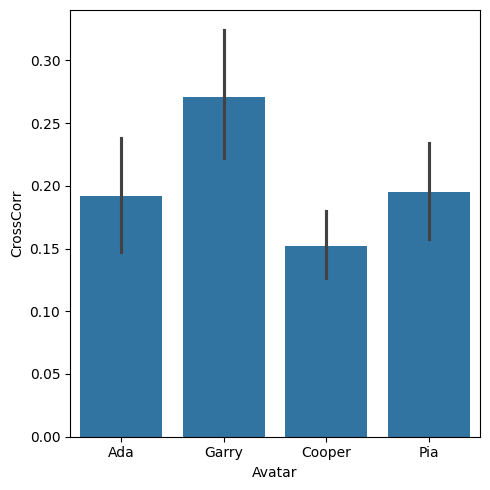

In [ ]:
plt.figure(figsize=(5,5))
gca = sns.barplot(crosscorr_long_df, x="Avatar", y='CrossCorr')
plt.tight_layout()
plt.show()

In [ ]:
f_model_all = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df.groupby('Animation')])
print(f"Friedman's test for animations results:")
print("Statistic:", round(f_model_all.statistic,3))
print("p-value:", round(f_model_all.pvalue,3))

Friedman's test for animations results:
Statistic: 99.035
p-value: 0.0


In [ ]:
crosscorr_long_df.groupby('Animation').describe().applymap('{:,.2f}'.format)

<ipython-input-30-29e30ac43a7b>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df.groupby('Animation').describe().applymap('{:,.2f}'.format)


CrossCorr                                            
              count  mean   std    min    25%   50%   75%   max
Animation                                                      
AU01          12.00  0.25  0.16   0.01   0.15  0.22  0.39  0.55
AU02          12.00  0.09  0.16  -0.05   0.02  0.04  0.08  0.55
AU04          12.00  0.09  0.14  -0.01   0.00  0.04  0.09  0.50
AU06          12.00  0.07  0.18  -0.01  -0.00  0.00  0.04  0.61
AU07          12.00  0.17  0.17   0.01   0.03  0.12  0.21  0.56
AU10          12.00  0.17  0.16  -0.00   0.03  0.14  0.28  0.49
AU12          12.00  0.20  0.10   0.02   0.16  0.23  0.26  0.36
AU14          12.00  0.20  0.13  -0.02   0.15  0.18  0.23  0.48
AU15          12.00  0.13  0.17  -0.00   0.04  0.10  0.17  0.62
AU17          12.00  0.10  0.18  -0.01   0.01  0.02  0.06  0.57
AU23          12.00  0.11  0.17  -0.05   0.02  0.05  0.10  0.58
browsAU10     12.00  0.28  0.14   0.14   0.17  0.20  0.37  0.51
browsAU12     12.00  0.27  0.08   0.16   0.20  0.25  0.33  0.39
browsAU14     12.00  0.28  0.12   0.13   0.18  0.28  0.32  0.49
browsAU15     12.00  0.27  0.12   0.09   0.18  0.30  0.34  0.49
browsAU17     12.00  0.30  0.13   0.14   0.20  0.32  0.38  0.57
browsAU23     12.00  0.32  0.12   0.17   0.20  0.31  0.41  0.51
browsAll      12.00  0.34  0.13   0.16   0.23  0.34  0.42  0.59

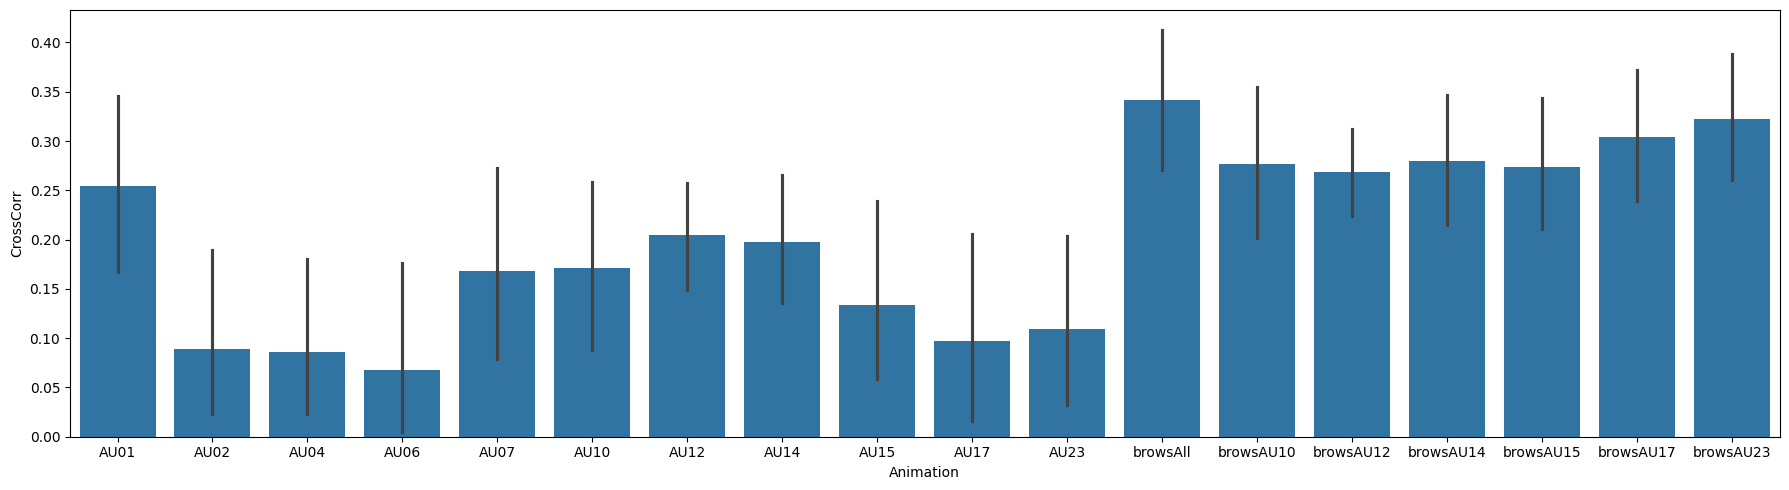

In [ ]:
plt.figure(figsize=(18,5))
gca = sns.barplot(crosscorr_long_df, x="Animation", y='CrossCorr')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results : Animation-Pairwise Comparison')

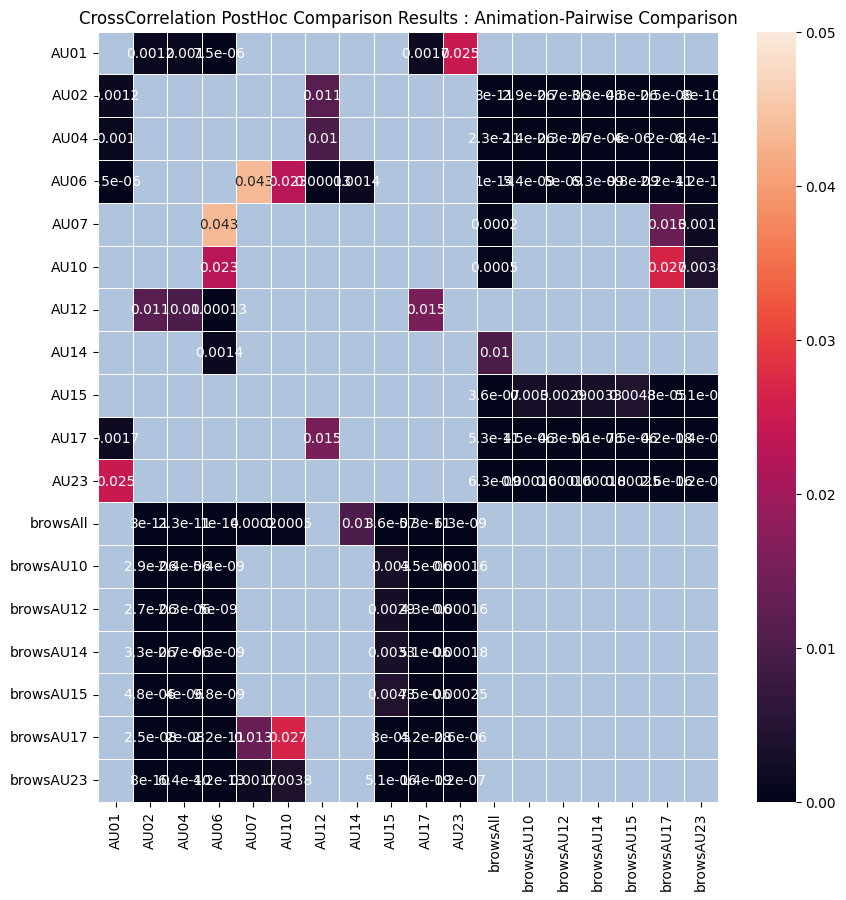

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(10,10))
results_df = sp.posthoc_nemenyi_friedman(crosscorr_long_df, y_col='CrossCorr', block_col='Avatar', group_col='Animation', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results : Animation-Pairwise Comparison")

### Within Model Comparisons: Avatar

In [ ]:
f_model_OF = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Avatar')])
print(f"Friedman's test for {crosscorr_long_df['Comparison'].unique()[0]} results:")
print("Statistic:", round(f_model_OF.statistic,3))
print("p-value:", round(f_model_OF.pvalue,3))

f_model_AFAR = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]].groupby('Avatar')])
print(f"Friedman's test for {crosscorr_long_df['Comparison'].unique()[1]} results:")
print("Statistic:", round(f_model_AFAR.statistic,3))
print("p-value:", round(f_model_AFAR.pvalue,3))

Friedman's test for actual_OF results:
Statistic: 25.2
p-value: 0.0
Friedman's test for actual_AFAR results:
Statistic: 8.051
p-value: 0.045


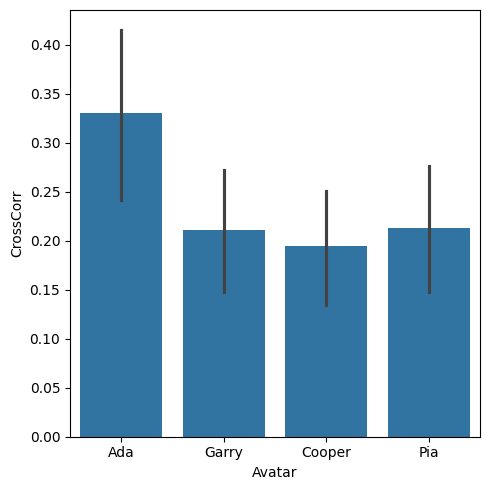

In [ ]:
plt.figure(figsize=(5,5))
gca = sns.barplot(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]], x="Avatar", y='CrossCorr')
plt.tight_layout()
plt.show()

In [ ]:
crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-35-b9a3fc8d369b>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Avatar').describe().applymap('{:,.2f}'.format)


CrossCorr                                           
           count  mean   std    min   25%   50%   75%   max
Avatar                                                     
Ada        18.00  0.33  0.20   0.00  0.21  0.37  0.49  0.59
Cooper     18.00  0.19  0.13  -0.00  0.05  0.23  0.31  0.36
Garry      18.00  0.21  0.14  -0.01  0.06  0.26  0.33  0.38
Pia        18.00  0.21  0.14   0.00  0.05  0.25  0.34  0.39

Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results for actual_OF: Avatar-Pairwise Comparison')

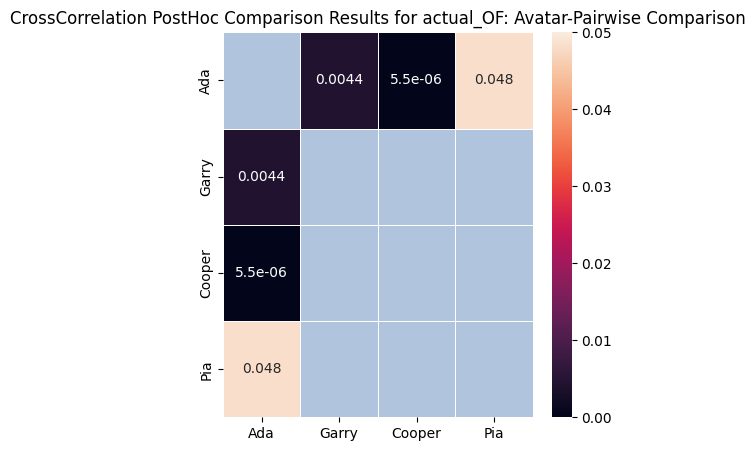

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(5,5))
results_df = sp.posthoc_nemenyi_friedman(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]], y_col='CrossCorr', block_col='Animation', group_col='Avatar', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results for {crosscorr_long_df['Comparison'].unique()[0]}: Avatar-Pairwise Comparison")

### Within Model Comparisons: Animation

In [ ]:
f_model_OF = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Animation')])
print(f"Friedman's test for {crosscorr_long_df['Comparison'].unique()[0]} results:")
print("Statistic:", round(f_model_OF.statistic,3))
print("p-value:", round(f_model_OF.pvalue,3))

f_model_AFAR = friedmanchisquare(*[group['CrossCorr'].values for name, group in crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]].groupby('Animation')])
print(f"Friedman's test for {crosscorr_long_df['Comparison'].unique()[1]} results:")
print("Statistic:", round(f_model_AFAR.statistic,3))
print("p-value:", round(f_model_AFAR.pvalue,3))

Friedman's test for actual_OF results:
Statistic: 62.415
p-value: 0.0
Friedman's test for actual_AFAR results:
Statistic: 44.463
p-value: 0.0


In [ ]:
crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Animation').describe().applymap('{:,.2f}'.format)

<ipython-input-37-86079635ebe5>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]].groupby('Animation').describe().applymap('{:,.2f}'.format)


CrossCorr                                              
              count   mean   std    min    25%    50%   75%   max
Animation                                                        
AU01           4.00   0.25  0.10   0.16   0.17   0.22  0.30  0.38
AU02           4.00   0.04  0.02   0.03   0.03   0.04  0.06  0.07
AU04           4.00   0.04  0.04   0.00   0.01   0.04  0.06  0.08
AU06           4.00  -0.00  0.00  -0.01  -0.00  -0.00  0.00  0.00
AU07           4.00   0.27  0.12   0.19   0.20   0.21  0.27  0.45
AU10           4.00   0.29  0.03   0.25   0.27   0.28  0.29  0.34
AU12           4.00   0.26  0.02   0.25   0.26   0.26  0.27  0.29
AU14           4.00   0.24  0.09   0.17   0.18   0.21  0.27  0.36
AU15           4.00   0.10  0.06   0.05   0.05   0.08  0.12  0.18
AU17           4.00   0.11  0.17   0.01   0.02   0.03  0.12  0.36
AU23           4.00   0.03  0.01   0.02   0.02   0.02  0.03  0.05
browsAU10      4.00   0.40  0.06   0.36   0.37   0.38  0.41  0.50
browsAU12      4.00   0.32  0.05   0.26   0.30   0.32  0.34  0.39
browsAU14      4.00   0.36  0.08   0.31   0.32   0.33  0.38  0.49
browsAU15      4.00   0.37  0.08   0.31   0.33   0.34  0.39  0.49
browsAU17      4.00   0.40  0.12   0.33   0.33   0.36  0.43  0.57
browsAU23      4.00   0.38  0.10   0.28   0.32   0.36  0.42  0.51
browsAll       4.00   0.41  0.12   0.33   0.35   0.36  0.42  0.59

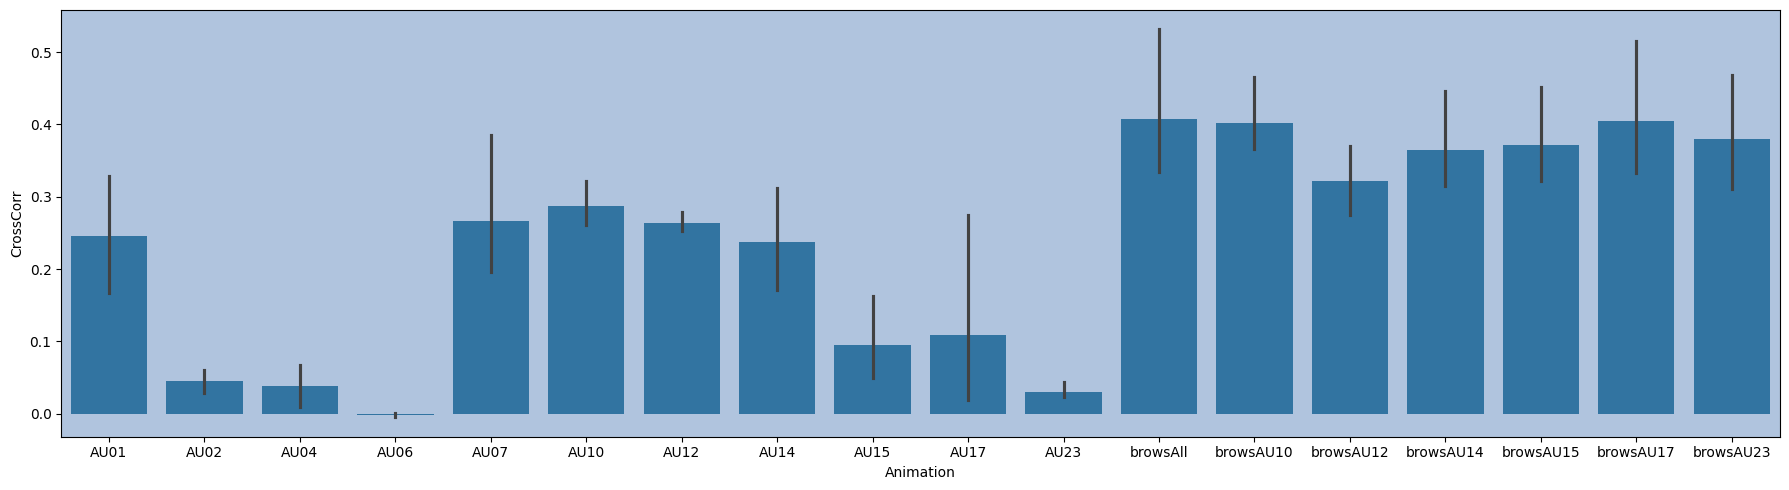

In [ ]:
plt.figure(figsize=(18,5))
gca = sns.barplot(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]], x="Animation", y='CrossCorr')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results for actual_OF: Animation-Pairwise Comparison')

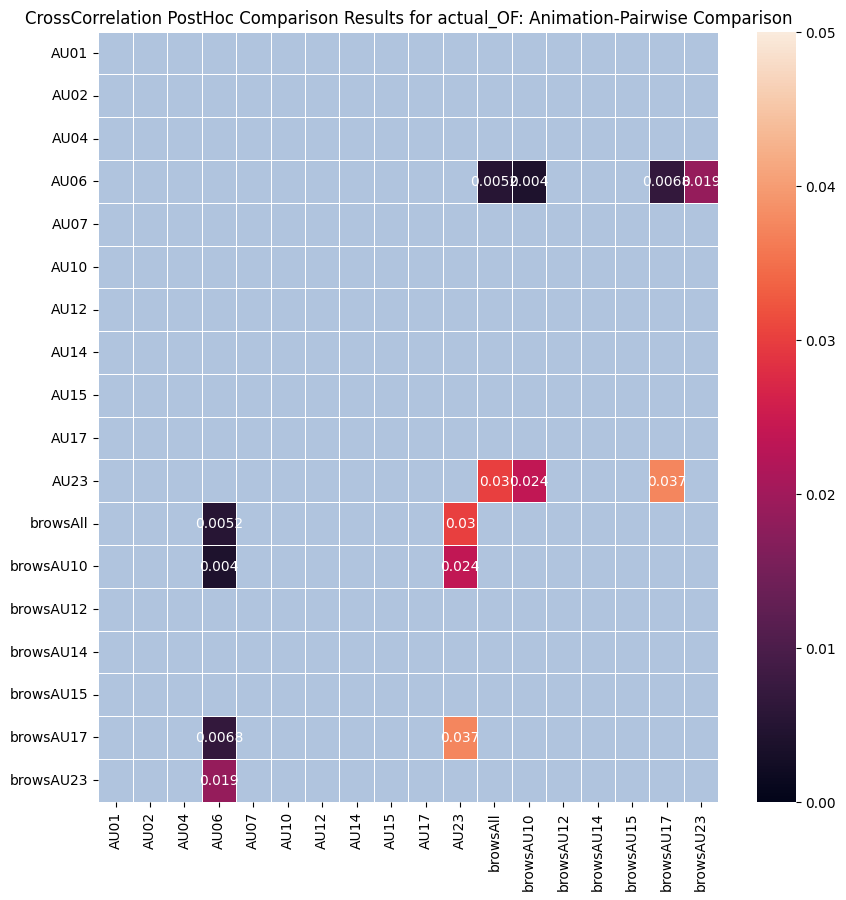

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(10,10))
results_df = sp.posthoc_nemenyi_friedman(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[0]], y_col='CrossCorr', block_col='Avatar', group_col='Animation', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results for {crosscorr_long_df['Comparison'].unique()[0]}: Animation-Pairwise Comparison")

In [ ]:
crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]].groupby('Animation').describe().applymap('{:,.2f}'.format)

<ipython-input-11-1b436021ddf2>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]].groupby('Animation').describe().applymap('{:,.2f}'.format)


CrossCorr                                              
              count   mean   std    min    25%    50%   75%   max
Animation                                                        
AU01           4.00   0.28  0.24   0.01   0.13   0.29  0.44  0.55
AU02           4.00   0.07  0.09   0.00   0.00   0.04  0.11  0.18
AU04           4.00   0.03  0.07  -0.01  -0.00   0.00  0.04  0.14
AU06           4.00  -0.00  0.00  -0.01  -0.00  -0.00  0.00  0.00
AU07           4.00   0.05  0.06   0.01   0.02   0.03  0.06  0.14
AU10           4.00   0.05  0.07  -0.00   0.00   0.01  0.06  0.16
AU12           4.00   0.13  0.10   0.02   0.07   0.14  0.21  0.22
AU14           4.00   0.19  0.02   0.17   0.18   0.19  0.20  0.23
AU15           4.00   0.09  0.09   0.01   0.02   0.09  0.17  0.18
AU17           4.00   0.01  0.02   0.00   0.00   0.00  0.02  0.05
AU23           4.00   0.13  0.12   0.04   0.05   0.09  0.17  0.30
browsAU10      4.00   0.17  0.03   0.14   0.15   0.17  0.19  0.20
browsAU12      4.00   0.18  0.02   0.16   0.17   0.18  0.19  0.20
browsAU14      4.00   0.24  0.08   0.13   0.23   0.27  0.28  0.29
browsAU15      4.00   0.19  0.08   0.09   0.16   0.20  0.23  0.29
browsAU17      4.00   0.21  0.11   0.14   0.14   0.16  0.23  0.38
browsAU23      4.00   0.24  0.10   0.17   0.18   0.20  0.25  0.39
browsAll       4.00   0.26  0.12   0.16   0.20   0.22  0.29  0.43

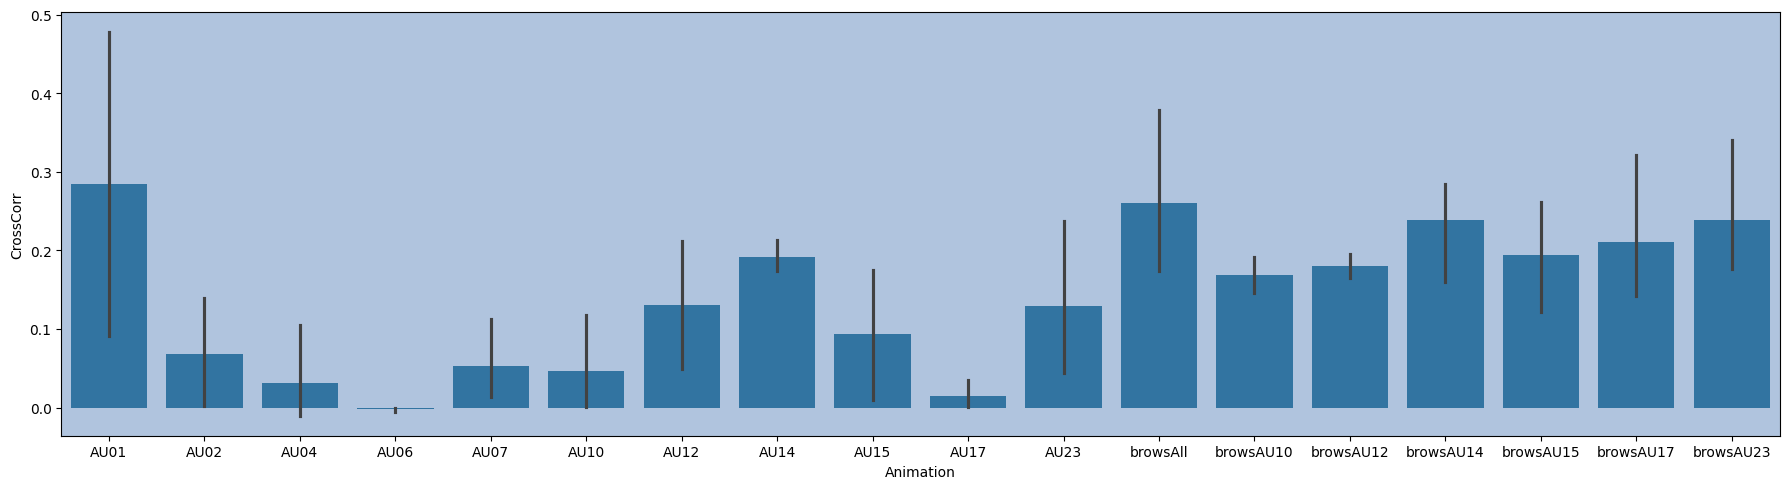

In [ ]:
plt.figure(figsize=(18,5))
gca = sns.barplot(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]], x="Animation", y='CrossCorr')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results for actual_OF: Animation-Pairwise Comparison')

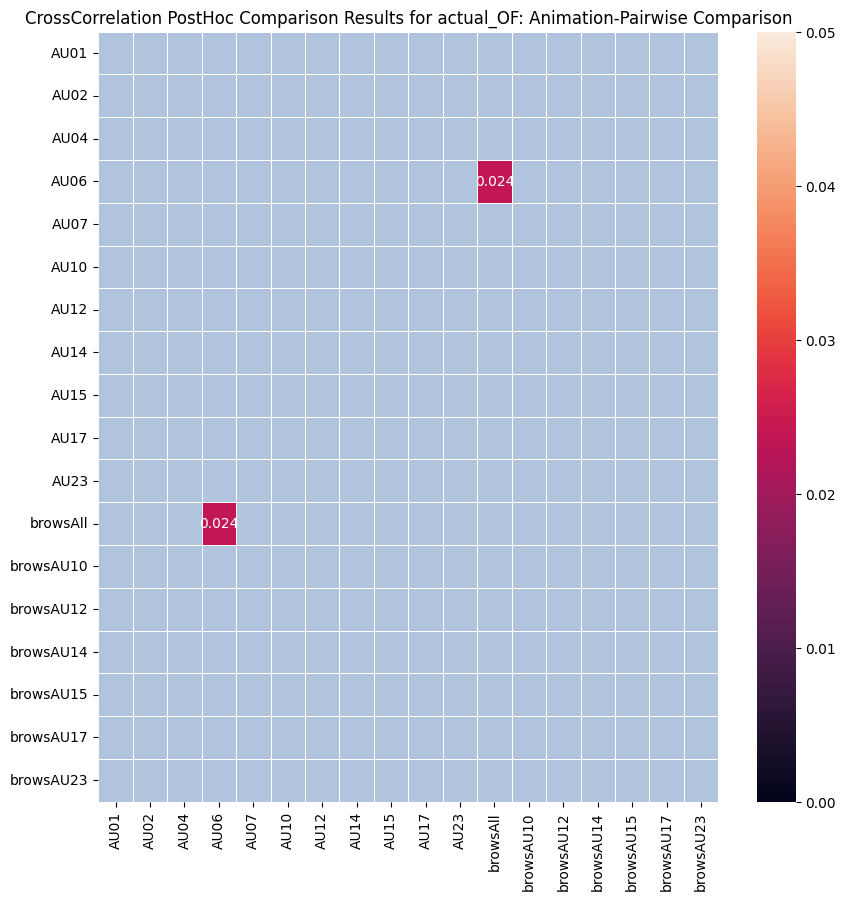

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(10,10))
results_df = sp.posthoc_nemenyi_friedman(crosscorr_long_df[crosscorr_long_df['Comparison'] == crosscorr_long_df['Comparison'].unique()[1]], y_col='CrossCorr', block_col='Avatar', group_col='Animation', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results for {crosscorr_long_df['Comparison'].unique()[0]}: Animation-Pairwise Comparison")

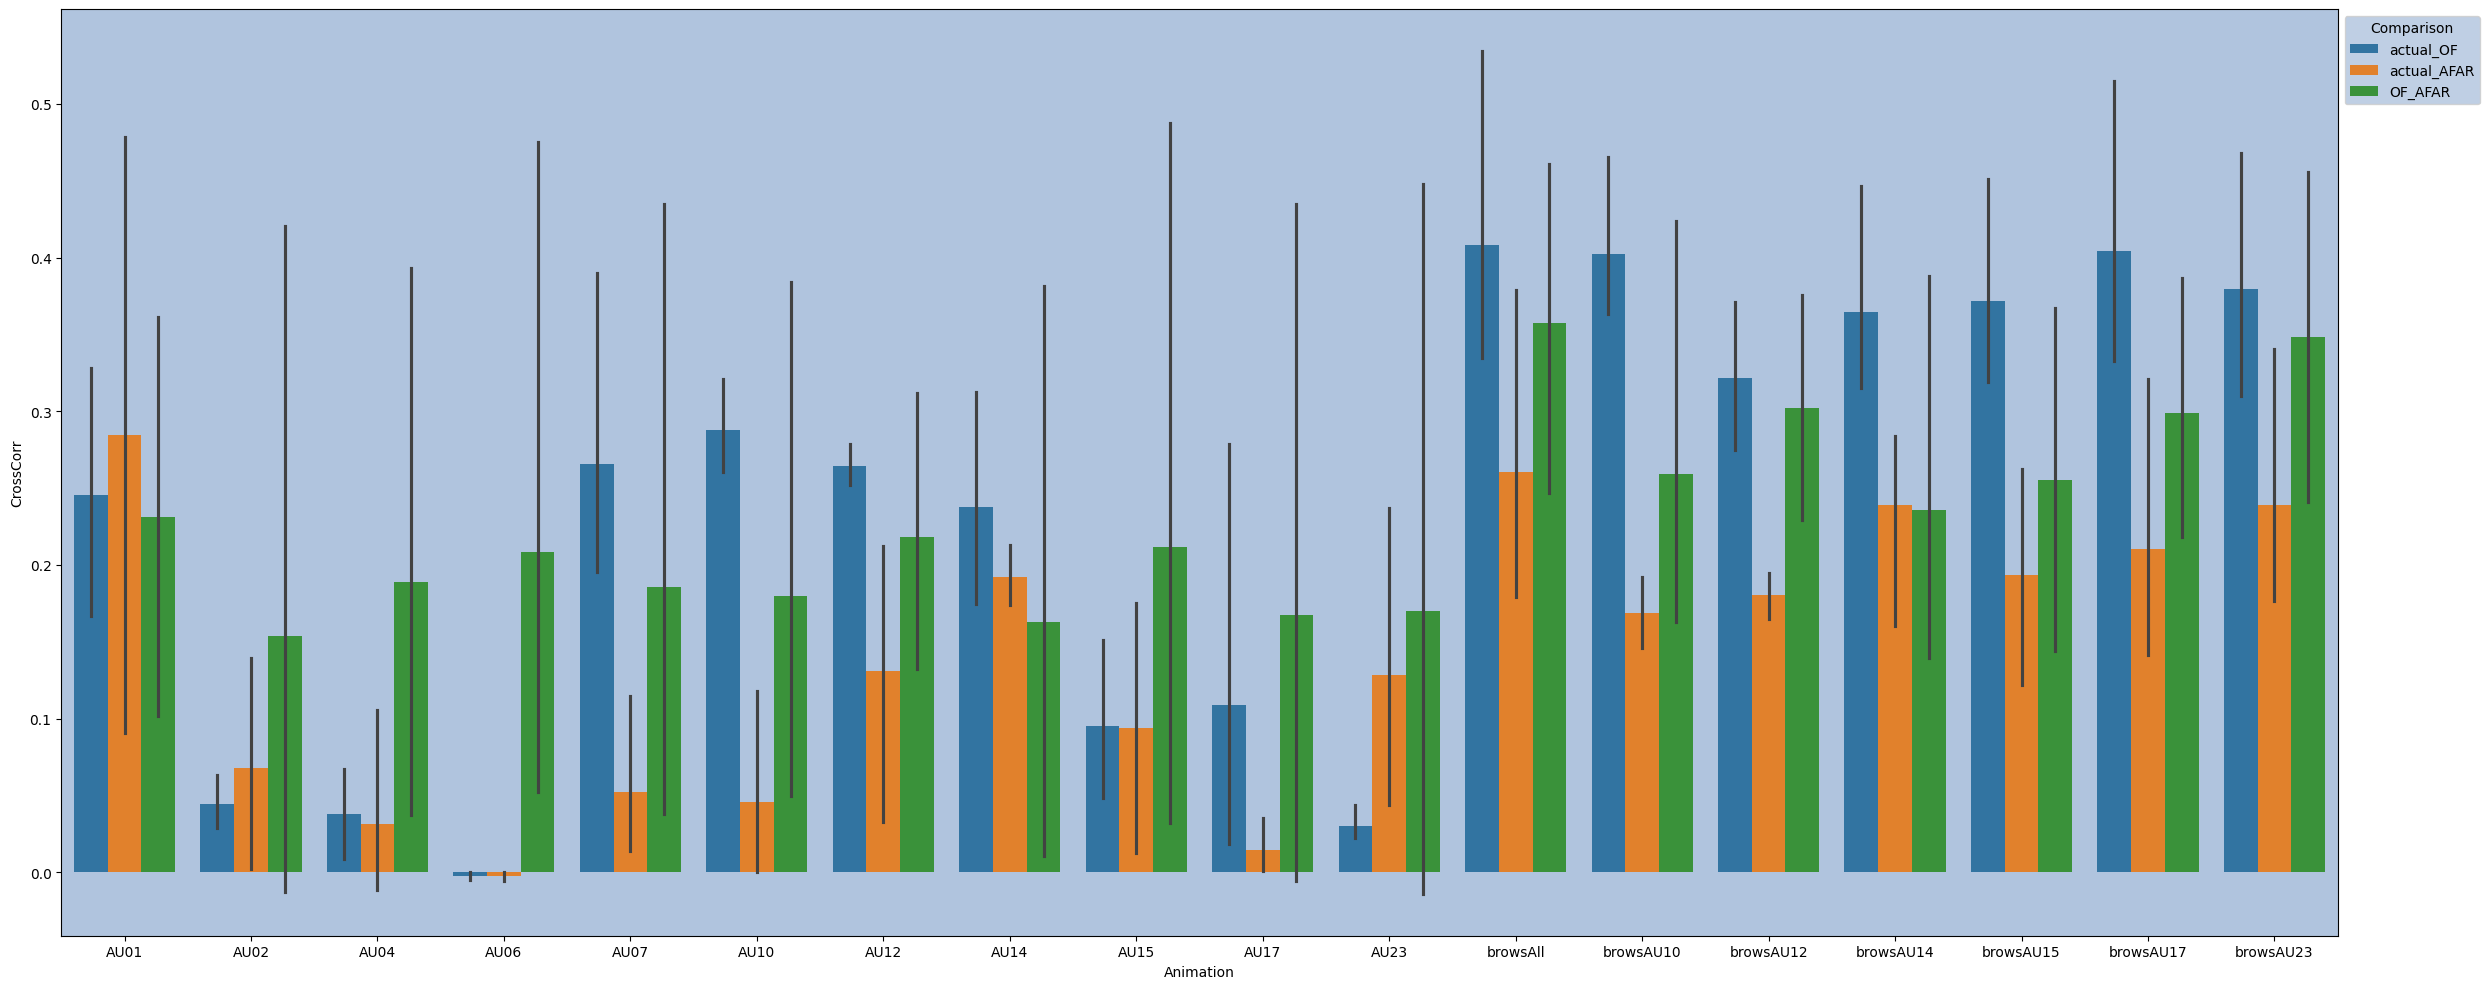

In [ ]:
plt.figure(figsize=(25,10))
gca = sns.barplot(crosscorr_long_df, x="Animation", y='CrossCorr', hue='Comparison', legend=True)
sns.move_legend(gca, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

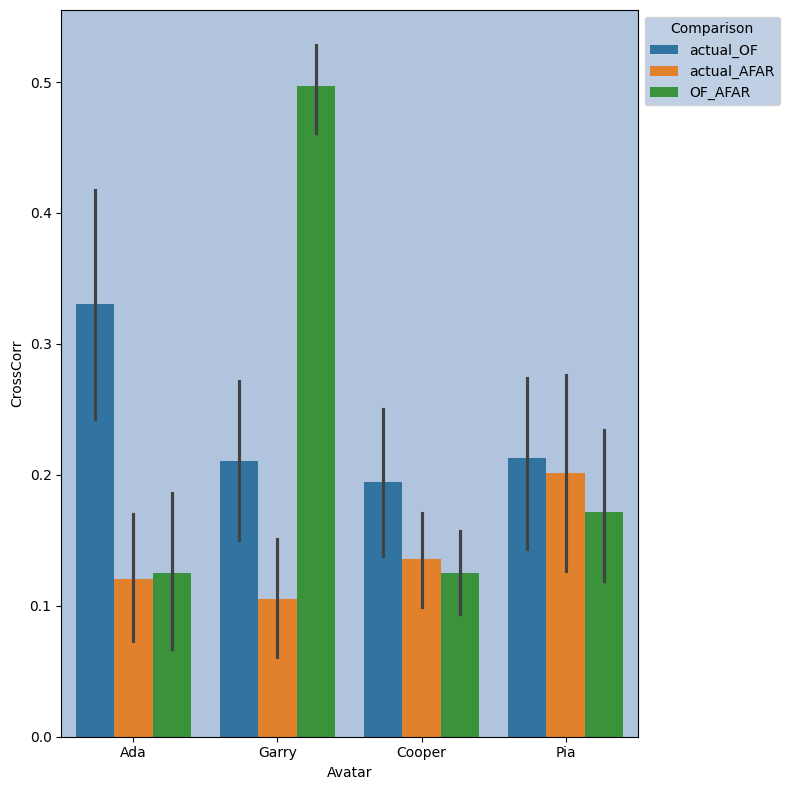

In [ ]:
plt.figure(figsize=(8,8))
gca = sns.barplot(crosscorr_long_df, x="Avatar", y='CrossCorr', hue='Comparison', legend=True)
sns.move_legend(gca, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Landmark Displacement Analysis: Correlation Coefficient of mean_scaled data

In [ ]:
landm_corrcoef_long_df = pd.read_csv('long_df_mean_scaled_corr_coef.csv', delimiter=',', index_col=None)
landm_corrcoef_long_df.head()

,Animation,Comparisons,CorrCoef_Score
0,AU01,Ada_vs_Garry,0.9513
1,AU02,Ada_vs_Garry,0.9415
2,AU04,Ada_vs_Garry,0.8503
3,AU06,Ada_vs_Garry,0.7106
4,AU07,Ada_vs_Garry,0.3736


In [ ]:
landm_corrcoef_long_df.describe()

,CorrCoef_Score
count,108.000000
mean,0.868254
std,0.133958
min,0.228200
25%,0.833900
50%,0.911600
75%,0.955575
max,0.989700


### Any significant difference bw comparisons?

In [ ]:
landm_corrcoef_long_df.groupby('Comparisons').describe().applymap('{:,.2f}'.format)

<ipython-input-13-54ab7b132722>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  landm_corrcoef_long_df.groupby('Comparisons').describe().applymap('{:,.2f}'.format)


CorrCoef_Score                                          
                         count  mean   std   min   25%   50%   75%   max
Comparisons                                                             
Ada_vs_Cooper            18.00  0.88  0.18  0.23  0.88  0.93  0.96  0.99
Ada_vs_Garry             18.00  0.81  0.16  0.37  0.77  0.85  0.94  0.98
Ada_vs_Pia               18.00  0.90  0.11  0.51  0.90  0.93  0.96  0.99
Cooper_vs_Pia            18.00  0.91  0.07  0.74  0.88  0.92  0.96  0.99
Garry_vs_Cooper          18.00  0.88  0.11  0.67  0.81  0.93  0.96  0.99
Garry_vs_Pia             18.00  0.83  0.14  0.47  0.81  0.85  0.93  0.98

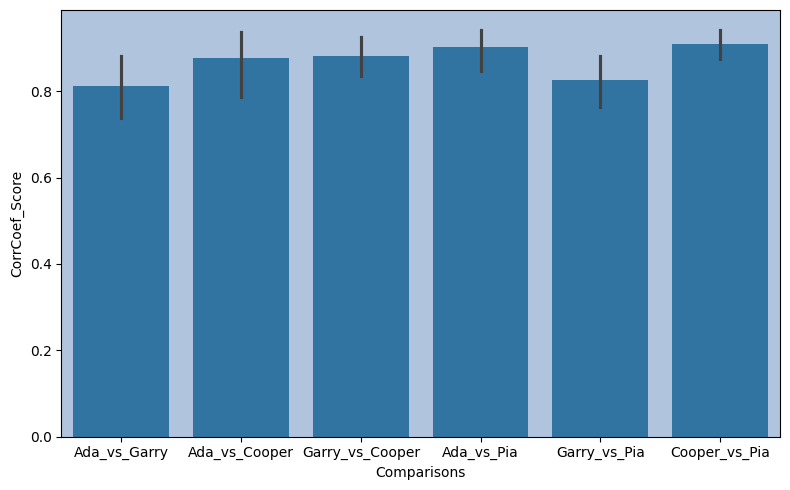

In [ ]:
plt.figure(figsize=(8,5))
gca = sns.barplot(landm_corrcoef_long_df, x="Comparisons", y='CorrCoef_Score')
plt.tight_layout()
plt.show()

In [ ]:
data_arr = landm_corrcoef_long_df['CorrCoef_Score'].to_numpy()

# Standardize the data
std_arr = []
for i in range(len(data_arr)):
    std_arr.append((data_arr[i]-np.mean(data_arr))/np.std(data_arr))

stat, p = shapiro(data_arr)
alpha = 0.05
if p > alpha:
  print(f'Normal distribution:\nStatistics= {stat:.3f}, p= {p:.3f}')
else:
  print(f'Not normal:\nStatistics= {stat:.3f}, p= {p:.3f}')

Not normal:
Statistics= 0.766, p= 0.000


In [ ]:
f_model = friedmanchisquare(*[group['CorrCoef_Score'].values for name, group in landm_corrcoef_long_df.groupby('Comparisons')])
print(f"Friedman's test for comparison results:")
print("Statistic:", round(f_model.statistic,3))
print("p-value:", round(f_model.pvalue,3))

Friedman's test for comparison results:
Statistic: 43.556
p-value: 0.0


Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results for Comparisons')

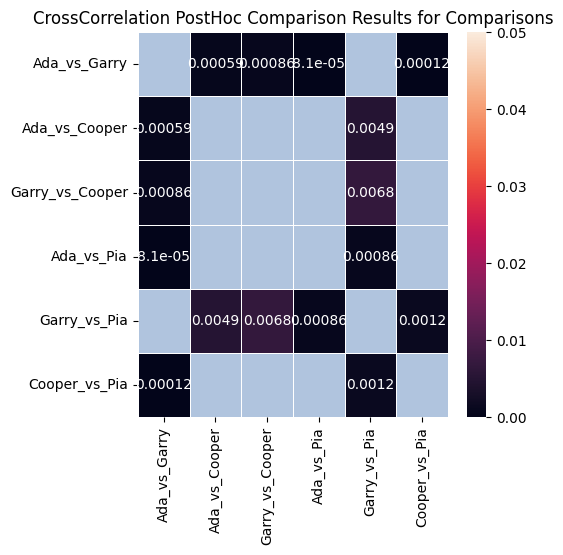

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(5,5))
results_df = sp.posthoc_nemenyi_friedman(landm_corrcoef_long_df, y_col='CorrCoef_Score', block_col='Animation', group_col='Comparisons', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results for Comparisons")

### Any significant difference wn comparisons across animations?

In [ ]:
landm_corrcoef_long_df.groupby('Animation').describe().applymap('{:,.2f}'.format)

<ipython-input-11-ca759e82a539>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  landm_corrcoef_long_df.groupby('Animation').describe().applymap('{:,.2f}'.format)


CorrCoef_Score                                          
                   count  mean   std   min   25%   50%   75%   max
Animation                                                         
AU01                6.00  0.96  0.01  0.94  0.95  0.97  0.97  0.98
AU02                6.00  0.97  0.02  0.94  0.96  0.97  0.98  0.99
AU04                6.00  0.89  0.06  0.80  0.85  0.90  0.94  0.96
AU06                6.00  0.72  0.08  0.58  0.72  0.74  0.74  0.83
AU07                6.00  0.56  0.23  0.23  0.41  0.63  0.75  0.78
AU10                6.00  0.95  0.01  0.94  0.94  0.96  0.96  0.97
AU12                6.00  0.98  0.01  0.97  0.98  0.99  0.99  0.99
AU14                6.00  0.95  0.03  0.89  0.95  0.95  0.96  0.98
AU15                6.00  0.85  0.04  0.78  0.81  0.86  0.88  0.89
AU17                6.00  0.72  0.19  0.47  0.58  0.76  0.88  0.90
AU23                6.00  0.80  0.06  0.71  0.77  0.80  0.84  0.87
browsAU10           6.00  0.98  0.01  0.96  0.97  0.98  0.98  0.98
browsAU12           6.00  0.92  0.04  0.86  0.90  0.94  0.95  0.95
browsAU14           6.00  0.89  0.04  0.83  0.86  0.89  0.91  0.95
browsAU15           6.00  0.79  0.14  0.59  0.69  0.85  0.89  0.90
browsAU17           6.00  0.88  0.04  0.82  0.84  0.90  0.91  0.91
browsAU23           6.00  0.90  0.04  0.84  0.86  0.92  0.93  0.94
browsAll            6.00  0.91  0.04  0.85  0.89  0.93  0.95  0.95

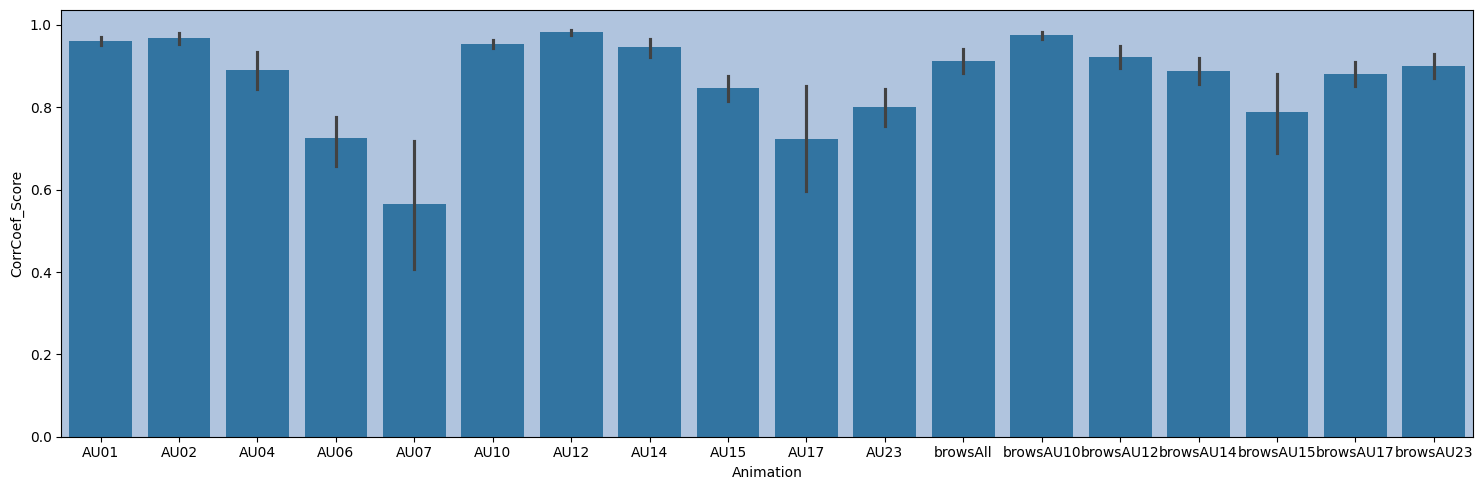

In [ ]:
plt.figure(figsize=(15,5))
gca = sns.barplot(landm_corrcoef_long_df, x="Animation", y='CorrCoef_Score')
plt.tight_layout()
plt.show()

In [ ]:
f_model = friedmanchisquare(*[group['CorrCoef_Score'].values for name, group in landm_corrcoef_long_df.groupby('Animation')])
print(f"Friedman's test for comparison results:")
print("Statistic:", round(f_model.statistic,3))
print("p-value:", round(f_model.pvalue,3))

Friedman's test for comparison results:
Statistic: 94.409
p-value: 0.0


Text(0.5, 1.0, 'CrossCorrelation PostHoc Comparison Results for Comparisons')

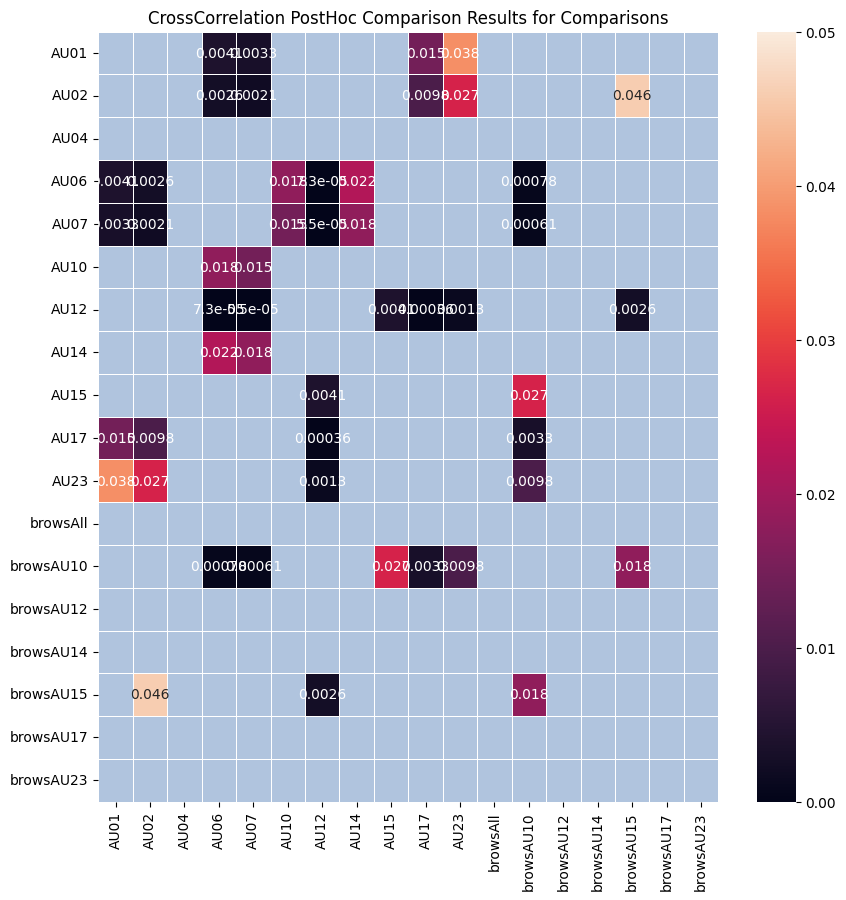

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(10,10))
results_df = sp.posthoc_nemenyi_friedman(landm_corrcoef_long_df, y_col='CorrCoef_Score', block_col='Comparisons', group_col='Animation', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"CrossCorrelation PostHoc Comparison Results for Comparisons")

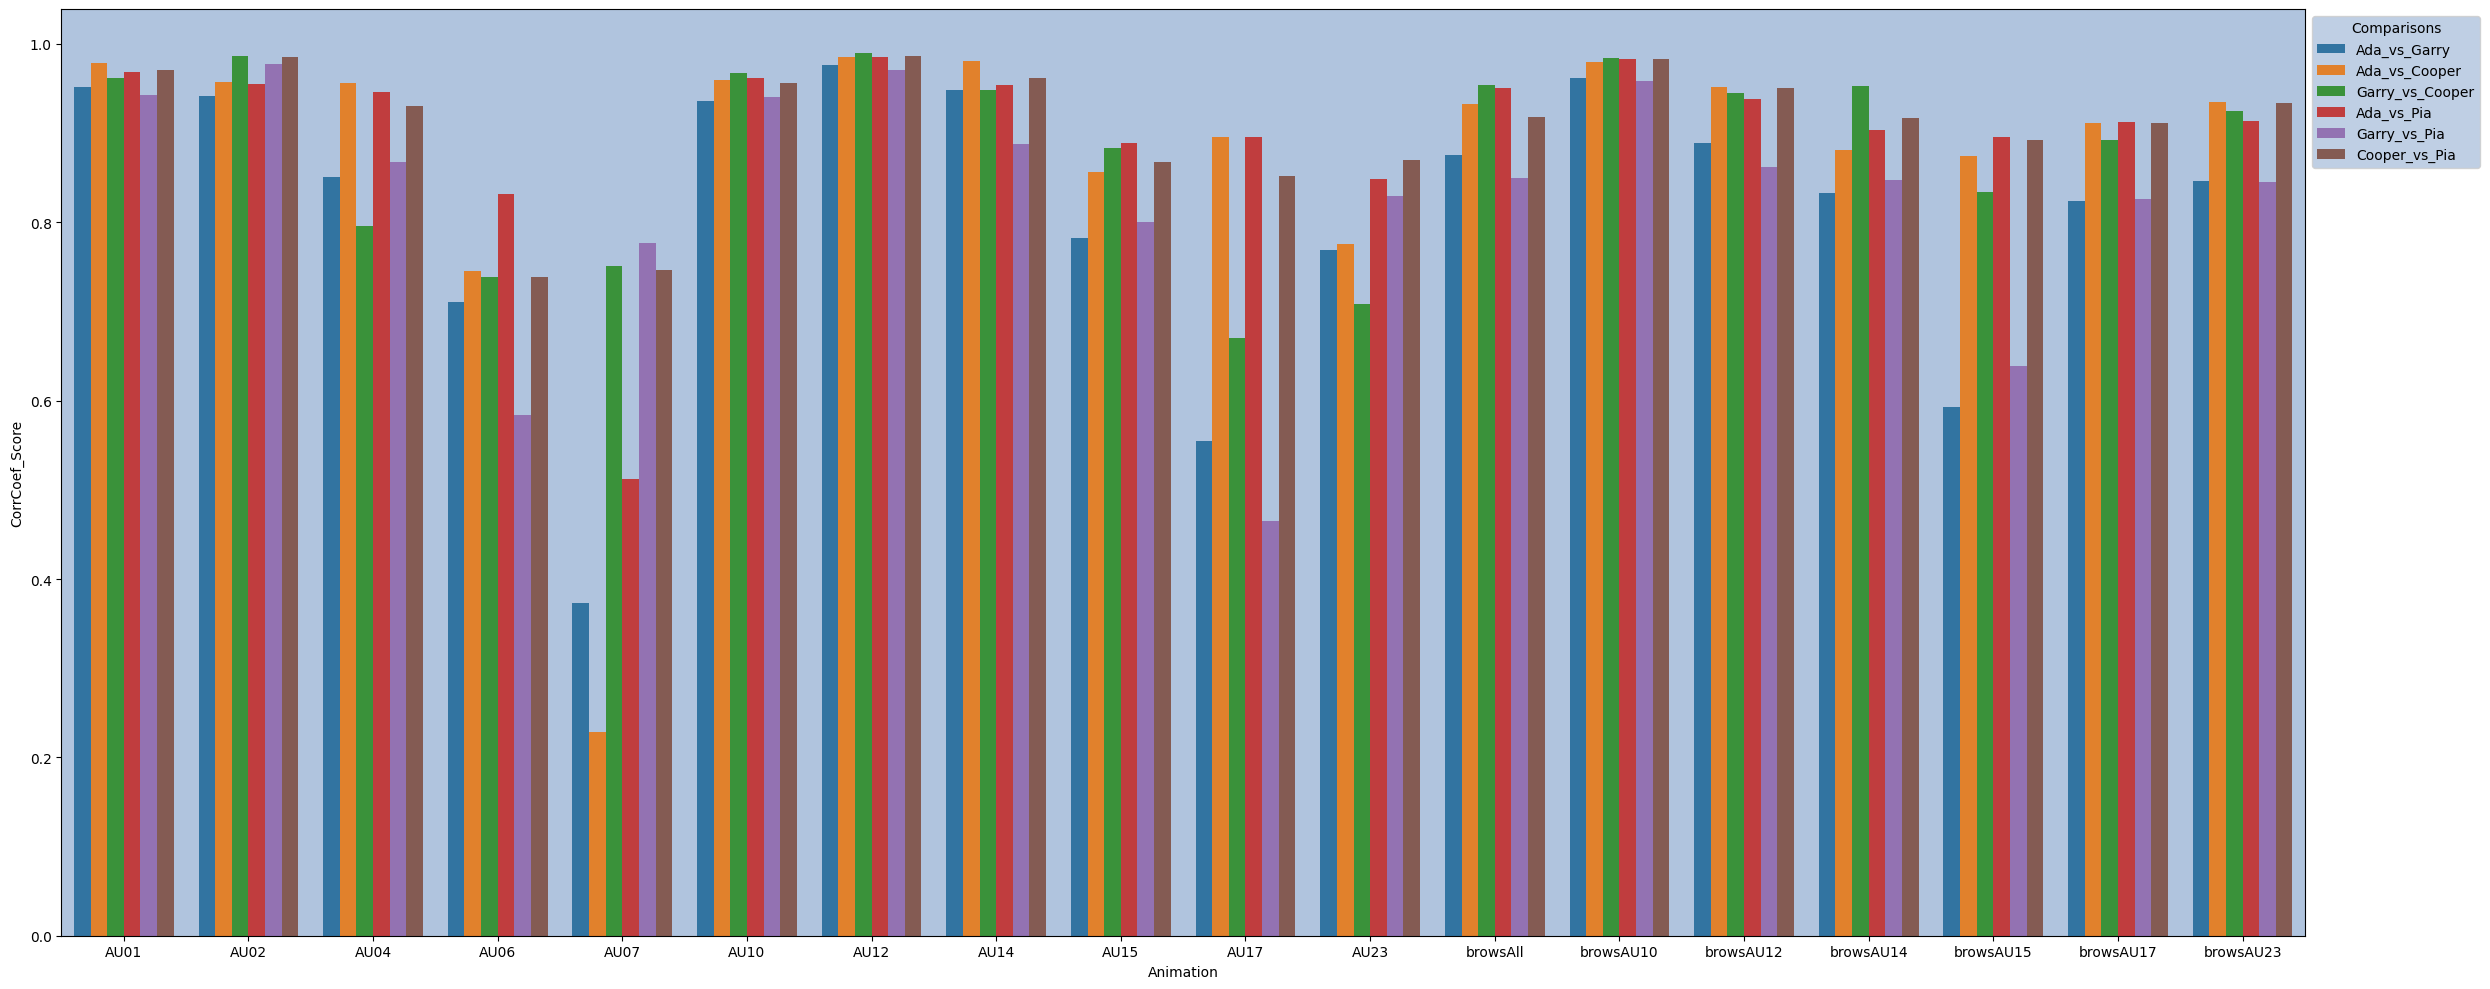

In [ ]:
plt.figure(figsize=(25,10))
gca = sns.barplot(landm_corrcoef_long_df, x="Animation", y='CorrCoef_Score', hue='Comparisons', legend=True)
sns.move_legend(gca, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Active over Inactive Landmarks' Displacement Ratio as a percentage -mean-scaled:  
mean(target_landm_data(:))/mean(other_landm_data(:))*100;

In [ ]:
landm_actv_over_inactv_df = pd.read_csv('mean_scaled_act_inactv_percentage_landm_ratio.csv', delimiter=',', index_col=None)
landm_actv_over_inactv_df.head()

,Avatar,Animation,Mean_accuracy_perc
0,Ada,AU01,301.080819
1,Garry,AU01,272.993843
2,Cooper,AU01,304.818181
3,Pia,AU01,291.946257
4,Ada,AU02,400.346122


In [ ]:
landm_actv_over_inactv_df.describe()

,Mean_accuracy_perc
count,72.000000
mean,193.763875
std,69.915770
min,61.928466
25%,148.250485
50%,172.540912
75%,232.166507
max,400.346122


### Any significant difference bw avatars?

In [ ]:
landm_actv_over_inactv_df.groupby('Avatar').describe().applymap('{:,.2f}'.format)

<ipython-input-24-04c99bbe2c0b>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  landm_actv_over_inactv_df.groupby('Avatar').describe().applymap('{:,.2f}'.format)


Mean_accuracy_perc                                                 \
                    count    mean    std     min     25%     50%     75%   
Avatar                                                                     
Ada                 18.00  200.59  79.37   61.93  153.86  192.36  248.12   
Cooper              18.00  193.27  70.67   97.09  151.61  166.90  238.05   
Garry               18.00  188.15  66.37   99.92  145.05  163.83  232.45   
Pia                 18.00  193.05  68.06  117.17  145.88  176.33  211.57   

                
           max  
Avatar          
Ada     400.35  
Cooper  373.91  
Garry   328.13  
Pia     385.39

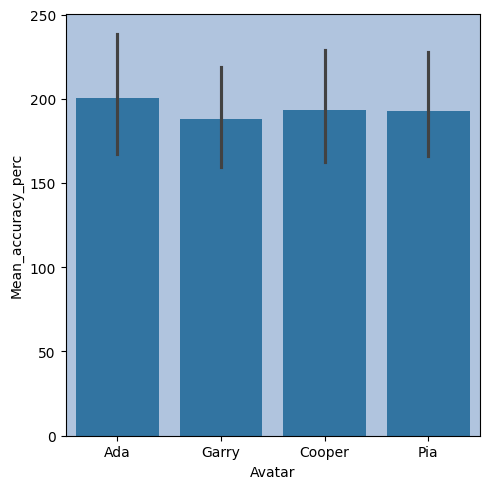

In [ ]:
plt.figure(figsize=(5,5))
gca = sns.barplot(landm_actv_over_inactv_df, x="Avatar", y='Mean_accuracy_perc')
plt.tight_layout()
plt.show()

In [ ]:
f_model = friedmanchisquare(*[group['Mean_accuracy_perc'].values for name, group in landm_actv_over_inactv_df.groupby('Avatar')])
print(f"Friedman's test for comparison results:")
print("Statistic:", round(f_model.statistic,3))
print("p-value:", round(f_model.pvalue,3))

Friedman's test for comparison results:
Statistic: 5.133
p-value: 0.162


### Any significant difference bw animations?

In [ ]:
landm_actv_over_inactv_df.groupby('Animation').describe().applymap('{:,.2f}'.format)

<ipython-input-26-bd0ad2d7967c>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  landm_actv_over_inactv_df.groupby('Animation').describe().applymap('{:,.2f}'.format)


Mean_accuracy_perc                                                 \
                       count    mean    std     min     25%     50%     75%   
Animation                                                                     
AU01                    4.00  292.71  14.21  272.99  287.21  296.51  302.02   
AU02                    4.00  371.95  31.15  328.13  362.47  379.65  389.13   
AU04                    4.00  272.15  11.54  258.02  266.11  272.74  278.78   
AU06                    4.00  147.63  17.05  127.24  137.63  148.54  158.54   
AU07                    4.00  130.21  46.99   61.93  120.12  145.46  155.55   
AU10                    4.00  237.39  22.85  219.12  219.12  232.02  250.28   
AU12                    4.00  250.63  29.83  221.97  228.44  247.06  269.25   
AU14                    4.00  222.21  33.78  177.65  207.51  227.18  241.88   
AU15                    4.00  166.15  38.24  121.93  146.30  164.72  184.57   
AU17                    4.00  162.58  11.83  150.67  156.84  160.42  166.17   
AU23                    4.00  168.59  23.44  142.51  153.82  167.91  182.69   
browsAU10               4.00  186.65   2.66  183.16  185.29  187.24  188.60   
browsAU12               4.00  176.06  18.51  163.07  166.48  168.85  178.42   
browsAU14               4.00  169.91  22.67  143.45  154.80  173.63  188.74   
browsAU15               4.00  141.94   7.40  133.04  139.42  141.77  144.29   
browsAU17               4.00  160.99   8.29  149.85  157.10  163.26  167.15   
browsAU23               4.00  126.49   8.21  118.47  120.11  126.04  132.41   
browsAll                4.00  103.52   9.19   97.09   99.20   99.91  104.23   

                   
              max  
Animation          
AU01       304.82  
AU02       400.35  
AU04       285.11  
AU06       166.17  
AU07       167.99  
AU10       266.40  
AU12       286.42  
AU14       256.84  
AU15       213.23  
AU17       178.83  
AU23       196.04  
browsAU10  188.96  
browsAU12  203.48  
browsAU14  188.92  
browsAU15  151.16  
browsAU17  167.59  
browsAU23  135.40  
browsAll   117.17

In [ ]:
f_model = friedmanchisquare(*[group['Mean_accuracy_perc'].values for name, group in landm_actv_over_inactv_df.groupby('Animation')])
print(f"Friedman's test for comparison results:")
print("Statistic:", round(f_model.statistic,3))
print("p-value:", round(f_model.pvalue,3))

Friedman's test for comparison results:
Statistic: 58.474
p-value: 0.0


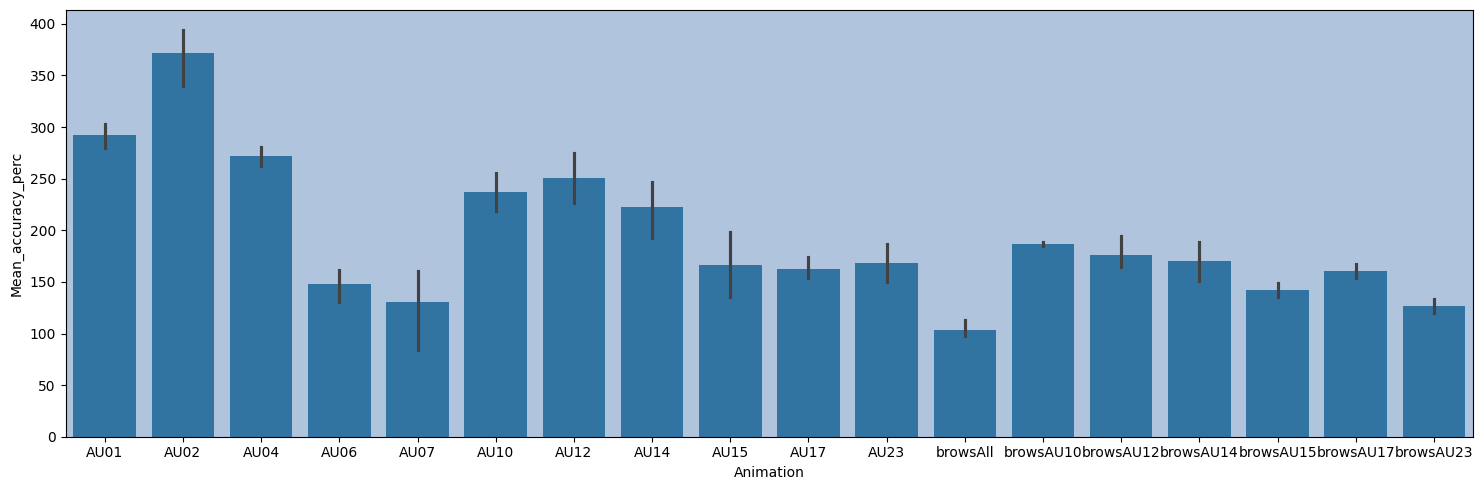

In [ ]:
plt.figure(figsize=(15,5))
gca = sns.barplot(landm_actv_over_inactv_df, x="Animation", y='Mean_accuracy_perc')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'PostHoc Comparison Results for Animation')

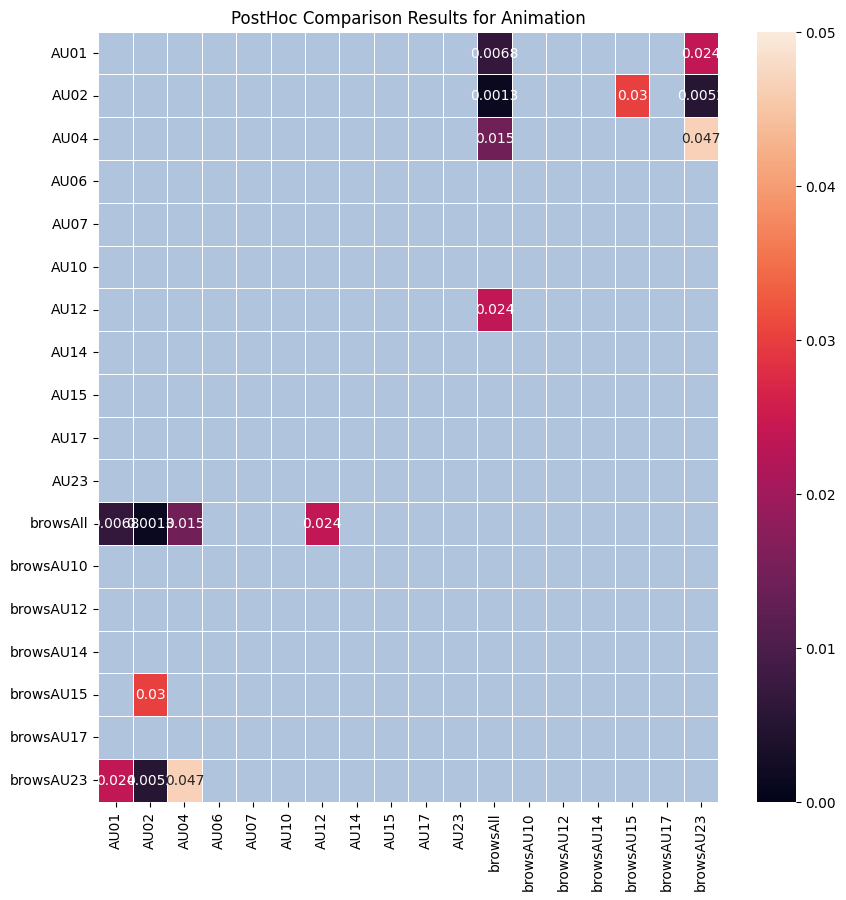

In [ ]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(10,10))
results_df = sp.posthoc_nemenyi_friedman(landm_actv_over_inactv_df, y_col='Mean_accuracy_perc', block_col='Avatar', group_col='Animation', melted= True)
sns.heatmap(results_df[results_df < 0.05], annot=True, vmin=0, vmax=0.05, linewidth=.5)
plt.title(f"PostHoc Comparison Results for Animation")

### Interaction plots:

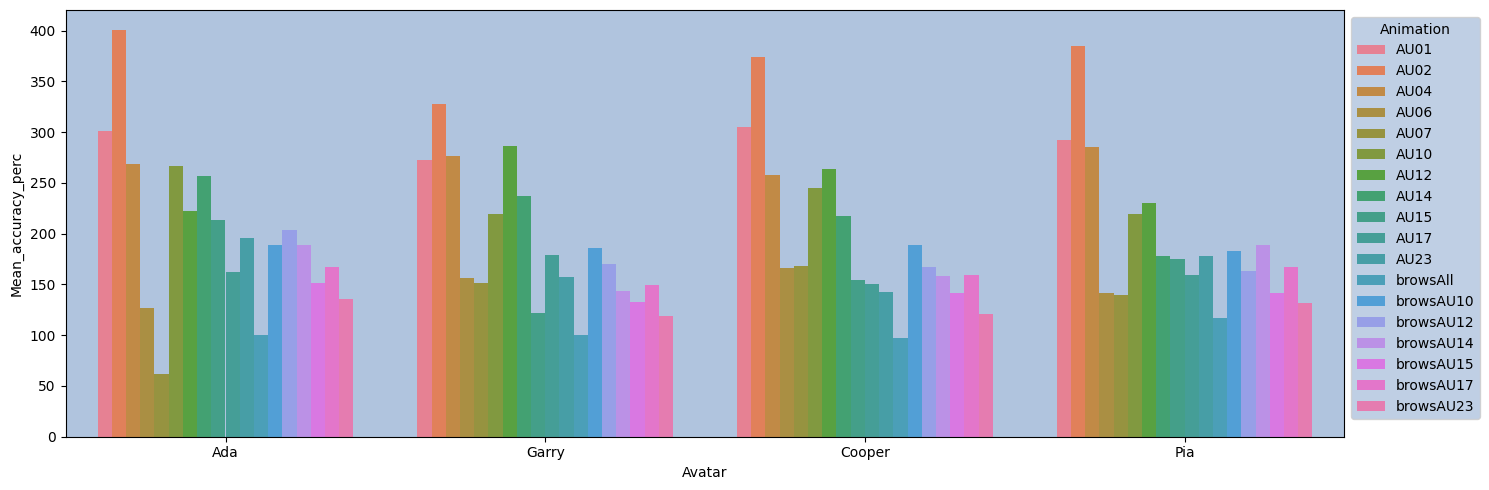

In [ ]:
plt.figure(figsize=(15,5))
gca = sns.barplot(landm_actv_over_inactv_df, x="Avatar", y='Mean_accuracy_perc', hue='Animation', legend=True)
sns.move_legend(gca, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

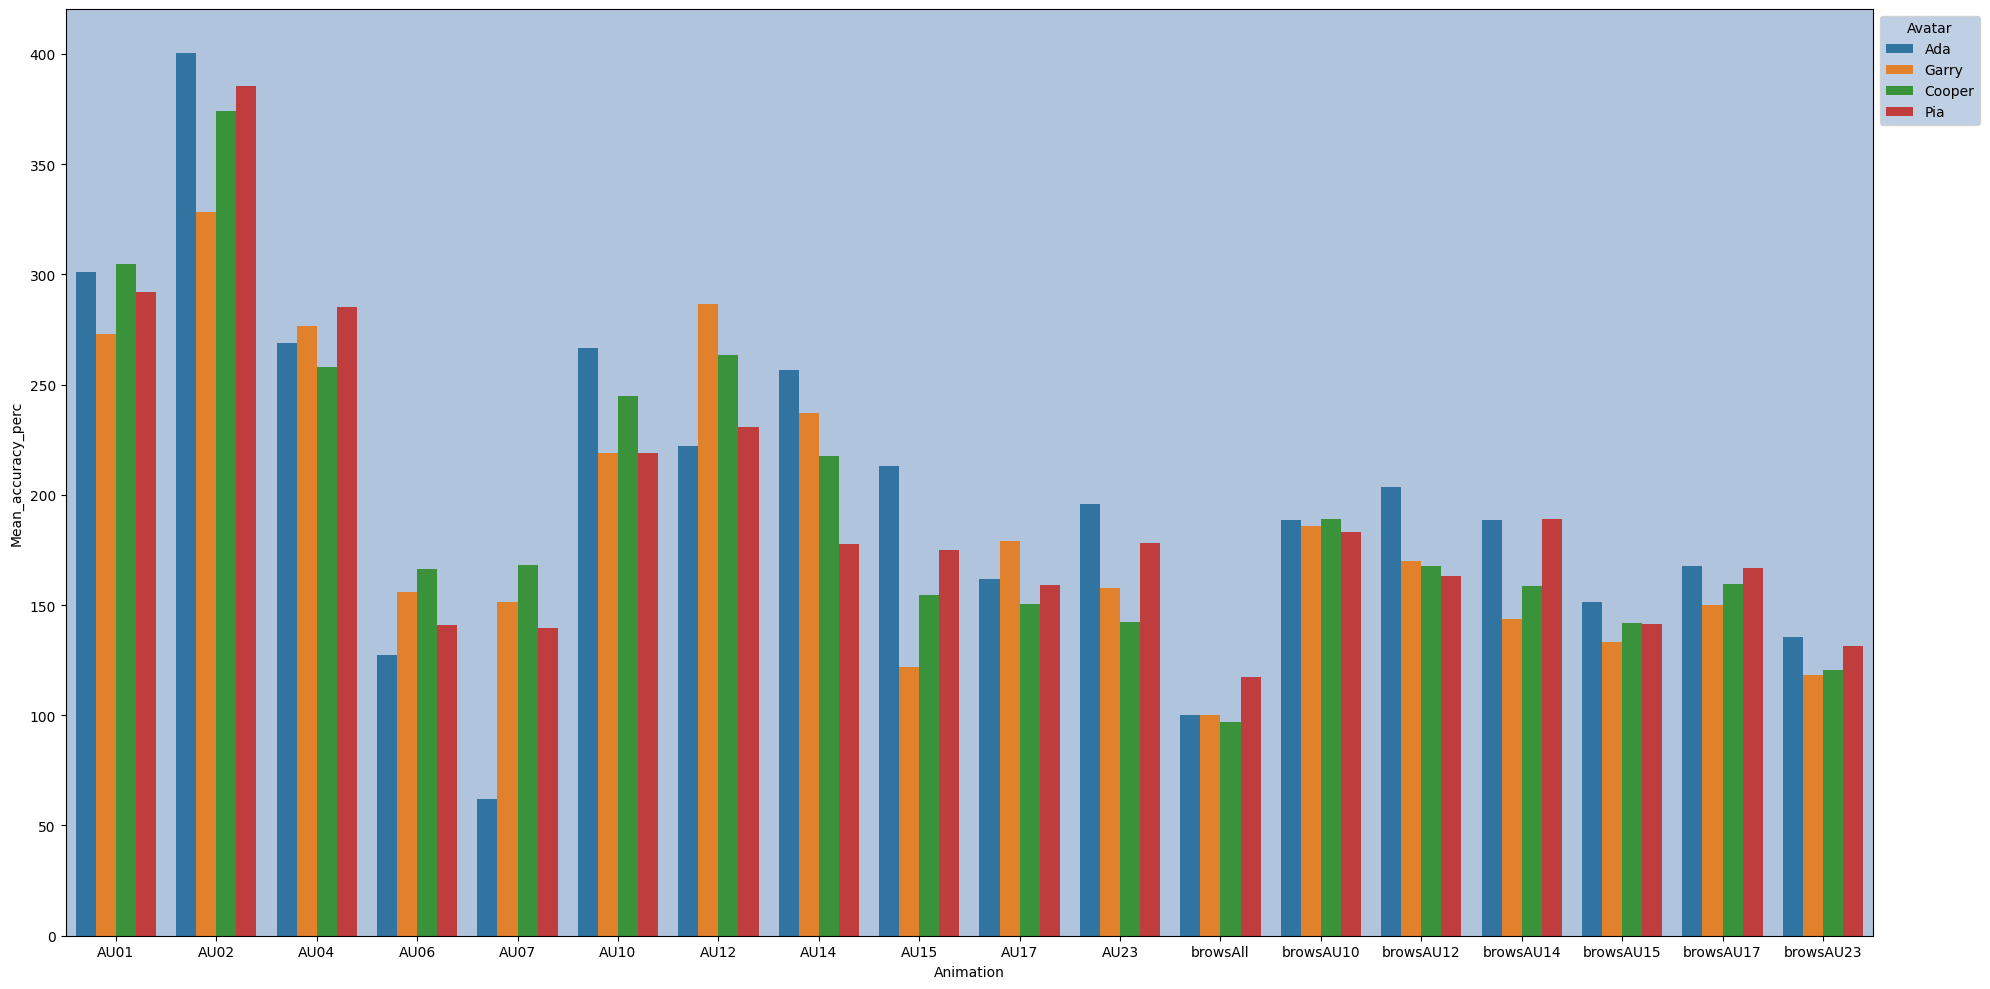

In [ ]:
plt.figure(figsize=(20,10))
gca = sns.barplot(landm_actv_over_inactv_df, x="Animation", y='Mean_accuracy_perc', hue='Avatar', legend=True)
sns.move_legend(gca, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()